# Post-processing for Lysis Front study
 - New scenarios to better match bench experiments

In [1]:
import black
import jupyter_black

jupyter_black.load(
    # Lab=True,
    line_length=110,
    target_version=black.TargetVersion.PY311,
)

## Imports

In [2]:
import datetime
import functools
import math
import os
import pickle
import re
import sys

sys.path.insert(1, os.path.abspath(".."))

from enum import IntEnum, unique

# import scipy
from tqdm.notebook import trange, tqdm, tnrange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

from matplotlib.animation import FFMpegWriter, FuncAnimation
from matplotlib.colors import BoundaryNorm, ListedColormap

import lysis

pd.reset_option("display.precision")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Constants

In [3]:
@unique
class MolStatus(IntEnum):
    UNBOUND = 0
    BOUND = 1
    MACRO_UNBOUND = 2
    MICRO_UNBOUND = 3

In [4]:
scenario_type = np.dtype(
    [
        ("descriptor", np.str_, 40),
        ("total_molecules", int),
        ("pore_size", float),  # in microns. Code requires cm
        ("fiber_diameter", float),  # in microns. Needs to be added to pore_size to get grid_node_distance
        ("binding_sites", int),
        ("cols", int),
        ("rows", int),
        ("empty_rows", int),
        ("forced_unbind", float),
    ]
)
mechanism_type = np.dtype([("descriptor", np.str_, 40), ("executable", np.str_, 40)])
run_type = np.dtype(
    [
        ("exp_code", np.str_, 15),
        ("scenario", np.str_, 40),
        ("mechanism", np.str_, 40),
        ("seed", np.int64),
        ("running_time", int),
        ("save_interval", int),
        ("data_divisor", int),
    ]
)

## Experiment Parameters

In [5]:
scenarios = np.array(
    [
        ("TB-xiii__1_582_867", 1_582_867, 5.34, 123, 298.237, 19, 184, 112, 0.074101),
        ("TB-xiii__949_720", 949_720, 5.34, 123, 298.237, 19, 184, 112, 0.074101),
        ("TB-xiii__316_573", 316_573, 5.34, 123, 298.237, 19, 184, 112, 0.074101),
        ("TB-xiii__21_105", 21_105, 5.34, 123, 298.237, 19, 184, 112, 0.074101),
        ("TB-xi__1_582_867", 1_582_867, 5.34, 123, 248.531, 19, 184, 83, 0.077725),
        ("TB-xi__949_720", 949_720, 5.34, 123, 248.531, 19, 184, 83, 0.077725),
        ("TB-xi__316_573", 316_573, 5.34, 123, 248.531, 19, 184, 83, 0.077725),
        ("TB-xi__21_105", 21_105, 5.34, 123, 248.531, 19, 184, 83, 0.077725),
        ("TB-ix__1_582_867", 1_582_867, 5.34, 123, 198.825, 19, 184, 34, 0.081181),
        ("TB-ix__949_720", 949_720, 5.34, 123, 198.825, 19, 184, 34, 0.081181),
        ("TB-ix__316_573", 316_573, 5.34, 123, 198.825, 19, 184, 34, 0.081181),
        ("TB-ix__21_105", 21_105, 5.34, 123, 248.531, 19, 184, 34, 0.081181),
        ("TF-x__746_330", 746_330, 2.5, 105.1, 306.357, 39, 385, 326, 0.078644),
        ("TF-x__447_798", 447_798, 2.5, 105.1, 306.357, 39, 385, 326, 0.078644),
        ("TF-x__149_266", 149_266, 2.5, 105.1, 306.357, 39, 385, 326, 0.078644),
        ("TF-x__9_951", 9_951, 2.5, 105.1, 306.357, 39, 385, 326, 0.078644),
        ("TF-vii__746_330", 746_330, 2.5, 105.1, 204.238, 39, 385, 265, 0.086698),
        ("TF-vii__447_798", 447_798, 2.5, 105.1, 204.238, 39, 385, 265, 0.086698),
        ("TF-vii__149_266", 149_266, 2.5, 105.1, 204.238, 39, 385, 265, 0.086698),
        ("TF-vii__9_951", 9_951, 2.5, 105.1, 204.238, 39, 385, 265, 0.086698),
        ("TF-v__746_330", 746_330, 2.5, 105.1, 136.159, 39, 385, 151, 0.084703),
        ("TF-v__447_798", 447_798, 2.5, 105.1, 136.159, 39, 385, 151, 0.084703),
        ("TF-v__149_266", 149_266, 2.5, 105.1, 136.159, 39, 385, 151, 0.084703),
        ("TF-v__9_951", 9_951, 2.5, 105.1, 136.159, 39, 385, 151, 0.084703),
    ],
    dtype=scenario_type,
)
mechanisms = np.array(
    [
        ("Into and along - External", "macro_diffuse_into_and_along__external"),
    ],
    dtype=mechanism_type,
)

In [6]:
data_root = os.path.join("..", "..", "..", "data")
out_file_code = "_{scenario_code}"

# slope_tolerance = 1e-3
rng = np.random.default_rng(65463453)

In [7]:
# seed sequence entropy: 234567848524899077628396107049383963466
group_code = "2024-04-16-19"
runs = np.array(
    [
        (group_code + "00", "TB-xi__1_582_867", "Into and along - External", 4_133_290_200, 0, 10, 1),
        (group_code + "01", "TB-xi__949_720", "Into and along - External", 423_058_538, 0, 10, 1),
        (group_code + "02", "TB-xi__316_573", "Into and along - External", 684_840_937, 0, 10, 1),
        (group_code + "03", "TF-x__746_330", "Into and along - External", 868_609_522, 0, 10, 1),
        (group_code + "04", "TF-x__447_798", "Into and along - External", 3_835_132_626, 0, 10, 1),
        (group_code + "05", "TF-x__149_266", "Into and along - External", 153_757_143, 0, 10, 1),
        (group_code + "06", "TF-vii__746_330", "Into and along - External", 456_534_494, 0, 10, 1),
        (group_code + "07", "TF-vii__447_798", "Into and along - External", 3_326_749_085, 0, 10, 1),
        (group_code + "08", "TF-vii__149_266", "Into and along - External", 3_225_783_680, 0, 10, 1),
        (group_code + "09", "TF-v__746_330", "Into and along - External", 1_705_037_629, 0, 10, 1),
        (group_code + "10", "TF-v__447_798", "Into and along - External", 22_857_604, 0, 10, 1),
        (group_code + "11", "TF-v__149_266", "Into and along - External", 3_425_717_575, 0, 10, 1),
        (group_code + "12", "TB-xi__21_105", "Into and along - External", 2_061_649_767, 0, 10, 1),
        (group_code + "13", "TF-x__9_951", "Into and along - External", 3_687_972_975, 0, 10, 1),
        (group_code + "14", "TF-vii__9_951", "Into and along - External", 1_422_833_478, 0, 10, 1),
        (group_code + "15", "TF-v__9_951", "Into and along - External", 77_748_149, 0, 10, 1),
        (group_code + "16", "TB-ix__1_582_867", "Into and along - External", 2_005_301_891, 0, 10, 1),
        (group_code + "17", "TB-ix__949_720", "Into and along - External", 1_096_147_976, 0, 10, 1),
        (group_code + "18", "TB-ix__316_573", "Into and along - External", 3_135_368_345, 0, 10, 1),
        (group_code + "19", "TB-ix__21_105", "Into and along - External", 1_554_390_417, 0, 10, 1),
        (group_code + "20", "TB-xiii__1_582_867", "Into and along - External", 3_336_730_663, 0, 10, 1),
        (group_code + "21", "TB-xiii__949_720", "Into and along - External", 3_042_132_398, 0, 10, 1),
        (group_code + "22", "TB-xiii__316_573", "Into and along - External", 248_524_792, 0, 10, 1),
        (group_code + "23", "TB-xiii__21_105", "Into and along - External", 3_134_955_532, 0, 10, 1),
    ],
    dtype=run_type,
)

## More Constants and Data Structures

In [8]:
# Get default parameters
e = lysis.Experiment(data_root, experiment_code="0000-00-00-0000")
e.initialize_macro_param()
df = pd.DataFrame([e.macro_params])

# Create empty DataFrame using the scenario names as rows and parameter names as columns
index = pd.Index(runs["scenario"], name="Scenario")
parameters_df = pd.DataFrame(index=index, columns=df.columns)
statistics = pd.MultiIndex.from_product(
    [
        [
            "Front Velocity (microns/min)",
            "Degradation rate (%/min)",
            "Lysis lag time (min)",
            "Time to full clot degradation (min)",
            "Percent of molecules that reached the back row",
            "First passage time (min)",
            "Total (Un)Binds",
            "Forced Unbinds (Microscale)",
            "Forced Unbinds (Macroscale)",
        ],
        ["Mean", "Standard Deviation"],
    ]
)
results = pd.DataFrame(index=index, columns=statistics)

In [9]:
formats = {
    "binding_rate": "{:.2f}",
    "pore_size": "{:1.5e}",
    "diffusion_coeff": "{:1.5e}",
    # 'binding_sites': "",
    "forced_unbind": "{:.3f}",
    "average_bind_time": "{:.2f}",
    "grid_node_distance": "{:.3f}",
    # 'cols', 'rows', 'fiber_rows', 'empty_rows', 'last_empty_edge',
    "full_row": "{:,}",
    "xz_row": "{:,}",
    "total_edges": "{:,}",
    "total_fibers": "{:,}",
    "total_molecules": "{:,}",
    "moving_probability": "{:.2f}",
    "microscale_runs": "{:,}",
    # 'total_trials',
    "total_time": "{:,.0f}",
    "time_step": "{:1.3e}",
    "total_time_steps": "{:,}",
    "seed": "{:,}",
    # 'save_interval',
    # 'number_of_saves',
}
cols_to_drop = [
    "state",
    "input_data",
    "output_data",
    "log_lvl",
    "duplicate_fortran",
    "processing_library",
    "macro_version",
]
# ,

In [10]:
scenario_grid = [
    [
        "TB-xiii__1_582_867",
        "TB-xiii__949_720",
        "TB-xiii__316_573",
        "TB-xiii__21_105",
    ],
    [
        "TB-xi__1_582_867",
        "TB-xi__949_720",
        "TB-xi__316_573",
        "TB-xi__21_105",
    ],
    [
        "TB-ix__1_582_867",
        "TB-ix__949_720",
        "TB-ix__316_573",
        "TB-ix__21_105",
    ],
    [
        "TF-x__746_330",
        "TF-x__447_798",
        "TF-x__149_266",
        "TF-x__9_951",
    ],
    [
        "TF-vii__746_330",
        "TF-vii__447_798",
        "TF-vii__149_266",
        "TF-vii__9_951",
    ],
    [
        "TF-v__746_330",
        "TF-v__447_798",
        "TF-v__149_266",
        "TF-v__9_951",
    ],
]
scenario_grid_T = [[row[i] for row in scenario_grid] for i in range(len(scenario_grid[0]))]
groupings = [
    "5nM tPA",
    "3nM tPA",
    "1nM tPA",
    "0.067nM tPA",
]
colors = {
    "TB-xiii__1_582_867": "#780000",  # "xkcd:black",
    "TB-xiii__949_720": "#a30005",  # "xkcd:black",
    "TB-xiii__316_573": "#d00004",  # "xkcd:black",
    "TB-xiii__21_105": "#ff0000",  # "xkcd:black",
    "TB-xi__1_582_867": "#785f02",  # "xkcd:purple",
    "TB-xi__949_720": "#9a7901",  # "xkcd:magenta",
    "TB-xi__316_573": "#bf9401",  # "xkcd:red",
    "TB-xi__21_105": "#e5af00",  # "xkcd:pink",
    "TB-ix__1_582_867": "#567800",  # "xkcd:grey",
    "TB-ix__949_720": "#689f00",  # "xkcd:grey",
    "TB-ix__316_573": "#77c800",  # "xkcd:grey",
    "TB-ix__21_105": "#81f300",  # "xkcd:grey",
    "TF-x__746_330": "#06785f",  # "xkcd:blue",
    "TF-x__447_798": "#00a37a",  # "xkcd:bright blue",
    "TF-x__149_266": "#00d092",  # "xkcd:baby blue",
    "TF-x__9_951": "#00ffa7",  # "xkcd:cyan",
    "TF-vii__746_330": "#076378",  # "xkcd:teal",
    "TF-vii__447_798": "#0094a9",  # "xkcd:green",
    "TF-vii__149_266": "#00c8d6",  # "xkcd:sea green",
    "TF-vii__9_951": "#00ffff",  # "xkcd:lime",
    "TF-v__746_330": "#400478",  # "xkcd:light brown",
    "TF-v__447_798": "#7f33a4",  # "xkcd:orange",
    "TF-v__149_266": "#be5fd1",  # "xkcd:apricot",
    "TF-v__9_951": "#ff8eff",  # "xkcd:yellowish",
}


def pretty_print_scen(scen):
    out_str = scen.split("__")
    for i in range(len(scenario_grid_T)):
        if scen in scenario_grid_T[i]:
            conc = groupings[i]
    return f"{out_str[0]} {conc}"  # {int(out_str[1]):,d}"

In [11]:
index = pd.Index(runs["scenario"], name="Scenario")
degrade_percent_markers = [0.05, 0.2, 0.5, 0.8, 1]
columns = pd.MultiIndex.from_product(
    [[f"{int(i*100)}%" for i in degrade_percent_markers], range(10)], names=["Percent Degraded", "Simulation"]
)
degradation_time_df = pd.DataFrame(index=index, columns=columns)

# The definition of the lysis front
# The front is the first row with at least `front_def` proportion of fibers intact.
front_def = 0.05

degrade_slope_between_percent = [[0.2, 0.8], [0.2, 0.5], [0.5, 0.8]]
# degrade_slope_between_percent = [
#     [degrade_percent_markers.index(mark) for mark in slope] for slope in degrade_slope_between_percent
# ]
columns = pd.MultiIndex.from_product(
    [[f"{int(i[0]*100)}% to {int(i[1]*100)}%" for i in degrade_slope_between_percent], range(10)],
    names=["Degradation Interval", "Simulation"],
)
slopes_df = pd.DataFrame(index=index, columns=columns)
binds_df = pd.DataFrame(index=index, columns=pd.Index(range(10), name="Simulation"))

mol_time_statistics = [
    "Total Binds",
]
mol_time_df = pd.DataFrame(index=index, columns=mol_time_statistics)

pore_stat_df = pd.DataFrame(index=index, columns=[f"{int(i*100)}%" for i in degrade_percent_markers])

In [12]:
# For a light colormap of degraded fibers
colormap_f = plt.cm.cividis(np.arange(plt.cm.cividis.N))
colormap_f[:, 3] = 0.3
# For very light grey degraded fibers
colormap_f = ["xkcd:light grey"]

colormap_f = ListedColormap(colormap_f)
colormap_f.set_extremes(bad="xkcd:blue", under="white", over="xkcd:blue")
colormap_m = ListedColormap(["xkcd:green", "xkcd:cyan"])
bounds = [0, 0.5, 1]
norm_m = BoundaryNorm(bounds, colormap_m.N)

angle = (1 / 2 - 1 / 8) * math.pi
radius = 0.5

## Functions

### Utility Functions

In [13]:
def load_fortran_files(exp, file_code, divisor=1):
    n_save = np.asarray(
        [
            np.fromfile(
                os.path.join(exp.os_path, f"{sim:02}", f"Nsave{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
                dtype=np.int32,
            )[0]
            for sim in range(exp.macro_params.total_trials)
        ]
    )
    n_save += 1
    # Check if the last save interval will be included when every `divisor` save interval is selected
    # This will happen when all save intervals are selected (`divisor=1`)
    # or when the remainder of `n_save / divisor` is 1
    add_last = n_save % divisor != 1 if divisor > 1 else np.full(exp.macro_params.total_trials, False)
    indices_to_save = [
        np.r_[: n_save[sim] : divisor, -1] if add_last[sim] else np.r_[: n_save[sim] : divisor]
        for sim in range(exp.macro_params.total_trials)
    ]

    tsave = [
        np.fromfile(os.path.join(exp.os_path, f"{sim:02}", f"tsave{file_code[:-4]}_{sim:02}{file_code[-4:]}"))
        for sim in range(exp.macro_params.total_trials)
    ]
    tsave = [a[indices_to_save[sim]] for sim, a in enumerate(tsave)]
    tmax = max([np.max(arr) for arr in tsave])

    mfpt = np.asarray(
        [
            np.fromfile(
                os.path.join(exp.os_path, f"{sim:02}", f"mfpt{file_code[:-4]}_{sim:02}{file_code[-4:]}")
            )
            for sim in range(exp.macro_params.total_trials)
        ]
    )

    mol_location = []
    mol_status = []
    for sim in range(exp.macro_params.total_trials):
        raw_mol_location = np.fromfile(
            os.path.join(exp.os_path, f"{sim:02}", f"m_loc{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
            dtype=np.int32,
        )
        raw_mol_location -= 1
        raw_mol_location = raw_mol_location.reshape(n_save[sim], exp.macro_params.total_molecules)
        mol_location.append(raw_mol_location[indices_to_save[sim]])

        raw_mol_status = np.fromfile(
            os.path.join(exp.os_path, f"{sim:02}", f"m_bound{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
            dtype=np.int32,
        )
        raw_mol_status = raw_mol_status.astype(np.bool_)
        raw_mol_status = raw_mol_status.reshape(n_save[sim], exp.macro_params.total_molecules)
        mol_status.append(raw_mol_status[indices_to_save[sim]])

    mapped_deg = []
    # filename = os.path.join(exp.os_path, f"f_deg_time{file_code[:-4]}.npz")
    # if os.path.isfile(filename):
    #     deg_arrays = np.load(filename)
    #     mapped_deg = [deg for deg in deg_arrays.values()]
    # else:
    for sim in range(exp.macro_params.total_trials):
        # If an old format (wide) deg array exists
        if os.path.isfile(
            os.path.join(exp.os_path, f"{sim:02}", f"f_deg_time{file_code[:-4]}_{sim:02}{file_code[-4:]}")
        ):
            # Read it in
            raw_deg = np.fromfile(
                os.path.join(exp.os_path, f"{sim:02}", f"f_deg_time{file_code[:-4]}_{sim:02}{file_code[-4:]}")
            )
            # Reshape it appropriately
            raw_deg = raw_deg.reshape(n_save[sim], exp.macro_params.total_edges)
            # and append it to the list
            mapped_deg.append(raw_deg[indices_to_save[sim]])
        else:
            # Assume a new format (long) deg array exists
            # Read in the file to a Pandas DataFrame
            raw_fiber_events = pd.read_csv(
                os.path.join(
                    exp.os_path, f"{sim:02}", f"f_deg_list{file_code[:-4]}_{sim:02}{file_code[-4:]}"
                ),
                names=["Simulation Time", "Fiber Index", "Degrade Time"],
            )

            # Bin the events by save interval
            raw_fiber_events["Save Interval"] = pd.cut(
                raw_fiber_events["Simulation Time"], tsave[sim], labels=range(1, len(tsave[sim]))
            )
            # Drop any duplicates (more than one binding in a single save interval)
            raw_fiber_events = raw_fiber_events.drop_duplicates(subset="Fiber Index", keep="last")
            # Pivot the "long" table into a "wide" table
            deg_df = raw_fiber_events.pivot(
                index="Fiber Index", columns="Save Interval", values="Degrade Time"
            )
            # Add an initial value for each fiber (essentially infinite)
            deg_df[0] = 9.9e100
            # Add any save intervals that had no changes to degradation
            blank_cols = []
            for t in range(len(tsave[sim])):
                if t not in deg_df.columns:
                    blank_cols.append(t)
            if len(blank_cols) > 0:
                blank = pd.DataFrame(index=deg_df.index, columns=blank_cols)
                for t in blank_cols:
                    blank[t] = np.nan
                deg_df = pd.concat([deg_df, blank], axis=1)
            # Sort by save interval
            deg_df = deg_df.sort_index(axis=1)
            # Copy the degrade time through any save intervals where the degrade time didn't change
            deg_df = deg_df.ffill(axis=1)
            # Create rows of zeros for the non-fiber edges
            empty_rows = pd.DataFrame(
                0.0,
                index=range(1, exp.macro_params.empty_rows * exp.macro_params.full_row + 1),
                columns=range(len(tsave[sim])),
            )
            # Append the empty rows to the DataFrame
            deg_df = pd.concat([empty_rows, deg_df])
            # Convert the DataFrame to a NumPy array and transpose
            deg = deg_df.to_numpy().T
            # Append to the list
            mapped_deg.append(deg)
        # deg_arrays = {f"f_deg_time_{sim:02}": deg for (sim, deg) in enumerate(mapped_deg)}
        # np.savez_compressed(os.path.join(exp.os_path, f"f_deg_time{file_code[:-4]}"), **deg_arrays)

    n_save = [len(t) for t in tsave]
    return n_save, mapped_deg, tsave, mfpt, mol_location, mol_status


def ensure_results_match(exp, file_code, old_code):
    e_old = lysis.util.Experiment(
        os.path.join("..", "..", "..", "data"), experiment_code=old_code + exp.experiment_code[-2:]
    )
    e_old.read_file()
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(e, file_code)
    n_save_old, deg_old, tsave_old, mfpt_old, mol_location_old, mol_status_old = load_fortran_files(
        e_old, file_code
    )
    if np.count_nonzero(n_save != n_save_old) > 0:
        return False
    for i in range(exp.macro_params.total_trials):
        if np.count_nonzero(deg[i] != deg_old[i]) > 0:
            return False
        if np.count_nonzero(tsave[i] != tsave_old[i]) > 0:
            return False
        if np.count_nonzero(mfpt[i] != mfpt_old[i]) > 0:
            return False
        if np.count_nonzero(mol_location[i] != mol_location_old[i]) > 0:
            return False
        if np.count_nonzero(mol_status[i] != mol_status_old[i]) > 0:
            return False
    return True

### Standard Parameter Functions & Plots

In [14]:
def find_degraded_fraction(exp, deg, tsave):
    degraded_fraction = []
    for sim in range(exp.macro_params.total_trials):
        run_degraded_fraction = np.empty(deg[sim].shape[0], dtype=np.float64)
        for t in range(deg[sim].shape[0]):
            run_degraded_fraction[t] = np.count_nonzero(deg[sim][t] <= tsave[sim][t])
        run_degraded_fraction -= exp.macro_params.empty_rows * exp.macro_params.full_row
        degraded_fraction.append(run_degraded_fraction / exp.macro_params.total_fibers)
    return degraded_fraction


def find_degradation_marker_frames(exp, degraded_fraction, degrade_percent_markers):
    degrade_marker_frames = np.empty((len(degraded_fraction), len(degrade_percent_markers)), dtype=np.int_)
    for sim in range(len(degraded_fraction)):
        for marker in range(len(degrade_percent_markers)):
            degrade_marker_frames[sim, marker] = np.argmax(
                degraded_fraction[sim] >= degrade_percent_markers[marker]
            )
    return degrade_marker_frames


# Changed back to min
def find_degradation_marker_times(exp, degrade_marker_frames, tsave):
    degradation_marker_times = np.empty(
        (len(degrade_marker_frames), len(degrade_marker_frames[0])), dtype=np.float64
    )
    for sim in range(len(degrade_marker_frames)):
        degradation_marker_times[sim] = tsave[sim][degrade_marker_frames[sim]]
    return degradation_marker_times / 60


def degradation_rates(exp, degrade_marker_frames, degraded_fraction, tsave):
    degradation_rates = np.empty(
        (exp.macro_params.total_trials, len(degrade_slope_between_percent)), dtype=np.float64
    )
    for sim in range(exp.macro_params.total_trials):
        for slope in range(len(degrade_slope_between_percent)):
            start_frame = degrade_marker_frames[
                sim, degrade_percent_markers.index(degrade_slope_between_percent[slope][0])
            ]
            end_frame = degrade_marker_frames[
                sim, degrade_percent_markers.index(degrade_slope_between_percent[slope][1])
            ]
            delta_y = degraded_fraction[sim][end_frame] - degraded_fraction[sim][start_frame]
            delta_x = tsave[sim][end_frame] - tsave[sim][start_frame]
            degradation_rates[sim, slope] = delta_y / delta_x * 60  # * 100
    return degradation_rates


def save_degrade_fraction_table(exp, file_code, degraded_fraction, tsave):
    max_time = 0
    max_time_idx = None
    for i in range(len(tsave)):
        if len(tsave[i]) > max_time:
            max_time = len(tsave[i])
            max_time_idx = i
    index = pd.Index(range(10), name="Simulation")
    columns = pd.Index((tsave[max_time_idx] / 60), name="Simulation Time Elapsed (min)")
    pd.DataFrame(degraded_fraction, index=index, columns=columns).fillna(1).to_csv(
        os.path.join(exp.os_path, "deg_fraction_at_time_in_min" + file_code[:-4] + ".csv")
    )


# Must match units
# Is expecting degradation rates in frac/min
def plot_degradation_percent(exp, degraded_fraction, tsave, degrade_marker_frames, degradation_rates):
    start_stop = [
        [degrade_percent_markers.index(mark) for mark in slope] for slope in degrade_slope_between_percent
    ]
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, (max([np.max(deg_run[-1, :]) for deg_run in deg]) // 60) + 1)
    ax.set_ylim(-0.1, 1.1)
    for sim in range(exp.macro_params.total_trials):
        plt.plot(tsave[sim] / 60, degraded_fraction[sim])
        for slope in range(len(start_stop)):
            start_frame = degrade_marker_frames[sim, start_stop[slope][0]]
            end_frame = degrade_marker_frames[sim, start_stop[slope][1]]
            lin_func = (
                lambda x: degradation_rates[sim, slope] * (x - tsave[sim][start_frame] / 60)
                + degraded_fraction[sim][start_frame]
            )
            plt.plot(
                tsave[sim][start_frame:end_frame] / 60,
                lin_func(tsave[sim][start_frame:end_frame] / 60),
                color="b",
                alpha=0.5,
                zorder=0.1,
            )
    fig.savefig(os.path.join(exp.os_path, "deg_rate" + file_code[:-4] + ".png"), bbox_inches="tight")
    plt.close()


def calculate_time_row_exposed(exp, deg):
    exposed_time = np.empty(
        (exp.macro_params.total_trials, exp.macro_params.rows - 1, exp.macro_params.cols), dtype=np.float64
    )
    for run in range(exp.macro_params.total_trials):
        for j in range(exp.macro_params.cols):
            for i in range(exp.macro_params.rows - 1):
                if i == 0:
                    exposed_time[run, i, j] = 0
                else:
                    k = lysis.to_fortran_edge_index(i, j, exp.macro_params.rows, exp.macro_params.cols)
                    exposed_time[run, i, j] = max(exposed_time[run, i - 1, j], deg[run][-1, k])
    # exposed_time = 10* np.ceil(exposed_time / 10)
    return exposed_time / 60


def find_degradation_fronts(exp, exposed_time, y_distance, tsave):
    deg_fronts = []
    for r in range(exp.macro_params.total_trials):
        run_deg_fronts = []
        for j in range(exp.macro_params.cols):
            col_deg_front = []
            for i in range(1, exp.macro_params.rows - 1):
                if exposed_time[r, i - 1, j] < exposed_time[r, i, j] < tsave[r][-1] + 1:
                    col_deg_front.append([exposed_time[r, i, j], y_distance[i]])
            run_deg_fronts.append(np.array(col_deg_front).T)
        deg_fronts.append(run_deg_fronts)
    return deg_fronts


# TODO(bpaynter): Change this later to do mean and std of all columns across all runs
def mean_front_velocity(exp, deg_fronts):
    run_mean_velocity = np.empty(exp.macro_params.total_trials, dtype=np.float64)
    run_std_velocity = np.empty(exp.macro_params.total_trials, dtype=np.float64)
    for run in range(exp.macro_params.total_trials):
        front_velocity = np.empty(exp.macro_params.cols, dtype=np.float64)
        for j in range(exp.macro_params.cols):
            b, m = np.polynomial.polynomial.polyfit(deg_fronts[run][j][0], deg_fronts[run][j][1], 1)
            front_velocity[j] = m
        run_mean_velocity[run] = np.mean(front_velocity)
        run_std_velocity[run] = np.std(front_velocity)
    return np.mean(run_mean_velocity), np.mean(run_std_velocity)


def plot_front_degradation(exp, file_code, deg_fronts, deg):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_on()
    ax.set_xlim(0, (max([np.max(deg_run[-1, :]) for deg_run in deg]) // 60) + 1)
    ax.set_ylim(
        (exp.macro_params.empty_rows - 1) * exp.macro_params.grid_node_distance,
        (exp.macro_params.rows - 1) * exp.macro_params.grid_node_distance,
    )
    for run in range(exp.macro_params.total_trials):
        for j in range(exp.macro_params.cols):
            plt.plot(deg_fronts[run][j][0], deg_fronts[run][j][1], linewidth=1)
    fig.savefig(os.path.join(exp.os_path, "deg_fronts" + file_code[:-4] + ".png"), bbox_inches="tight")
    plt.close()


def mean_degradation_rate(exp, degraded_fraction, tsave):
    degradation_rate = np.empty(exp.macro_params.total_trials, dtype=np.float64)
    offset = np.empty(exp.macro_params.total_trials, dtype=np.float64)
    deg_start_time = np.empty(exp.macro_params.total_trials, dtype=np.float64)
    for r in range(exp.macro_params.total_trials):
        slope = np.empty(degraded_fraction[r].shape[0], dtype=np.float64)
        slope[0] = degraded_fraction[r][0]
        for t in range(1, degraded_fraction[r].shape[0]):
            slope[t] = degraded_fraction[r][t] - degraded_fraction[r][t - 1]
        degradation_happening = slope > slope.max() / 2
        s = np.argmax(degradation_happening)
        b, m = np.polynomial.polynomial.polyfit(
            tsave[r][degradation_happening] / 60, degraded_fraction[r][degradation_happening], 1
        )
        degradation_rate[r] = m
        offset[r] = b
        deg_start_time[r] = tsave[r][s] / 60
    return degradation_rate, offset, deg_start_time


def find_row_deg_fraction(exp, deg, tsave):
    row_deg = []
    for s in range(exp.macro_params.total_trials):
        row_deg.append(
            np.count_nonzero(
                (deg[s] > tsave[s].reshape(tsave[s].size, 1))[
                    :, exp.macro_params.empty_rows * exp.macro_params.full_row : -exp.macro_params.xz_row
                ].reshape((deg[s].shape[0], exp.macro_params.fiber_rows - 1, exp.macro_params.full_row)),
                axis=2,
            )
            / exp.macro_params.full_row
        )
    return row_deg


def find_front(exp, row_deg):
    fronts = []
    for sim_row_deg in row_deg:
        sim_fronts = np.argmax(sim_row_deg >= front_def, axis=1)
        sim_fronts[np.max(sim_row_deg >= front_def, axis=1) == 0] = exp.macro_params.fiber_rows - 1
        fronts.append(sim_fronts)
    return fronts


def fiber_degradation_linear_extrapolation(exp, tsave, deg):
    f_deg_amt = []
    for sim in range(exp.macro_params.total_trials):
        f_deg_amt_sim = np.concatenate(
            [
                np.full((tsave[sim].shape[0], exp.macro_params.last_empty_edge + 1), 0.0),
                np.full((tsave[sim].shape[0], exp.macro_params.total_fibers), 1.0),
            ],
            axis=1,
        )
        f_deg_delta = np.full(exp.macro_params.total_edges, 0.0)
        for i in range(1, tsave[sim].shape[0]):
            f_deg_change = np.argwhere(deg[sim][i] < deg[sim][i - 1])
            f_deg_delta[f_deg_change] = f_deg_amt_sim[i - 1, f_deg_change] / (
                deg[sim][i, f_deg_change] - tsave[sim][i - 1]
            )
            f_deg_amt_sim[i] = np.maximum(
                f_deg_amt_sim[i - 1] - f_deg_delta * (tsave[sim][i] - tsave[sim][i - 1]), 0.0
            )
        f_deg_amt.append(f_deg_amt_sim)
    max_t = min(len(t) for t in tsave)
    f_deg_amt = np.stack(
        [
            f_deg_amt[sim][
                :max_t, exp.macro_params.empty_rows * exp.macro_params.full_row : -exp.macro_params.xz_row
            ].reshape((max_t, exp.macro_params.fiber_rows - 1, exp.macro_params.full_row))
            for sim in range(exp.macro_params.total_trials)
        ]
    )
    return f_deg_amt


def get_unbind_amounts(exp, file_code, mech):
    macro_unbind_pattern = re.compile(r"countmacrounbd=\s*(\d+)")
    micro_unbind_pattern = re.compile(r"countmicrounbd=\s*(\d+)")
    log_text = ""
    for sim in range(exp.macro_params.total_trials):
        log_file_name = os.path.join(exp.os_path, f"{sim:02}", f"macro{file_code[:-4]}_{sim:02}.txt")
        with open(log_file_name, "r") as file:
            log_text += file.read()
    macro_unbinds = re.findall(macro_unbind_pattern, log_text)
    micro_unbinds = re.findall(micro_unbind_pattern, log_text)
    return np.array(macro_unbinds, dtype=int), np.array(micro_unbinds, dtype=int)


def get_processing_time(exp, file_code, mech):
    processing_time_pattern = re.compile(r"Processing time:\s*(\d+.\d+)\s*sec")
    log_text = ""
    for sim in range(exp.macro_params.total_trials):
        log_file_name = os.path.join(exp.os_path, f"{sim:02}", f"macro{file_code[:-4]}_{sim:02}.txt")
        with open(log_file_name, "r") as file:
            log_text += file.read()
    processing_time = re.findall(processing_time_pattern, log_text)
    return np.array(processing_time, dtype=float)


def get_total_binds(exp, file_code, mech):
    total_binds_pattern = re.compile(r"Total Binds:\s*(\d+.\d+)\s*")
    log_text = ""
    for sim in range(exp.macro_params.total_trials):
        log_file_name = os.path.join(exp.os_path, f"{sim:02}", f"macro{file_code[:-4]}_{sim:02}.txt")
        with open(log_file_name, "r") as file:
            log_text += file.read()
    total_binds = re.findall(total_binds_pattern, log_text)
    return np.array(total_binds, dtype=int)

### Grid Plot Functions

In [15]:
def plot_coords(i, j):
    x = j
    y = -i
    if j % 3 == 0:
        return x / 3.0, y - 0.5
    if j % 3 == 1:
        return (x - 1) / 3.0, y
    if j % 3 == 2:
        return (x - 2) / 3.0 + 0.5, y


def get_edge_index(exp):
    edge_index = np.empty(exp.macro_params.total_edges, dtype=tuple)
    for k in range(exp.macro_params.total_edges):
        edge_index[k] = lysis.from_fortran_edge_index(k, exp.macro_params.rows, exp.macro_params.cols)
    return edge_index


def get_rev_edge_index(exp):
    rev_edge_index = np.full((exp.macro_params.rows, exp.macro_params.full_row), -1, dtype=int)
    for k in range(exp.macro_params.total_edges):
        rev_edge_index[lysis.from_fortran_edge_index(k, exp.macro_params.rows, exp.macro_params.cols)] = k
    return rev_edge_index


def animation_data(exp, edge_index, mol_location):
    x_f = np.empty(exp.macro_params.total_edges, dtype=float)
    y_f = np.empty(exp.macro_params.total_edges, dtype=float)
    for k in range(exp.macro_params.total_edges):
        i, j = edge_index[k]
        x_f[k], y_f[k] = plot_coords(i, j)
    d_x = (rng.random(size=exp.macro_params.total_molecules) - 0.5) / 2.5
    d_y = (rng.random(size=exp.macro_params.total_molecules) - 0.5) / 2.5
    x_m = []
    y_m = []
    for r in range(exp.macro_params.total_trials):
        x = np.empty((n_save[r], exp.macro_params.total_molecules), dtype=np.float64)
        y = np.empty((n_save[r], exp.macro_params.total_molecules), dtype=np.float64)
        for t in range(n_save[r]):
            for k in range(exp.macro_params.total_molecules):
                i, j = edge_index[mol_location[r][t, k]]
                x[t, k], y[t, k] = plot_coords(i, j)
            x[t] += d_x
            y[t] += d_y
        x_m.append(x)
        y_m.append(y)
    return x_f, y_f, x_m, y_m


def create_animation(exp, file_code, edge_index, deg, mol_status, tsave, x_f, y_f, x_m, y_m, fronts=None):
    for sim in range(1):
        fig = plt.figure(figsize=(exp.macro_params.cols / 10, exp.macro_params.rows / 10), dpi=100)
        ax = fig.add_axes([0, 0, 1, 1])
        ax.set_axis_off()
        vmin = 0
        vmax = exp.macro_params.cols - 1

        ydiff = exp.macro_params.rows - exp.macro_params.cols

        ax.set_xlim(vmin - 0.25, vmax + 0.25)
        ax.set_ylim(-vmax - ydiff - 0.25, -vmin + 0.25)
        ax.set_aspect("equal")
        fig.canvas.draw()
        title = ax.annotate(
            f"Time elapsed: {str(datetime.timedelta(seconds=tsave[sim][0])).split('.')[0]}",
            (0, 0),
            zorder=100,
            va="top",
        )
        s = (ax.get_window_extent().width / (vmax - vmin + 0.5) * 72 / (2 * fig.dpi)) ** 2
        scatt_f = ax.scatter(
            x_f,
            y_f,
            s=s,
            marker="s",
            linewidths=0,
            c=deg[sim][0],
            cmap=colormap_f,
            vmin=exp.macro_params.time_step,
            vmax=exp.macro_params.time_step,
        )
        scatt_m = ax.scatter(
            x_m[sim][0],
            y_m[sim][0],
            s=s / 2.5,
            marker="o",
            linewidths=0,
            c=mol_status[sim][0],
            cmap=colormap_m,
            norm=norm_m,
        )
        if not fronts is None:
            front_line = ax.axhline(
                y=y_f[(exp.macro_params.empty_rows + fronts[sim][0]) * exp.macro_params.full_row],
                color="xkcd:hot pink",
            )

        def update(frame_number):
            scatt_f.set_array(deg[sim][frame_number])
            if tsave[sim][frame_number] == 0:
                scatt_f.set_clim(vmin=exp.macro_params.time_step, vmax=exp.macro_params.time_step)
            else:
                scatt_f.set_clim(vmin=exp.macro_params.time_step, vmax=tsave[sim][frame_number])
            scatt_m.set_array(mol_status[sim][frame_number])
            scatt_m.set_offsets(np.append((x_m[sim][frame_number],), (y_m[sim][frame_number],), axis=0).T)
            if not fronts is None:
                y = y_f[(exp.macro_params.empty_rows + fronts[sim][frame_number]) * exp.macro_params.full_row]
                front_line.set_ydata([y, y])
            title.set_text(
                f"Time elapsed: {str(datetime.timedelta(seconds=tsave[sim][frame_number])).split('.')[0]}"
            )

        animation = FuncAnimation(fig, update, frames=np.arange(n_save[sim]), interval=200)

        FFwriter = FFMpegWriter(fps=10)
        animation.save(
            os.path.join(exp.os_path, f"{sim:02}", f"combined_animation{file_code[:-4]}_sim{sim:02}.mp4"),
            writer=FFwriter,
        )
        plt.close()


def create_animation_stills(
    exp,
    file_code,
    degrade_marker_frames,
    edge_index,
    deg,
    mol_status,
    tsave,
    x_f,
    y_f,
    x_m,
    y_m,
    fronts=None,
):
    for sim in range(1):
        for i, frame in enumerate(degrade_marker_frames[sim]):
            fig = plt.figure(figsize=(exp.macro_params.cols / 10, exp.macro_params.rows / 10), dpi=100)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.set_axis_off()
            vmin = 0
            vmax = exp.macro_params.cols - 1

            ydiff = exp.macro_params.rows - exp.macro_params.cols

            ax.set_xlim(vmin - 0.25, vmax + 0.25)
            ax.set_ylim(-vmax - ydiff - 0.25, -vmin + 0.25)
            ax.set_aspect("equal")
            fig.canvas.draw()
            title = ax.annotate(
                f"Simulation time elapsed: {str(datetime.timedelta(seconds=tsave[sim][frame])).split('.')[0]}",
                (0, 0),
                zorder=100,
                va="top",
            )
            s = (ax.get_window_extent().width / (vmax - vmin + 0.5) * 72 / (2 * fig.dpi)) ** 2
            scatt_f = ax.scatter(
                x_f,
                y_f,
                s=s,
                marker="s",
                linewidths=0,
                c=deg[sim][frame],
                cmap=colormap_f,
                vmin=exp.macro_params.time_step,
                vmax=tsave[sim][frame],
            )
            scatt_m = ax.scatter(
                x_m[sim][frame],
                y_m[sim][frame],
                s=s / 2.5,
                marker="o",
                linewidths=0,
                c=mol_status[sim][frame],
                cmap=colormap_m,
                norm=norm_m,
            )
            if not fronts is None:
                front_line = ax.axhline(
                    y=y_f[(exp.macro_params.empty_rows + fronts[sim][frame]) * exp.macro_params.full_row],
                    color="xkcd:hot pink",
                )

            fig.savefig(
                os.path.join(
                    exp.os_path,
                    f"{sim:02}",
                    f"experiment_state_plot{file_code[:-4]}_sim{sim:02}_{degrade_percent_markers[i]:.2f}.png",
                ),
                bbox_inches="tight",
            )
            plt.close()


def fiber_end_coords(i, j):
    x1 = j // 3
    y1 = i
    if j % 3 == 0:
        x2 = x1
        y2 = y1 + 1
    elif j % 3 == 1:
        x2 = x1 + radius * math.cos(angle)
        y2 = y1 - radius * math.sin(angle)
        x1 = x1 - radius * math.cos(angle)
        y1 = y1 + radius * math.sin(angle)
    elif j % 3 == 2:
        x2 = x1 + 1
        y2 = y1
    return x1, y1, x2, y2


def grid_data(exp, edge_index):
    x1_f = np.empty(exp.macro_params.total_edges, dtype=float)
    y1_f = np.empty(exp.macro_params.total_edges, dtype=float)
    x2_f = np.empty(exp.macro_params.total_edges, dtype=float)
    y2_f = np.empty(exp.macro_params.total_edges, dtype=float)
    for k in range(exp.macro_params.total_edges):
        i, j = edge_index[k]
        x1_f[k], y1_f[k], x2_f[k], y2_f[k] = fiber_end_coords(i, j)
    return x1_f, y1_f, x2_f, y2_f


def create_fiber_grid_plot(
    exp,
    file_code,
    edge_index,
    degrade_marker_frames,
    deg,
    tsave,
    x1_f,
    y1_f,
    x2_f,
    y2_f,
    fronts=None,
):
    image_scale = (
        exp.macro_params.grid_node_distance
        / 72
        / (exp.macro_params.grid_node_distance - 10_000 * exp.macro_params.pore_size)
    )
    for sim in range(1):
        for idx, frame in enumerate(degrade_marker_frames[sim]):
            fig = plt.figure(
                figsize=(exp.macro_params.cols * image_scale, exp.macro_params.rows * image_scale), dpi=72
            )
            ax = fig.add_axes([0, 0, 1, 1])
            ax.set_axis_off()
            vmin = 0
            vmax = exp.macro_params.cols - 1

            ydiff = exp.macro_params.rows - exp.macro_params.cols

            ax.set_xlim(vmin - 0.25, vmax + 0.25)
            ax.set_ylim(-vmax - ydiff - 0.25, -vmin + 0.25)
            ax.set_aspect("equal")
            fig.canvas.draw()

            # grid_width = 1000 * exp.macro_params.grid_node_distance * (exp.macro_params.cols - 1)  # in nanometers
            # figure_width = fig.get_figwidth() * fig.dpi  # in points (should be pixels too)
            # point_length = grid_width / figure_width  # in nanometers per point

            # fiber_thickness = (
            #     1000 * (exp.macro_params.grid_node_distance - 10_000 * exp.macro_params.pore_size) / point_length
            # )

            for k in range(exp.macro_params.total_edges):
                i, j = edge_index[k]
                if j % 3 != 1:
                    if deg[sim][frame][k] > tsave[sim][frame]:
                        plt.plot(
                            [x1_f[k], x2_f[k]],
                            [-y1_f[k], -y2_f[k]],
                            color="black",
                            marker=None,
                            linewidth=1,
                        )
            if not fronts is None:
                front_line = ax.axhline(
                    y=-y1_f[(exp.macro_params.empty_rows + fronts[sim][frame]) * exp.macro_params.full_row],
                    color="xkcd:hot pink",
                )
            fig.savefig(
                os.path.join(
                    exp.os_path,
                    f"{sim:02}",
                    f"fiber_grid_plot{file_code[:-4]}_sim{sim:02}_{degrade_percent_markers[idx]:.2f}.png",
                ),
                bbox_inches="tight",
            )
            plt.close()

### Binding/Moving Analysis Functions

In [16]:
def check_row_interval(row, start, end):
    if not np.isnan(row[5]):
        time = row[5]
    elif not np.isnan(row[7]):
        time = row[7]
    elif np.isnan(row[-1]):
        return False
    else:
        time = row[-1]
    if time / 60 < start[int(row[0])]:
        return False
    if time / 60 > end[int(row[0])]:
        return False
    return True


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Bind Location,
#     Bind Time,
#     Bind Duration,
# ]
def calculate_dwell_time(event):
    if not np.isnan(event[5]):
        leave_time = event[5]
    elif not np.isnan(event[7]):
        leave_time = event[7]
    else:
        leave_time = event[-1]
    return event[0], event[1], event[2], event[3], leave_time - event[3]


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Duration,
# ]
def calculate_transit_time(event):
    if not np.all(event[:2] == event[10:12]):
        return np.nan, np.nan, np.nan, np.nan
    if not np.isnan(event[5]):
        leave_time = event[5]
    elif not np.isnan(event[7]):
        leave_time = event[7]
    else:
        leave_time = event[9]
    return event[0], event[1], leave_time, event[13] - leave_time


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Duration,
# ]
def calculate_kinetic_time(event):
    if not np.all(event[:2] == event[10:12]):
        return np.nan, np.nan, np.nan, np.nan
    if not np.isnan(event[5]) or not np.isnan(event[7]):
        return np.nan, np.nan, np.nan, np.nan
    return event[0], event[1], event[9], event[13] - event[9]


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Duration,
# ]
def calculate_free_time(event):
    if not np.all(event[:2] == event[10:12]):
        return np.nan, np.nan, np.nan, np.nan
    return event[0], event[1], event[9], event[13] - event[9]


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Duration,
# ]
def calculate_macro_time(event):
    if np.isnan(event[5]):
        return np.nan, np.nan, np.nan, np.nan
    return event[0], event[1], event[5], event[9] - event[5]


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Duration,
# ]
def calculate_micro_time(event):
    if np.isnan(event[7]):
        return np.nan, np.nan, np.nan, np.nan
    return event[0], event[1], event[7], event[9] - event[7]


# Returns [
#     Simulation Number,
#     Molecule Index,
#     Move Start Time,
#     Move Distance,
# ]
def calculate_move(exp, event, start_loc, end_loc):
    if not np.all(event[:2] == event[10:12]):
        return np.nan, np.nan, np.nan, np.nan
    # The leave_time is always when the movement starts, even if still bound to an FDP
    if not np.isnan(event[5]):
        leave_time = event[5]
    elif not np.isnan(event[7]):
        leave_time = event[7]
    else:
        leave_time = event[9]
    start_loc = lysis.from_fortran_edge_index(start_loc, exp.macro_params.rows, exp.macro_params.cols)
    end_loc = lysis.from_fortran_edge_index(end_loc, exp.macro_params.rows, exp.macro_params.cols)
    return (
        event[0],
        event[1],
        leave_time,
        lysis.util.EdgeGrid.get_distance(exp, start_loc, end_loc),
    )


# This measures the total movement of all molecules between binding events
def all_movement(event, exp):
    return calculate_move(exp, event, event[2], event[12])


# This measures the movement of molecules that kinetically unbind from an intact fiber.
def kinetic_movement(event, exp):
    if np.isnan(event[4]) and np.isnan(event[6]):
        return calculate_move(exp, event, event[8], event[12])
    else:
        return calculate_move(exp, event, event[8], event[8])


# This measures the movement of molecules while micro-unbound.
# That is, movement while bound to a small FDP which can diffuse anywhere
def micro_movement(event, exp):
    if np.isfinite(event[6]):
        return calculate_move(exp, event, event[6], event[8])
    else:
        return calculate_move(exp, event, event[8], event[8])


# This measures the movement of molecules while macro-unbound.
# That is, movement while bound to a large FDP which cannot diffuse through intact fibers
def macro_movement(event, exp):
    if np.isfinite(event[4]):
        return calculate_move(exp, event, event[4], event[8])
    else:
        return calculate_move(exp, event, event[8], event[8])


# This measures all molecules' movement after they completely unbind,
# either from an intact fiber, or from an FDP
def free_movement(event, exp):
    return calculate_move(exp, event, event[8], event[12])

In [17]:
def read_mol_bind_events(exp, file_code):
    mol_bind_events = []
    for sim in range(exp.macro_params.total_trials):
        filename = os.path.join(exp.os_path, f"{sim:02}", f"m_bind_events{file_code[:-4]}_s{sim:02}.pkl")
        if os.path.isfile(filename):
            with open(filename, "rb") as handle:
                mol_bind_events.append(pickle.load(handle))
        else:
            raw_mol_bind_events = np.loadtxt(
                os.path.join(exp.os_path, f"{sim:02}", f"m_bind_t{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
                delimiter=",",
            )
            # Re-index locations to zero-based
            raw_mol_bind_events[:, -1] -= 1
            ## mol_bind_events Format = [
            ##     Simulation Number,
            ##     Molecule Index,
            ##     Bind Location,
            ##     Bind Time,
            ##     Macro-Unbind Start Location (= NaN if no Macro-Unbind occurs),
            ##     Macro-Unbind Start Time (= NaN if no Macro-Unbind occurs),
            ##     Micro-Unbind Start Location (= NaN if no Micro-Unbind occurs),
            ##     Micro-Unbind Start Time (= NaN if no Micro-Unbind occurs),
            ##     Kinetic Unbind Location,
            ##     Kinetic Unbind Time,
            ## ]

            sim_mol_bind_events = np.full(
                (np.count_nonzero(raw_mol_bind_events[:, 2] == 1), 10), np.nan, dtype=float
            )
            row = -1
            for i in np.lexsort(raw_mol_bind_events[:, [0, 1]].T):
                event = raw_mol_bind_events[i]
                match event[2]:
                    case 1:
                        # We are binding, so set the simulation number and molecule number at the start of the row
                        row += 1
                        sim_mol_bind_events[row, :2] = [sim, event[1]]
                        sim_mol_bind_events[row, 2:4] = event[[3, 0]]
                    case 2:
                        # We are beginning a Macro-Unbinding
                        sim_mol_bind_events[row, 4:6] = event[[3, 0]]
                    case 3:
                        # We are beginning a Micro-Unbinding
                        sim_mol_bind_events[row, 6:8] = event[[3, 0]]
                    case 0:
                        # We are unbinding kineticly (whether from a undegraded fiber, or a FDP)
                        sim_mol_bind_events[row, 8:] = event[[3, 0]]
            mol_bind_events.append(sim_mol_bind_events)
            with open(filename, "wb") as handle:
                pickle.dump(sim_mol_bind_events, handle, protocol=pickle.HIGHEST_PROTOCOL)
    return np.concatenate(mol_bind_events)


# Return an array with a row for each move in mol_bind_events, containing (
#     Simulation Number,
#     Molecule Index,
#     Move Start Location,
#     Move End Location,
#     Move Distance,
# )
def get_move_distances(exp, mol_bind_events, file_code, move_function=all_movement):
    filename = os.path.join(exp.os_path, f"m_move_distances_{move_function.__name__}{file_code[:-4]}.pkl")
    if os.path.isfile(filename):
        with open(filename, "rb") as handle:
            return pickle.load(handle)
    else:
        windows = np.lib.stride_tricks.sliding_window_view(
            mol_bind_events, (2, mol_bind_events.shape[1])
        ).reshape(mol_bind_events.shape[0] - 1, mol_bind_events.shape[1] * 2)
        moves = np.apply_along_axis(move_function, 1, windows, exp=exp)
        moves = moves[np.isfinite(moves[:, -1])]
        with open(filename, "wb") as handle:
            pickle.dump(moves, handle, protocol=pickle.HIGHEST_PROTOCOL)
        return moves


def get_mol_events_in_interval(mol_bind_events, start, end):
    return mol_bind_events[np.apply_along_axis(check_row_interval, 1, mol_bind_events, start, end)]


def get_dwell_transit_times(mol_bind_events):
    data = ["Dwell", "Transit", "Free Transit", "Macro Unbound", "Micro Unbound", "Kinetic Unbound"]
    times = {}
    windows = np.lib.stride_tricks.sliding_window_view(
        mol_bind_events, (2, mol_bind_events.shape[1])
    ).reshape(mol_bind_events.shape[0] - 1, mol_bind_events.shape[1] * 2)
    # times["Dwell"] = np.apply_along_axis(calculate_dwell_time, 1, mol_bind_events)
    times["Transit"] = np.apply_along_axis(calculate_transit_time, 1, windows)
    # times["Free Transit"] = np.apply_along_axis(calculate_free_time, 1, windows)
    # times["Macro Unbound"] = np.apply_along_axis(calculate_macro_time, 1, mol_bind_events)
    # times["Micro Unbound"] = np.apply_along_axis(calculate_micro_time, 1, mol_bind_events)
    # times["Kinetic Unbound"] = np.apply_along_axis(calculate_kinetic_time, 1, windows)
    for key in times.keys():
        times[key] = times[key][np.isfinite(times[key][:, -1])]
    return times


#### BROKEN BY NEW mol_bind_event FORMAT
def save_dwell_transit_times(exp, file_code, mol_bind_events=None):
    if mol_bind_events is None:
        mol_bind_events = read_mol_bind_events(exp, file_code)
    data = ["Dwell", "Transit", "Free Transit", "Macro Unbound", "Micro Unbound", "Kinetic Unbound"]
    names = {
        "Dwell": "dwell_times",
        "Transit": "transit_times",
        "Free Transit": "free_transit_times",
        "Macro Unbound": "macro_unbound_times",
        "Micro Unbound": "micro_unbound_times",
        "Kinetic Unbound": "kinetic_transit_times",
    }
    for sim in range(exp.macro_params.total_trials):
        sim_times = find_sim_dwell_transit_times(e, mol_bind_events[sim], data)
        for key in data:
            columns = pd.Index(
                ["Simulation Time at Interval End (sec)", "Interval Length (sec)", "Molecule Index"]
            )
            df = pd.DataFrame(sim_times[key], columns=columns)
            df.iloc[:, [2, 0, 1]].to_csv(
                os.path.join(
                    exp.os_path,
                    f"{sim:02}",
                    f"m_{names[key]}{file_code[:-4]}_s{sim:02}.csv",
                ),
                index=False,
            )

### Pore Calculation Functions

In [18]:
###########################################################################
## Maybe try diagonal lines, since that is how the tPA move in the model ##
###########################################################################
def get_pore_stats(exp, deg, tsave, file_code, num_v_lines=10, num_h_lines=10):
    rev_edge_index = get_rev_edge_index(e)
    v_step = math.floor((exp.macro_params.cols - 1) / (num_v_lines + 0.1))
    v_lines = range(v_step // 2, exp.macro_params.cols - 1, v_step)
    h_step = math.floor((exp.macro_params.rows - 1) / (num_h_lines + 0.1))
    h_lines = range(h_step // 2, exp.macro_params.rows - 1, h_step)
    min_time = np.min(n_save)
    pores = []
    for sim in range(exp.macro_params.total_trials):
        filename = os.path.join(
            exp.os_path,
            f"{sim:02}",
            f"pore_sizes_v{num_v_lines:02}_h{num_h_lines:02}{file_code[:-4]}_s{sim:02}.pkl",
        )
        if os.path.isfile(filename):
            with open(filename, "rb") as handle:
                pores.append(pickle.load(handle))
        else:
            pores.append([])
            for frame in range(len(tsave[sim])):
                lines = []
                degraded = deg[sim][frame] < tsave[sim][frame]
                # Vertical Lines
                for j in v_lines:
                    pores_in_line = []
                    current_pore = (
                        exp.macro_params.pore_size * 10_000
                    )  # exp.macro_params.grid_node_distance  #
                    if degraded[rev_edge_index[0, j * 3 + 2]]:
                        current_pore += (
                            exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
                        )
                    for i in range(1, exp.macro_params.rows - 1):
                        if degraded[rev_edge_index[i, j * 3 + 2]]:
                            current_pore += exp.macro_params.grid_node_distance
                        else:
                            pores_in_line.append(current_pore)
                            current_pore = (
                                exp.macro_params.pore_size
                                * 10_000
                                # exp.macro_params.grid_node_distance
                            )
                    if degraded[rev_edge_index[-1, j * 3 + 2]]:
                        current_pore += (
                            exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
                        )
                    pores_in_line.append(current_pore)
                    lines.append(np.array(pores_in_line))
                # Horizontal Lines
                for i in h_lines:
                    pores_in_line = []
                    current_pore = (
                        exp.macro_params.pore_size * 10_000
                    )  # exp.macro_params.grid_node_distance #
                    if degraded[rev_edge_index[i, 0]]:
                        current_pore += (
                            exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
                        )
                    for j in range(1, exp.macro_params.cols - 1):
                        if degraded[rev_edge_index[i, j * 3]]:
                            current_pore += exp.macro_params.grid_node_distance
                        else:
                            pores_in_line.append(current_pore)
                            current_pore = (
                                exp.macro_params.pore_size
                                * 10_000
                                # exp.macro_params.grid_node_distance
                            )
                    if degraded[rev_edge_index[i, -1]]:
                        current_pore += (
                            exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
                        )
                    pores_in_line.append(current_pore)
                    lines.append(np.array(pores_in_line))
                pores_at_frame = np.empty(0, dtype=float)
                for line in lines:
                    pores_at_frame = np.append(pores_at_frame, line)
                pores[sim].append(
                    pores_at_frame
                    # / (exp.macro_params.pore_size * 10_000)
                    # / exp.macro_params.grid_node_distance
                )
            with open(filename, "wb") as handle:
                pickle.dump(pores[sim], handle, protocol=pickle.HIGHEST_PROTOCOL)
    return pores


def save_pore_stats(exp, file_code, tsave, pores, deg_fraction):
    for sim in range(exp.macro_params.total_trials):
        index = pd.Index(tsave[sim] / 60, name="Time Elapsed (min)")
        df = pd.DataFrame(pores[sim], index=index)
        df.insert(0, "Fraction Degraded", deg_fraction[sim])
        df.to_csv(
            os.path.join(
                exp.os_path,
                f"{sim:02}",
                f"pore_sizes{file_code[:-4]}_s{sim:02}.csv",
            )
        )


def plot_pore_size(exp, tsave, pores_by_frame):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, (max([np.max(deg_run[-1, :]) for deg_run in deg]) // 60) + 1)
    # ax.set_ylim(-0.1, 1.1)
    for sim in range(exp.macro_params.total_trials):
        plt.plot(tsave[sim] / 60, degraded_fraction[sim])
        for slope in range(len(degrade_slope_between_percent)):
            start_frame = degrade_marker_frames[sim, degrade_slope_between_percent[slope][0]]
            end_frame = degrade_marker_frames[sim, degrade_slope_between_percent[slope][1]]
            lin_func = (
                lambda x: degradation_rates[sim, slope] * (x - tsave[sim][start_frame] / 60)
                + degraded_fraction[sim][start_frame]
            )
            plt.plot(
                tsave[sim][start_frame:end_frame] / 60,
                lin_func(tsave[sim][start_frame:end_frame] / 60),
                color="b",
                alpha=0.5,
                zorder=0.1,
            )
    fig.savefig(os.path.join(exp.os_path, "deg_rate" + file_code[:-4] + ".png"), bbox_inches="tight")
    plt.close()

## MASTER LOOP

In [19]:
pore_plot_data = {}
transit_time_data = {}
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(data_root, experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Get processing time and print
    time = get_processing_time(e, file_code, mech).mean()
    time = str(datetime.timedelta(seconds=time)).split(".")[0]
    print(run["exp_code"], file_code[1:-4], f" - Mean Simulation Processing Time: {time}")
    print("Reading data...", end="")

    # # Read data from log files
    # total_binds = get_total_binds(e, file_code, mech)
    # macro_unbinds, micro_unbinds = get_unbind_amounts(e, file_code, mech)
    # normal_unbinds = total_binds - (macro_unbinds + micro_unbinds)
    # mol_time_df.loc[scen["descriptor"], "Total Binds"] = (
    #     f"{total_binds.mean():,.0f} \u00B1 {total_binds.std():,.0f}"
    # )
    # mol_time_df.loc[scen["descriptor"], "Macro Unbinds %"] = f"{(macro_unbinds / total_binds).mean():.3%}"
    # mol_time_df.loc[scen["descriptor"], "Micro Unbinds %"] = f"{(micro_unbinds / total_binds).mean():.3%}"

    # results.loc[run["scenario"], "Total (Un)Binds"] = [np.mean(total_binds), np.std(total_binds)]
    # if macro_unbinds.size > 0:
    #     results.loc[run["scenario"], "Forced Unbinds (Macroscale)"] = [
    #         np.mean(macro_unbinds),
    #         np.std(macro_unbinds),
    #     ]
    # if micro_unbinds.size > 0:
    #     results.loc[run["scenario"], "Forced Unbinds (Microscale)"] = [
    #         np.mean(micro_unbinds),
    #         np.std(micro_unbinds),
    #     ]

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )

    # Check that data matches earlier experiment group
    # print("Checking against older data...", end='')
    # old_code = "2023-12-10-19"
    # if not ensure_results_match(e, file_code, old_code):
    #     print("ERROR")

    #     # Read parameters into a dataframe
    #     params = e.macro_params
    #     df = pd.DataFrame([params])
    #     parameters_df.loc[scen["descriptor"]] = df.loc[0]
    #     if e.macro_params.total_time == 0:
    #         parameters_df.loc[scen["descriptor"], "total_time"] = max([i[-1] for i in tsave])
    #         parameters_df.loc[scen["descriptor"], "total_time_steps"] = max(
    #             [int(i[-1] // e.macro_params.time_step) for i in tsave]
    #         )
    #         parameters_df.loc[scen["descriptor"], "number_of_saves"] = max(n_save)

    #     #     binds_df.loc[scen["descriptor"]] = get_total_binds(e, file_code, mech)

    # Process results
    # print("Basic Processing...", end="")
    # deg_fraction = find_degraded_fraction(e, deg, tsave)
    # marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)
    # marker_times = find_degradation_marker_times(e, marker_frames, tsave)
    # deg_rate, offset, deg_start = mean_degradation_rate(e, deg_fraction, tsave)
    # results.loc[run["scenario"], "Degradation rate (%/min)"] = [
    #     np.mean(deg_rate) * 100,
    #     np.std(deg_rate) * 100,
    # ]
    # results.loc[run["scenario"], "Lysis lag time (min)"] = [np.mean(deg_start), np.std(deg_start)]
    # results.loc[run["scenario"], "Time to full clot degradation (min)"] = [
    #     np.mean(marker_times[:, -1]),
    #     np.std(marker_times[:, -1]),
    # ]
    # results.loc[run["scenario"], "Percent of molecules that reached the back row"] = [
    #     np.mean(np.count_nonzero(mfpt > 0, axis=1) / e.macro_params.total_molecules * 100),
    #     np.std(np.count_nonzero(mfpt > 0, axis=1) / e.macro_params.total_molecules * 100),
    # ]
    # results.loc[run["scenario"], "First passage time (min)"] = [
    #     np.mean(mfpt[mfpt > 0] / 60),
    #     np.std(mfpt[mfpt > 0] / 60),
    # ]
    # save_degrade_fraction_table(e, file_code, deg_fraction, tsave)

    # # Lysis front
    # exposed_time = calculate_time_row_exposed(e, deg)
    # deg_fronts = find_degradation_fronts(e, exposed_time, y_distance, tsave)
    # m, sd = mean_front_velocity(e, deg_fronts)
    # results.loc[run["scenario"], "Front Velocity (microns/min)"] = [m, sd]

    # row_deg = find_row_deg_fraction(e, deg, tsave)

    # f_deg_amt = fiber_degradation_linear_extrapolation(e, tsave, deg)

    # print("Plot Degradation...", end="")
    # degradation_time_df.loc[run["scenario"]] = marker_times.T.flatten()
    # slopes = degradation_rates(e, marker_frames, deg_fraction, tsave)
    # slopes_df.loc[run["scenario"]] = slopes.T.flatten()
    # plot_degradation_percent(e, deg_fraction, tsave, marker_frames, slopes)

    # print("Plot Fronts...", end="")
    # plot_front_degradation(e, file_code, deg_fronts, deg)

    # Molecule binding and diffusion
    print("Binding & Diffusing...", end="")
    mol_bind_events = read_mol_bind_events(e, file_code)
    # mol_bind_events = get_mol_events_in_interval(mol_bind_events, marker_times[:, 1], marker_times[:, 3])
    # move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=all_movement)
    # move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=macro_movement)
    # move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=micro_movement)
    # move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=free_movement)

    # times = get_dwell_transit_times(mol_bind_events)

    # for key, value in times.items():
    #     mol_time_df.loc[
    #         scen["descriptor"], key + " Time (min)"
    #     ] = f"{value[:, -1].mean() / 60:.4f} \u00B1 {value[:, -1].std() / 60:.4f}"
    # mol_time_df.loc[
    #     scen["descriptor"], "Total Binds"
    # ] = f"{times['Dwell'].shape[0]/e.macro_params.total_trials:,.0f}"

    # mol_time_df.loc[
    #     scen["descriptor"], "Macro Unbinds %"
    # ] = f"{times['Macro Unbound'].shape[0] / times['Dwell'].shape[0]:.3%}"
    # mol_time_df.loc[
    #     scen["descriptor"], "Micro Unbinds %"
    # ] = f"{times['Micro Unbound'].shape[0] / times['Dwell'].shape[0]:.3%}"

    # # Pore Statistics
    # print("Pore Stats...", end="")
    # pore_data = get_pore_stats(e, deg, tsave, file_code, num_v_lines=0)

    # save_pore_stats(e, file_code, tsave, pore_data, deg_fraction)
    # marker_pores = {}
    # pore_plot_data[scen["descriptor"]] = {}
    # for idx, percent in enumerate(degrade_percent_markers):
    #     marker_pores[percent] = np.concatenate(
    #         [pore_data[sim][marker_frames[sim][idx]] for sim in range(e.macro_params.total_trials)]
    #     )
    # pore_plot_data[scen["descriptor"]][percent] = [
    #     pore_data[sim][marker_frames[sim][idx]] for sim in range(e.macro_params.total_trials)
    # ]
    # pore_stat_df.loc[
    #     scen["descriptor"], f"{int(percent*100)}%"
    # ] = f"{marker_pores[percent].mean():.3f} \u00B1 {marker_pores[percent].std():.3f}"
    # plot_means = np.array(
    #     [np.mean(row) for row in pore_data[0][marker_frames[0][1] : marker_frames[0][3] + 1]], dtype=float
    # )
    # plot_stds = np.array(
    #     [np.std(row) for row in pore_data[0][marker_frames[0][1] : marker_frames[0][3] + 1]], dtype=float
    # )
    # pore_plot_data[scen["descriptor"]] = (
    #     deg_fraction[0][marker_frames[0][1] : marker_frames[0][3] + 1],
    #     plot_means,
    #     plot_stds,
    # )

    # Animations
    print("Animation Data...", end="")
    edge_index = get_edge_index(e)
    x_f, y_f, x_m, y_m = animation_data(e, edge_index, mol_location)
    create_animation(e, file_code, edge_index, deg, mol_status, tsave, x_f, y_f, x_m, y_m)
    create_animation_stills(
        e, file_code, marker_frames, edge_index, deg, mol_status, tsave, x_f, y_f, x_m, y_m
    )

    # Fiber Grids
    print("Fiber Grids...", end="")
    x1_f, y1_f, x2_f, y2_f = grid_data(e, edge_index)
    create_fiber_grid_plot(e, file_code, edge_index, marker_frames, deg, tsave, x1_f, y1_f, x2_f, y2_f)
    print("DONE!")

  0%|          | 0/8 [00:00<?, ?it/s]

2024-04-16-1916 TB-ix__1_582_867  - Mean Simulation Processing Time: 5:20:52
Reading data...Basic Processing...Plot Degradation...Plot Fronts...Animation Data...Fiber Grids...DONE!
2024-04-16-1917 TB-ix__949_720  - Mean Simulation Processing Time: 3:32:27
Reading data...Basic Processing...Plot Degradation...Plot Fronts...Animation Data...Fiber Grids...DONE!
2024-04-16-1918 TB-ix__316_573  - Mean Simulation Processing Time: 1:26:07
Reading data...Basic Processing...Plot Degradation...Plot Fronts...Animation Data...Fiber Grids...DONE!
2024-04-16-1919 TB-ix__21_105  - Mean Simulation Processing Time: 0:09:57
Reading data...Basic Processing...Plot Degradation...Plot Fronts...Animation Data...Fiber Grids...DONE!
2024-04-16-1920 TB-xiii__1_582_867  - Mean Simulation Processing Time: 3:13:31
Reading data...Basic Processing...Plot Degradation...Plot Fronts...Animation Data...Fiber Grids...DONE!
2024-04-16-1921 TB-xiii__949_720  - Mean Simulation Processing Time: 2:08:34
Reading data...Basic Pr

In [20]:
# print(mol_time_df.to_html())
# print(
#     mol_time_df[
#         [
#             "Total Binds",
#             "Macro Unbinds %",
#             "Micro Unbinds %",
#             "Dwell Time (min)",
#             "Transit Time (min)",
#             "Kinetic Unbound Time (min)",
#             "Free Transit Time (min)",
#             "Macro Unbound Time (min)",
#             "Micro Unbound Time (min)",
#         ]
#     ].to_markdown()
# )
# parameters_df.T
# slopes_df

In [20]:
index = pd.Index(runs["scenario"], name="Scenario")
metrics = [
    "Front Velocity (microns/min)",
    "Degradation rate (%/min)",
    "Lysis lag time (min)",
    "Time to full clot degradation (min)",
    "Percent of molecules that reached the back row",
    "First passage time (min)",
    "Total (Un)Binds",
    "Forced Unbinds (Microscale)",
    "Forced Unbinds (Macroscale)",
]
columns = pd.Index(metrics, name="Metrics")
summary_df = pd.DataFrame(index=index, columns=metrics)
for metric in metrics:
    summary_df[metric] = results[metric].apply(
        lambda x: f"{x['Mean']:,.3f} \u00B1 {x['Standard Deviation']:,.3f}", axis=1
    )
# print(summary_df.to_html())
summary_df

,Front Velocity (microns/min),Degradation rate (%/min),Lysis lag time (min),Time to full clot degradation (min),Percent of molecules that reached the back row,First passage time (min),Total (Un)Binds,Forced Unbinds (Microscale),Forced Unbinds (Macroscale)
Scenario,,,,,,,,,
TB-ix__1_582_867,26.599 ± 0.219,6.973 ± 1.426,1.433 ± 0.082,31.500 ± 0.129,1.356 ± 0.084,30.615 ± 0.775,"4,447,047.900 ± 21,261.773","107,241.300 ± 840.641","3,126,242.000 ± 13,186.819"
TB-ix__949_720,24.223 ± 0.185,4.872 ± 1.175,1.100 ± 0.490,34.683 ± 0.217,1.765 ± 0.145,33.667 ± 0.903,"3,242,620.900 ± 14,569.087","83,661.500 ± 502.435","2,212,616.800 ± 9,907.764"
TB-ix__316_573,19.733 ± 0.179,2.773 ± 0.165,1.317 ± 0.474,42.450 ± 0.107,2.665 ± 0.117,41.205 ± 1.195,"1,675,993.500 ± 8,243.312","50,583.200 ± 221.758","1,053,019.200 ± 4,332.887"
TB-ix__21_105,10.805 ± 0.078,1.386 ± 0.026,1.150 ± 0.555,77.800 ± 0.852,8.293 ± 0.635,74.678 ± 3.379,"388,658.800 ± 3,030.873","17,401.100 ± 129.810","174,148.000 ± 1,408.148"
TB-xiii__1_582_867,22.548 ± 0.454,7.318 ± 1.892,2.117 ± 0.107,19.317 ± 0.117,2.667 ± 0.112,18.201 ± 0.883,"2,506,286.700 ± 8,802.667","76,276.200 ± 376.015","1,477,146.300 ± 4,012.700"
TB-xiii__949_720,20.351 ± 0.358,5.721 ± 0.204,1.883 ± 0.703,21.333 ± 0.236,3.101 ± 0.227,20.113 ± 1.021,"1,807,540.400 ± 13,925.544","58,275.500 ± 340.982","1,022,035.400 ± 8,673.214"
TB-xiii__316_573,16.295 ± 0.303,4.401 ± 0.101,2.717 ± 0.592,26.550 ± 0.325,4.442 ± 0.335,24.944 ± 1.395,"912,914.300 ± 5,805.843","33,427.400 ± 367.113","462,737.300 ± 2,666.340"
TB-xiii__21_105,8.667 ± 0.150,2.356 ± 0.047,3.967 ± 0.862,48.867 ± 0.557,10.816 ± 0.633,45.100 ± 3.653,"203,950.900 ± 2,570.621","10,158.400 ± 153.765","66,570.500 ± 875.095"


In [ ]:
# print(mol_time_df.to_html())
# print(
#     mol_time_df[
#         [
#             # "Total Binds",
#             # "Macro Unbinds %",
#             # "Micro Unbinds %",
#             "Dwell Time (min)",
#             "Transit Time (min)",
#             # "Kinetic Transit Time (min)",
#             # "Free Transit Time (min)",
#             # "Macro-unbound Time (min)",
#             # "Micro-unbound Time (min)",
#         ]
#     ].to_markdown()
# )
print(pore_stat_df.to_markdown())

## Separate Visualizations

### Dwell/Transit time calculations

#### Move, Dwell, and Degrade Comparisons

#### TODO
 - Get actual lysis times
   - Time from first binding to actual degradation
   - Time from each binding to that binding's degradation
   - Time from each binding to actual degradation
 - Add box plots
 - Maybe don't restrict to first 15 min

In [29]:
time_min = None
dwell_time = {}
transit_time = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    mol_bind_events = read_mol_bind_events(e, file_code)
    if not time_min is None:
        mol_bind_events = get_mol_events_in_interval(
            mol_bind_events, [0] * e.macro_params.total_trials, [time_min * 60] * e.macro_params.total_trials
        )
    times = get_dwell_transit_times(mol_bind_events)
    # ["Dwell", "Transit", "Free Transit", "Macro Unbound", "Micro Unbound", "Kinetic Unbound"]
    # dwell_time[scen["descriptor"]] = times["Dwell"][:, -1].mean()
    transit_time[scen["descriptor"]] = times["Transit"][:, -1]

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


In [ ]:
## GET LYSIS TIMES FROM MACROSCALE
#######
## Not working
#######
actual_lysis_times = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    times = []
    for sim in range(e.macro_params.total_trials):
        raw_fiber_events = pd.read_csv(
            os.path.join(e.os_path, f"{sim:02}", f"f_deg_list{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
            names=["Simulation Time", "Fiber Index", "Degrade Time"],
        )
        final_lysis = np.full(e.macro_params.total_fibers, 99999999, dtype=float)
        for index, row in raw_fiber_events.iterrows():
            print(row["Degrade Time"], final_lysis[int(row["Fiber Index"]) - e.macro_params.last_empty_edge - 2])
            if (
                row["Degrade Time"]
                < final_lysis[int(row["Fiber Index"]) - e.macro_params.last_empty_edge - 2]
            ):
                final_lysis[int(row["Fiber Index"]) - e.macro_params.last_empty_edge - 2] = row[
                    "Degrade Time"
                ]
                print("Modified: ", row["Degrade Time"], final_lysis[int(row["Fiber Index"]) - e.macro_params.last_empty_edge - 2])
        for index, row in raw_fiber_events.iterrows():
            times.append(
                final_lysis[int(row["Fiber Index"]) - e.macro_params.last_empty_edge - 2]
                - row["Simulation Time"]
            )
    actual_lysis_times[scen["descriptor"]] = times

In [19]:
## GET LYSIS TIMES FROM MICROSCALE
in_file_code = "_PLG2_tPA01_{input_code}.dat"
lysis_time = {}
for run in runs[[0, 3, 6, 9, 16, 20]]:
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = in_file_code.format(input_code=run["scenario"].split("_")[0])

    print(run["exp_code"], file_code)
    times = np.loadtxt(
        os.path.join(e.os_path, f"lysismat{file_code}"),
    )
    lysis_time[scen["descriptor"].split("_")[0]] = times[times < 6000]

2024-04-16-1900 _PLG2_tPA01_TB-xi.dat
2024-04-16-1903 _PLG2_tPA01_TF-x.dat
2024-04-16-1906 _PLG2_tPA01_TF-vii.dat
2024-04-16-1909 _PLG2_tPA01_TF-v.dat
2024-04-16-1916 _PLG2_tPA01_TB-ix.dat
2024-04-16-1920 _PLG2_tPA01_TB-xiii.dat


In [46]:
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()

filename = os.path.join(e.os_path, f"m_transit_times.pkl")
if os.path.isfile(filename):
    with open(filename, "rb") as handle:
        transit_time = pickle.load(handle)
else:
    with open(filename, "wb") as handle:
        pickle.dump(transit_time, handle, protocol=pickle.HIGHEST_PROTOCOL)

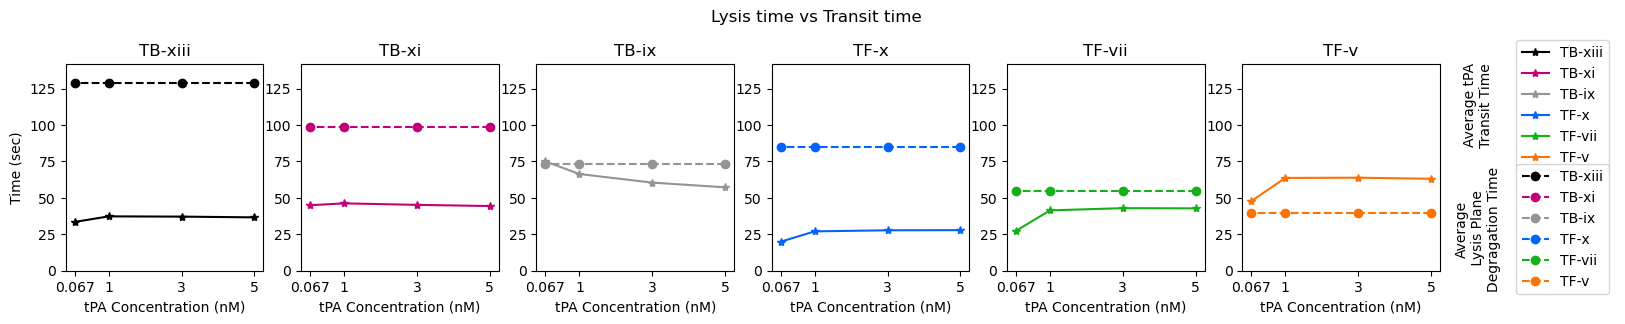

In [52]:
# fig, axs = plt.subplots(
#     nrows=1,
#     ncols=4,
#     sharex=True,
#     sharey=True,
#     figsize=(12, 4),
#     dpi=100,
#     constrained_layout=True,
# )
handles = [{}, {}]
titles = {}
fig = plt.figure(figsize=(20, 3))
gs = mpl.gridspec.GridSpec(
    nrows=2,
    ncols=7,
    hspace=0.5,
    width_ratios=[1, 1, 1, 1, 1, 1, 0.7],
    top=0.8,
)

axs = [fig.add_subplot(gs[:, i]) for i in range(len(scenario_grid))]
# max_v = 1.1 * max(lysis_time.values())
max_v = 1.1 * max(max(x.mean() for x in lysis_time.values()), max(x.mean() for x in transit_time.values()))
for i, row in enumerate(scenario_grid):
    axs[i].set_title(row[0].split("__")[0])
    (plot,) = axs[i].plot(
        [5, 3, 1, 0.067],
        [transit_time[scenario].mean() for scenario in row],
        marker="*",
        color=colors[row[1]],
        label=row[0].split("__")[0],
    )
    handles[0][row[0].split("__")[0]] = plot

    (plot,) = axs[i].plot(
        [5, 3, 1, 0.067],
        [lysis_time[row[0].split("_")[0]].mean()] * 4,
        marker="o",
        linestyle="--",
        color=colors[row[1]],
        label=row[0].split("__")[0],
    )
    handles[1][row[0].split("__")[0]] = plot

    # (plot,) = axs[i].plot(
    #     [5, 3, 1, 0.067],
    #     [np.mean(actual_lysis_times[scenario]) for scenario in row],
    #     marker="o",
    #     linestyle="-",
    #     color=colors[row[1]],
    #     label=row[0].split("__")[0],
    # )
    # handles[2][row[0].split("__")[0]] = plot

    axs[i].set_ylim(0, max_v)
    axs[i].set_xlabel("tPA Concentration (nM)")
    axs[i].set_xticks([5, 3, 1, 0.067], [5, 3, 1, 0.067])
axs[0].set_ylabel("Time (sec)")

fig.suptitle(f"Lysis time vs Transit time")

leg = [fig.add_subplot(gs[i, -1]) for i in range(len(handles))]
leg[0].axis("off")
leg[0].text(
    0, 0.5, "Average tPA\nTransit Time", rotation=90, rotation_mode="anchor", ha="center", va="center"
)
leg[0].legend(
    handles=[handles[0][row[0].split("__")[0]] for row in scenario_grid],
    labels=[row[0].split("__")[0] for row in scenario_grid],
    # bbox_to_anchor=(1, 0),
    loc="center right",
    ncols=1,
)
leg[1].axis("off")
leg[1].text(
    0,
    0.5,
    "Average\n Lysis Plane\nDegragation Time",
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="center",
)
leg[1].legend(
    handles=[handles[1][row[0].split("__")[0]] for row in scenario_grid],
    labels=[row[0].split("__")[0] for row in scenario_grid],
    # bbox_to_anchor=(1, 0),
    loc="center right",
    ncols=1,
)
# leg[2].axis("off")
# leg[2].text(
#     0, 0.5, "Average Fiber\nLysis Time", rotation=90, rotation_mode="anchor", ha="center", va="center"
# )
# leg[2].legend(
#     handles=[handles[2][row[0].split("__")[0]] for row in scenario_grid],
#     labels=[row[0].split("__")[0] for row in scenario_grid],
#     # bbox_to_anchor=(1, 0),
#     loc="center right",
#     ncols=1,
# )

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"lysis and transit times by structure vs tPA concentration.png"),
    bbox_inches="tight",
)

In [43]:
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])
    transit_time[run["scenario"]].tofile(
        os.path.join(e.os_path, f"transit_times_{file_code[:-4]}.csv"), sep=","
    )

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


In [20]:
in_file_code = "_PLG2_tPA01_{input_code}.dat"
for run in runs[[0, 3, 6, 9, 16, 20]]:
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = in_file_code.format(input_code=run["scenario"].split("_")[0])

    print(run["exp_code"], file_code)
    lysis_time[run["scenario"].split("_")[0]].tofile(
        os.path.join(e.os_path, f"lysis_times_{file_code[:-4]}.csv"), sep=","
    )

2024-04-16-1900 _PLG2_tPA01_TB-xi.dat
2024-04-16-1903 _PLG2_tPA01_TF-x.dat
2024-04-16-1906 _PLG2_tPA01_TF-vii.dat
2024-04-16-1909 _PLG2_tPA01_TF-v.dat
2024-04-16-1916 _PLG2_tPA01_TB-ix.dat
2024-04-16-1920 _PLG2_tPA01_TB-xiii.dat


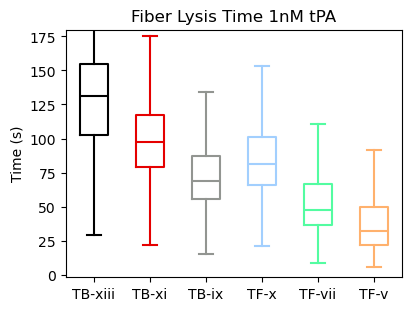

In [59]:
grouping = 2
fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(4, 3),
    dpi=100,
    constrained_layout=True,
)
plots = axs.boxplot(
    [lysis_time[scen.split("_")[0]] for scen in scenario_grid_T[grouping]],
    showfliers=False,
    tick_labels=[scen.split("_")[0] for scen in scenario_grid_T[grouping]],
)
axs.set_ylim(-2, 180)
axs.set_ylabel("Time (s)")
axs.set_title(f"Fiber Lysis Time - {groupings[grouping]}")
col = [colors[s] for s in scenario_grid_T[grouping]]
wid = 1.5
for line, color in zip(plots["whiskers"], [a for a in col for _ in (0, 1)]):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["caps"], [a for a in col for _ in (0, 1)]):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["boxes"], col):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["medians"], col):
    line.set_color(color)
    line.set_linewidth(wid)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber lysis time - {groupings[grouping]}.png"),
    bbox_inches="tight",
)

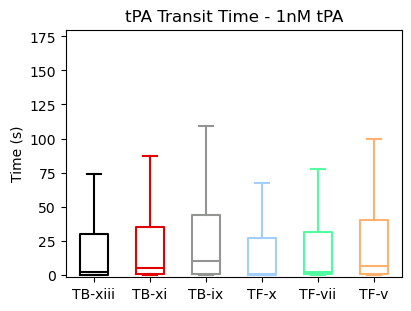

In [60]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(4, 3),
    dpi=100,
    constrained_layout=True,
)
plots = axs.boxplot(
    [transit_time[scen] for scen in scenario_grid_T[grouping]],
    showfliers=False,
    tick_labels=[scen.split("_")[0] for scen in scenario_grid_T[grouping]],
    # showmeans=True,
)
axs.set_ylim(-2, 180)
axs.set_ylabel("Time (s)")
axs.set_title(f"tPA Transit Time - {groupings[grouping]}")
col = [colors[s] for s in scenario_grid_T[grouping]]
wid = 1.5
for line, color in zip(plots["whiskers"], [a for a in col for _ in (0, 1)]):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["caps"], [a for a in col for _ in (0, 1)]):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["boxes"], col):
    line.set_color(color)
    line.set_linewidth(wid)
for line, color in zip(plots["medians"], col):
    line.set_color(color)
    line.set_linewidth(wid)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"tPA transit time - {groupings[grouping]}.png"),
    bbox_inches="tight",
)

#### Generate move & pore vs time plots

In [ ]:
free_distance_data = {}
all_distance_data = {}
pore_data = {}
time_data = {}
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    # marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)
    # marker_times = find_degradation_marker_times(e, marker_frames, tsave)

    tmax = max(len(tsave[sim]) for sim in range(e.macro_params.total_trials))
    time_data[scen["descriptor"]] = [
        tsave[s] for s in range(e.macro_params.total_trials) if tmax == len(tsave[s])
    ][0]
    lysis_data = np.array(
        [
            np.mean([deg_fraction[s][t] for s in range(e.macro_params.total_trials) if t < len(tsave[s])])
            for t in range(tmax)
        ]
    )
    marker_frames = find_degradation_marker_frames(e, [lysis_data], [0.0000000001, 1]).squeeze()

    # Pore size
    pores = get_pore_stats(e, deg, tsave, file_code, num_v_lines=0)

    pore_data[scen["descriptor"]] = np.array(
        [
            np.concatenate(
                [pores[s][t] for s in range(e.macro_params.total_trials) if t < len(tsave[s])]
            ).mean()
            for t in range(tmax)
        ]
    )

    # Molecule binding and diffusion
    mol_bind_events = read_mol_bind_events(e, file_code)
    # mol_bind_events = get_mol_events_in_interval(mol_bind_events, marker_times[:, 1], marker_times[:, 3])

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=all_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2], tsave[sim] + e.macro_params.save_interval / 2
        )
    all_distance_data[scen["descriptor"]] = np.array(
        [
            move_distances[bins == t, -1].mean() if np.count_nonzero(bins == t) > 0 else np.nan
            for t in range(tmax)
        ]
    )

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=free_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2], tsave[sim] + e.macro_params.save_interval / 2
        )
    free_distance_data[scen["descriptor"]] = np.array(
        [
            move_distances[bins == t, -1].mean() if np.count_nonzero(bins == t) > 0 else np.nan
            for t in range(tmax)
        ]
    )

    all_distance_data[scen["descriptor"]] = all_distance_data[scen["descriptor"]][
        marker_frames[0] : marker_frames[1]
    ]
    free_distance_data[scen["descriptor"]] = free_distance_data[scen["descriptor"]][
        marker_frames[0] : marker_frames[1]
    ]
    pore_data[scen["descriptor"]] = pore_data[scen["descriptor"]][marker_frames[0] : marker_frames[1]]
    time_data[scen["descriptor"]] = time_data[scen["descriptor"]][marker_frames[0] : marker_frames[1]]

In [ ]:
for run in runs:
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    print(
        f'{scen["descriptor"]}: {free_distance_data[scen["descriptor"]][0]:.2f} microns / {e.macro_params.pore_size:.3f} microns = {free_distance_data[scen["descriptor"]][0]/e.macro_params.grid_node_distance:.3f}'
    )

In [ ]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=5,
    # sharex=True,
    sharey=True,
    figsize=(14, 7),
    constrained_layout=True,
    # width_ratios=[2, 1, 1, 1, 1],
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        for r, c in [(i, j), (i, -1), (-1, j), (-1, -1)]:
            axs[r, c].plot(
                # time_data[scenario] / 60,
                np.arange(0, 0.99999, 1 / (all_distance_data[scenario].shape[0])),
                all_distance_data[scenario],
                ls="--",
                color=colors[scenario],
                label=scenario,
            )
            axs[r, c].plot(
                # time_data[scenario] / 60,
                np.arange(0, 0.99999, 1 / (free_distance_data[scenario].shape[0])),
                free_distance_data[scenario],
                ls="-.",
                color=colors[scenario],
                label=scenario,
            )
            axs[r, c].plot(
                # time_data[scenario] / 60,
                np.arange(0, 0.99999, 1 / (pore_data[scenario].shape[0])),
                pore_data[scenario],
                ls=":",
                color=colors[scenario],
                label=scenario,
            )
        axs[i, j].set_title(scenario)
        axs[i, j].set_xticks(
            [0, 0.5, 1],
            labels=[
                f"{time_data[scenario][k] / 60:.0f}"
                for k in [0, (time_data[scenario].shape[0] - 1) // 2, time_data[scenario].shape[0] - 1]
            ],
        )

for i, title in enumerate(
    ["Fixed Concentration - High", "Fixed Ratio", "Fixed Concentration - Low", "All Scenarios"]
):
    axs[i, -1].set_title(title)
    if i % 2 == 0:
        axs[i, 0].set_ylabel("Distance (microns)")

for j, title in enumerate(
    [
        "Thin Fibers, Loose Mesh",
        "Thick Fibers, Loose Mesh",
        "Thin Fibers, Dense Mesh",
        "Thick Fibers, Dense Mesh",
        "All Scenarios",
    ]
):
    axs[-1, j].set_title(title)
    axs[-1, j].set_xlabel("Simulation Time Elapsed (min)")

fig.suptitle(f"Comparison of Mean tPA Diffusion Distance to Mean Pore Size.")
all_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="--", label="Mean tPA diffusion distance between bindings (microns)"
)
free_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="-.", label="Mean tPA diffusion distance while unbound (microns)"
)
pore_legend = mpl.lines.Line2D([], [], color="black", ls=":", label="Mean pore size (microns)")
fig.legend(
    handles=[all_distance_legend, free_distance_legend, pore_legend],
    bbox_to_anchor=(0.5, -0.05),
    loc="lower center",
    ncols=3,
)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, "tPA Diffusion vs Pore Size (time).png"), bbox_inches="tight")
pass

#### Generate move & pore vs degradation plots

In [ ]:
all_distance_mean = {}
free_distance_mean = {}
pore_mean = {}
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, np.arange(0, 1.05, 0.1))
    marker_times = find_degradation_marker_times(e, marker_frames, tsave)

    pores = get_pore_stats(e, deg, tsave, file_code, num_v_lines=0)

    mol_bind_events = read_mol_bind_events(e, file_code)
    # mol_bind_events = get_mol_events_in_interval(mol_bind_events, marker_times[:, 1], marker_times[:, 3])

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=all_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2] / 60, marker_times[sim]
        )
    all_distance_mean[scen["descriptor"]] = np.array(
        [move_distances[bins == t + 1, -1].mean() for t in range(len(marker_times[0]) - 1)]
    )

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=free_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2] / 60, marker_times[sim]
        )
    free_distance_mean[scen["descriptor"]] = np.array(
        [move_distances[bins == t + 1, -1].mean() for t in range(len(marker_times[0]) - 1)]
    )

    pore_mean[scen["descriptor"]] = np.array(
        [
            np.concatenate(
                [pores[sim][marker_frames[sim][t]] for sim in range(e.macro_params.total_trials)]
            ).mean()
            for t in range(len(marker_frames[0]))
        ]
    )

In [ ]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=5,
    sharex=True,
    sharey=True,
    figsize=(14, 7),
    constrained_layout=True,
    # width_ratios=[2, 1, 1, 1, 1],
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        for r, c in [(i, j), (i, -1), (-1, j), (-1, -1)]:
            axs[r, c].plot(all_distance_mean[scenario][2:9], ls="--", color=colors[scenario], label=scenario)
            axs[r, c].plot(free_distance_mean[scenario][2:9], ls="-.", color=colors[scenario], label=scenario)
            axs[r, c].plot(pore_mean[scenario][2:9], ls=":", color=colors[scenario], label=scenario)
            axs[r, c].set_xticks(
                range(0, 7, 3),
                labels=[f"{i:.0%}" for i in np.arange(0.2, 0.9, 0.3)],
            )
        # axs[i, j].tick_params(labelrotation=90)
        axs[i, j].set_title(scenario)

for i, title in enumerate(
    ["Fixed Concentration - High", "Fixed Ratio", "Fixed Concentration - Low", "All Scenarios"]
):
    axs[i, -1].set_title(title)
    if i % 2 == 0:
        axs[i, 0].set_ylabel("Distance (microns)")

for j, title in enumerate(
    [
        "Thin Fibers, Loose Mesh",
        "Thick Fibers, Loose Mesh",
        "Thin Fibers, Dense Mesh",
        "Thick Fibers, Dense Mesh",
        "All Scenarios",
    ]
):
    axs[-1, j].set_title(title)
    axs[-1, j].set_xlabel("Percent of fibers degraded")

fig.suptitle(f"Comparison of Mean tPA Diffusion Distance to Mean Pore Size at x% clot lysis.")
all_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="--", label="Mean tPA diffusion distance between bindings (microns)"
)
free_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="-.", label="Mean tPA diffusion distance while unbound (microns)"
)
pore_legend = mpl.lines.Line2D([], [], color="black", ls=":", label="Mean pore size (microns)")
fig.legend(
    handles=[all_distance_legend, free_distance_legend, pore_legend],
    bbox_to_anchor=(0.5, -0.05),
    loc="lower center",
    ncols=3,
)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, "tPA Diffusion vs Pore Size (deg).png"), bbox_inches="tight")
pass

In [ ]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=5,
    sharex=True,
    # sharey=True,
    figsize=(14, 7),
    constrained_layout=True,
    # width_ratios=[2, 1, 1, 1, 1],
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        for r, c in [(i, j), (i, -1), (-1, j), (-1, -1)]:
            axs[r, c].plot(
                all_distance_mean[scenario][2:9] / pore_mean[scenario][2:9],
                ls="--",
                color=colors[scenario],
                label=scenario,
            )
            axs[r, c].plot(
                free_distance_mean[scenario][2:9] / pore_mean[scenario][2:9],
                ls="-.",
                color=colors[scenario],
                label=scenario,
            )
            axs[i, j].set_xticks(
                range(0, 7, 3),
                labels=[f"{i:.0%}" for i in np.arange(0.2, 0.9, 0.3)],
            )
        axs[i, j].set_title(scenario)

for i, title in enumerate(
    ["Fixed Concentration - High", "Fixed Ratio", "Fixed Concentration - Low", "All Scenarios"]
):
    axs[i, -1].set_title(title)
    if i % 3 == 2:
        axs[i, 0].set_ylabel("Distance (in multiples of mean pore size)")

for j, title in enumerate(
    [
        "Thin Fibers, Loose Mesh",
        "Thick Fibers, Loose Mesh",
        "Thin Fibers, Dense Mesh",
        "Thick Fibers, Dense Mesh",
        "All Scenarios",
    ]
):
    axs[-1, j].set_title(title)
    axs[-1, j].set_xlabel("Percent of fibers degraded")


fig.suptitle(f"Mean tPA Diffusion Distance normalized to Mean Pore Size at x% clot lysis.")
all_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="--", label="Mean tPA diffusion distance between bindings (microns)"
)
free_distance_legend = mpl.lines.Line2D(
    [], [], color="black", ls="-.", label="Mean tPA diffusion distance while unbound (microns)"
)
fig.legend(
    handles=[all_distance_legend, free_distance_legend],
    bbox_to_anchor=(0.5, -0.05),
    loc="lower center",
    ncols=2,
)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, "tPA Diffusion in Pore Lengths (deg).png"), bbox_inches="tight")
pass

#### Generate move type breakdown vs degradation plots

In [ ]:
macro_distance_mean = {}
micro_distance_mean = {}
free_distance_mean = {}
pore_mean = {}
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, np.arange(0, 1.05, 0.1))
    marker_times = find_degradation_marker_times(e, marker_frames, tsave)

    pores = get_pore_stats(e, deg, tsave, file_code, num_v_lines=0)

    mol_bind_events = read_mol_bind_events(e, file_code)
    # mol_bind_events = get_mol_events_in_interval(mol_bind_events, marker_times[:, 1], marker_times[:, 3])

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=macro_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2] / 60, marker_times[sim]
        )
    macro_distance_mean[scen["descriptor"]] = np.array(
        [move_distances[bins == t + 1, -1].mean() for t in range(len(marker_times[0]) - 1)]
    )

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=micro_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2] / 60, marker_times[sim]
        )
    micro_distance_mean[scen["descriptor"]] = np.array(
        [move_distances[bins == t + 1, -1].mean() for t in range(len(marker_times[0]) - 1)]
    )

    move_distances = get_move_distances(e, mol_bind_events, file_code, move_function=free_movement)
    bins = np.empty(move_distances.shape[0])
    for sim in range(e.macro_params.total_trials):
        bins[move_distances[:, 0] == sim] = np.digitize(
            move_distances[move_distances[:, 0] == sim, 2] / 60, marker_times[sim]
        )
    free_distance_mean[scen["descriptor"]] = np.array(
        [move_distances[bins == t + 1, -1].mean() for t in range(len(marker_times[0]) - 1)]
    )

    pore_mean[scen["descriptor"]] = np.array(
        [
            np.concatenate(
                [pores[sim][marker_frames[sim][t]] for sim in range(e.macro_params.total_trials)]
            ).mean()
            for t in range(len(marker_frames[0]))
        ]
    )

In [ ]:
fig, axs = plt.subplots(
    nrows=3,
    ncols=4,
    sharex=True,
    sharey=True,
    figsize=(14, 7),
    constrained_layout=True,
    # width_ratios=[2, 1, 1, 1, 1],
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        axs[i, j].stackplot(
            np.arange(7),
            free_distance_mean[scenario][2:9],
            micro_distance_mean[scenario][2:9],
            macro_distance_mean[scenario][2:9],
            labels=[
                "Distance diffused while unbound (microns)",
                "Distance diffused while bound to small FDP (microns)",
                "Distance diffused while bound to large FDP (microns)",
            ],
        )
        axs[i, j].plot(pore_mean[scenario][2:9], ls=":", color="black", label="Mean pore size (microns)")
        axs[i, j].set_xticks(
            range(0, 7, 3),
            labels=[f"{i:.0%}" for i in np.arange(0.2, 0.9, 0.3)],
        )
        # axs[i, j].tick_params(labelrotation=90)
        axs[i, j].set_title(scenario)


# axs[i, 0].set_ylabel("Distance (microns)")
# axs[-1, j].set_xlabel("Percent of fibers degraded")

fig.suptitle(f"Comparison of Mean tPA Diffusion Distance to Mean Pore Size at x% clot lysis.")
pore_legend = mpl.lines.Line2D([], [], color="black", ls=":", label="Mean pore size (microns)")
fig.legend(
    *axs[0, 0].get_legend_handles_labels(),
    # handles=[all_distance_legend, free_distance_legend, pore_legend],
    bbox_to_anchor=(0.5, -0.05),
    loc="lower center",
    ncols=4,
)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, "tPA Diffusion by type vs Pore Size (deg).png"), bbox_inches="tight")
pass

### Scatterplots of individual molecules

In [ ]:
fig, axs = plt.subplots(
    nrows=4, ncols=1, sharex=False, sharey=False, figsize=(12, 12), constrained_layout=True
)
# ax.scatter(transit_times[0], transit_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:red")
axs[0].scatter(
    macro_unbound_times[0], macro_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:green"
)
axs[0].set_title("Macro-Unbinding")
axs[1].scatter(
    micro_unbound_times[0], micro_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:blue"
)
axs[1].set_title("Micro-Unbinding")
axs[2].scatter(
    kinetic_unbound_times[0], kinetic_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:red"
)
axs[2].set_title("Kinetic-Unbinding")
axs[3].scatter(
    macro_unbound_times[0], macro_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:green"
)
axs[3].set_title("All Molecules")
axs[3].scatter(
    micro_unbound_times[0], micro_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:blue"
)
axs[3].scatter(
    kinetic_unbound_times[0], kinetic_unbound_times[1], marker="o", s=(72.0 / fig.dpi) ** 2, c="xkcd:red"
)


for i in range(4):
    axs[i].set_ylabel("Molecule Transit Time (min)")
    axs[i].set_xticks(marker_times[0][1:], ["20%", "50%", "80%"])
    axs[i].set_xlabel("Fraction of Fibers Degraded")
axs[0].axhline(1, color=(0, 0, 0))
axs[1].set_ylim(-0.1, 1)
# fig.suptitle("Time from unbinding to rebinding")

### Plot degradation heatmaps

In [51]:
f_deg_amount = {}
degradation_amount = {}
degradation_distance = {}
time = {}
padded_time = {}
front_distance = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    padded_time[run["scenario"]] = tsave[0]
    t_max = len(tsave[0])
    for i in range(1, e.macro_params.total_trials):
        if len(tsave[i]) > t_max:
            padded_time[run["scenario"]] = tsave[i]
            t_max = len(tsave[i])

    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    row_deg = find_row_deg_fraction(e, deg, tsave)

    fronts = find_front(e, row_deg)
    padded_fronts = [
        np.pad(front, (0, t_max - len(front)), constant_values=e.macro_params.fiber_rows - 1)
        for front in fronts
    ]
    front_distance[run["scenario"]] = (
        np.mean(
            np.stack(padded_fronts),
            axis=0,
        )
        * e.macro_params.grid_node_distance
    )

    max_t = min(marker_frames[sim, -1] for sim in range(e.macro_params.total_trials))
    # max_t = 300 // (run["save_interval"] * run["data_divisor"]) + 5
    time[run["scenario"]] = tsave[0][:max_t]
    degradation_amount[run["scenario"]] = np.stack(
        [row_deg[sim][:max_t] for sim in range(e.macro_params.total_trials)]
    )

    degradation_distance[run["scenario"]] = [
        delta * e.macro_params.grid_node_distance
        for delta in range(degradation_amount[run["scenario"]].shape[-1])
    ]

    f_deg_amount[run["scenario"]] = np.mean(
        np.mean(fiber_degradation_linear_extrapolation(e, tsave, deg), axis=0), axis=-1
    )[:max_t]

    # # Append Empty Rows
    # f_deg_amount[run["scenario"]] = np.append(
    #     np.full((max_t, e.macro_params.empty_rows), 0.0), f_deg_amount[run["scenario"]], axis=1
    # )

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


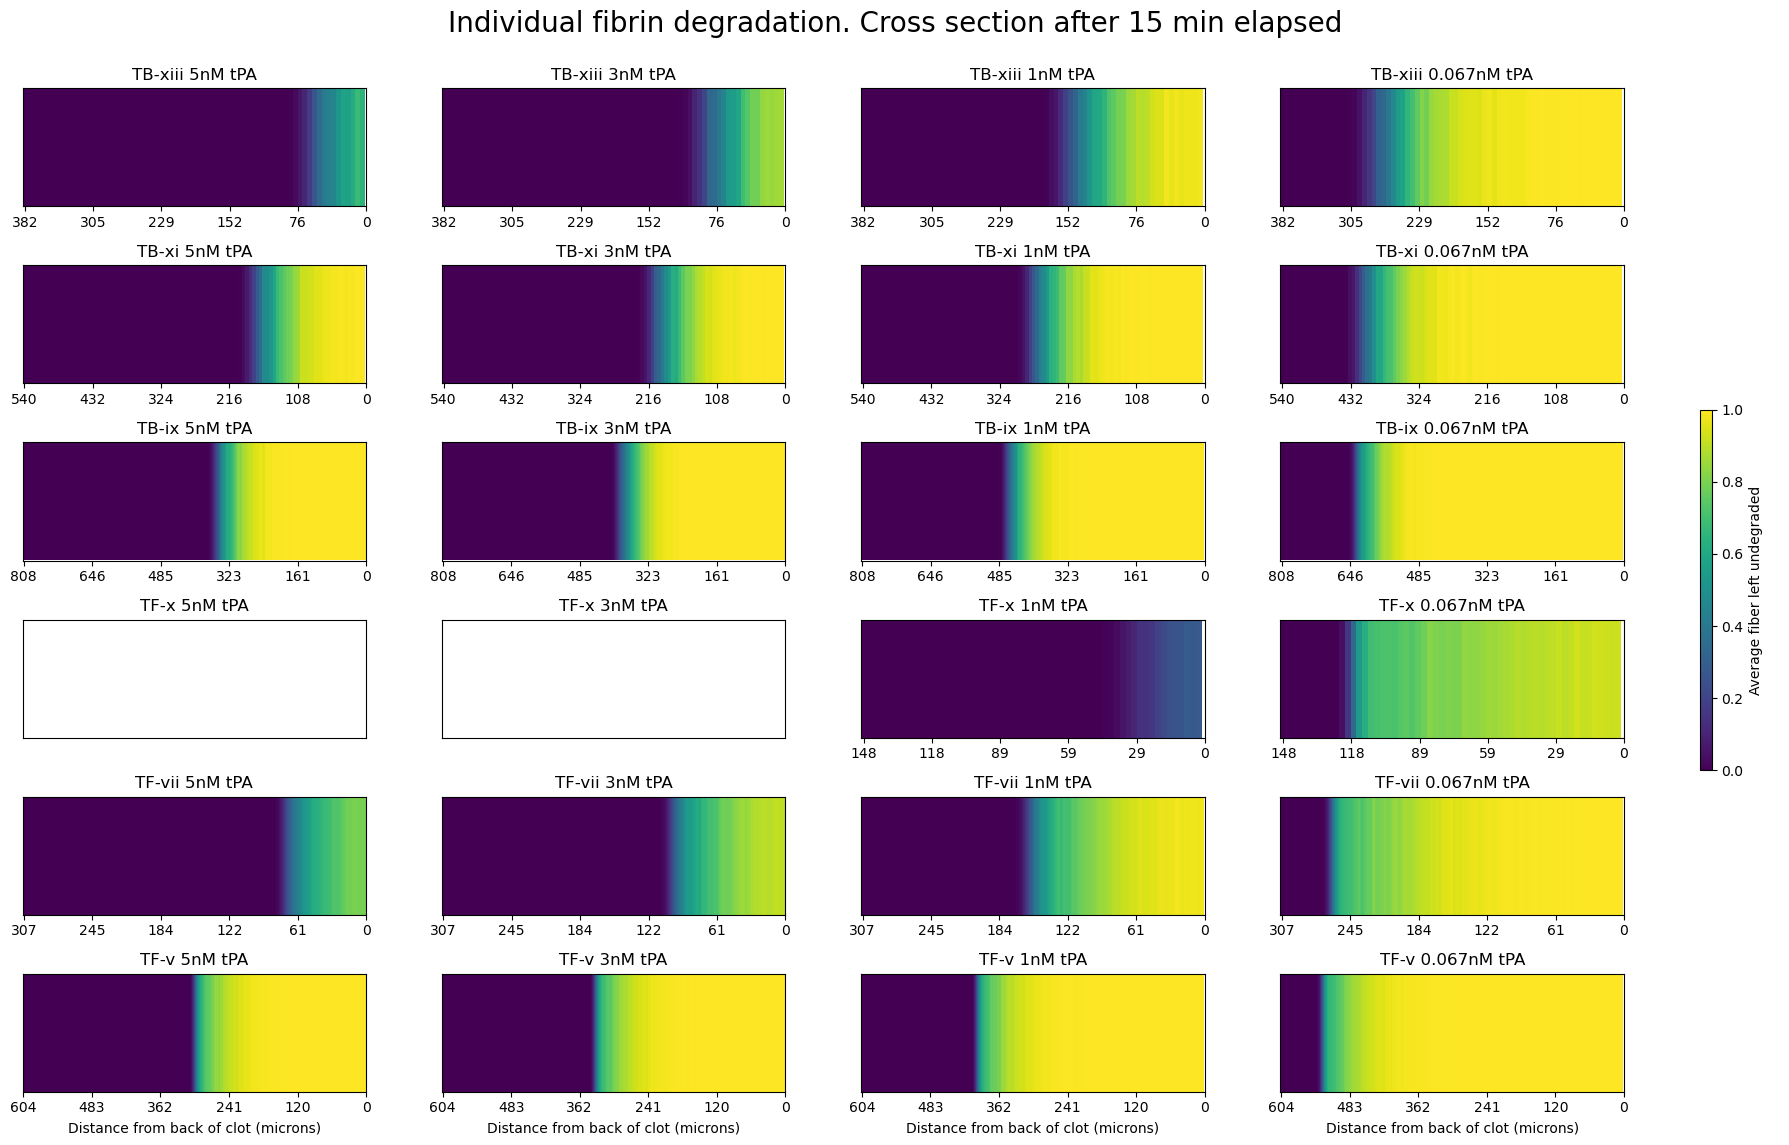

In [21]:
time_min = 15
fig = plt.figure(figsize=(18, 12))
gs = mpl.gridspec.GridSpec(nrows=6, ncols=5, width_ratios=[3, 3, 3, 3, 0.7], hspace=0.5)

ax = fig.add_subplot(gs[:, -1])
ax.axis("off")
vmin, vmax, vcenter = 0, 1, 0.5
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = "viridis"
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(
    cbar, ax=ax, location="left", aspect=30, label="Average fiber left undegraded", pad=-1, shrink=3
)
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

axs = np.array(
    [[fig.add_subplot(gs[i, j]) for j in range(len(scenario_grid[i]))] for i in range(len(scenario_grid))]
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        axs[i, j].set_title(pretty_print_scen(scenario))
        run = runs[runs["scenario"] == scenario][0]
        axs[i, j].set_yticks([])
        if f_deg_amount[scenario].shape[0] <= (time_min * 60) // (run["save_interval"] * run["data_divisor"]):
            axs[i, j].set_xticks([])
            continue
        axs[i, j].imshow(
            f_deg_amount[scenario][(time_min * 60) // (run["save_interval"] * run["data_divisor"])].reshape(
                (1, f_deg_amount[scenario].shape[-1])
            ),
            aspect="auto",
            norm=norm,
        )
        # axs[i, 0].set_ylabel("Simulation time elapsed (min)")
        # axs[i, j].set_yticks(
        #     np.arange(0, len(time[scenario]), len(time[scenario]) // 5),
        #     [int(t / 60) for t in time[scenario][:: len(time[scenario]) // 5]],
        # )
        axs[i, j].set_xticks(
            np.arange(0, len(degradation_distance[scenario]) + 1, len(degradation_distance[scenario]) / 5),
            np.arange(degradation_distance[scenario][-1], -1, -degradation_distance[scenario][-1] / 5).astype(
                int
            ),
        )
        axs[-1, j].set_xlabel("Distance from back of clot (microns)")

fig.suptitle(f"Individual fibrin degradation. Cross section after {time_min} min elapsed", fontsize=20)
gs.tight_layout(fig, rect=[0, 0.03, 1, 0.98])

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation heat maps at {time_min} min.png"), bbox_inches="tight"
)

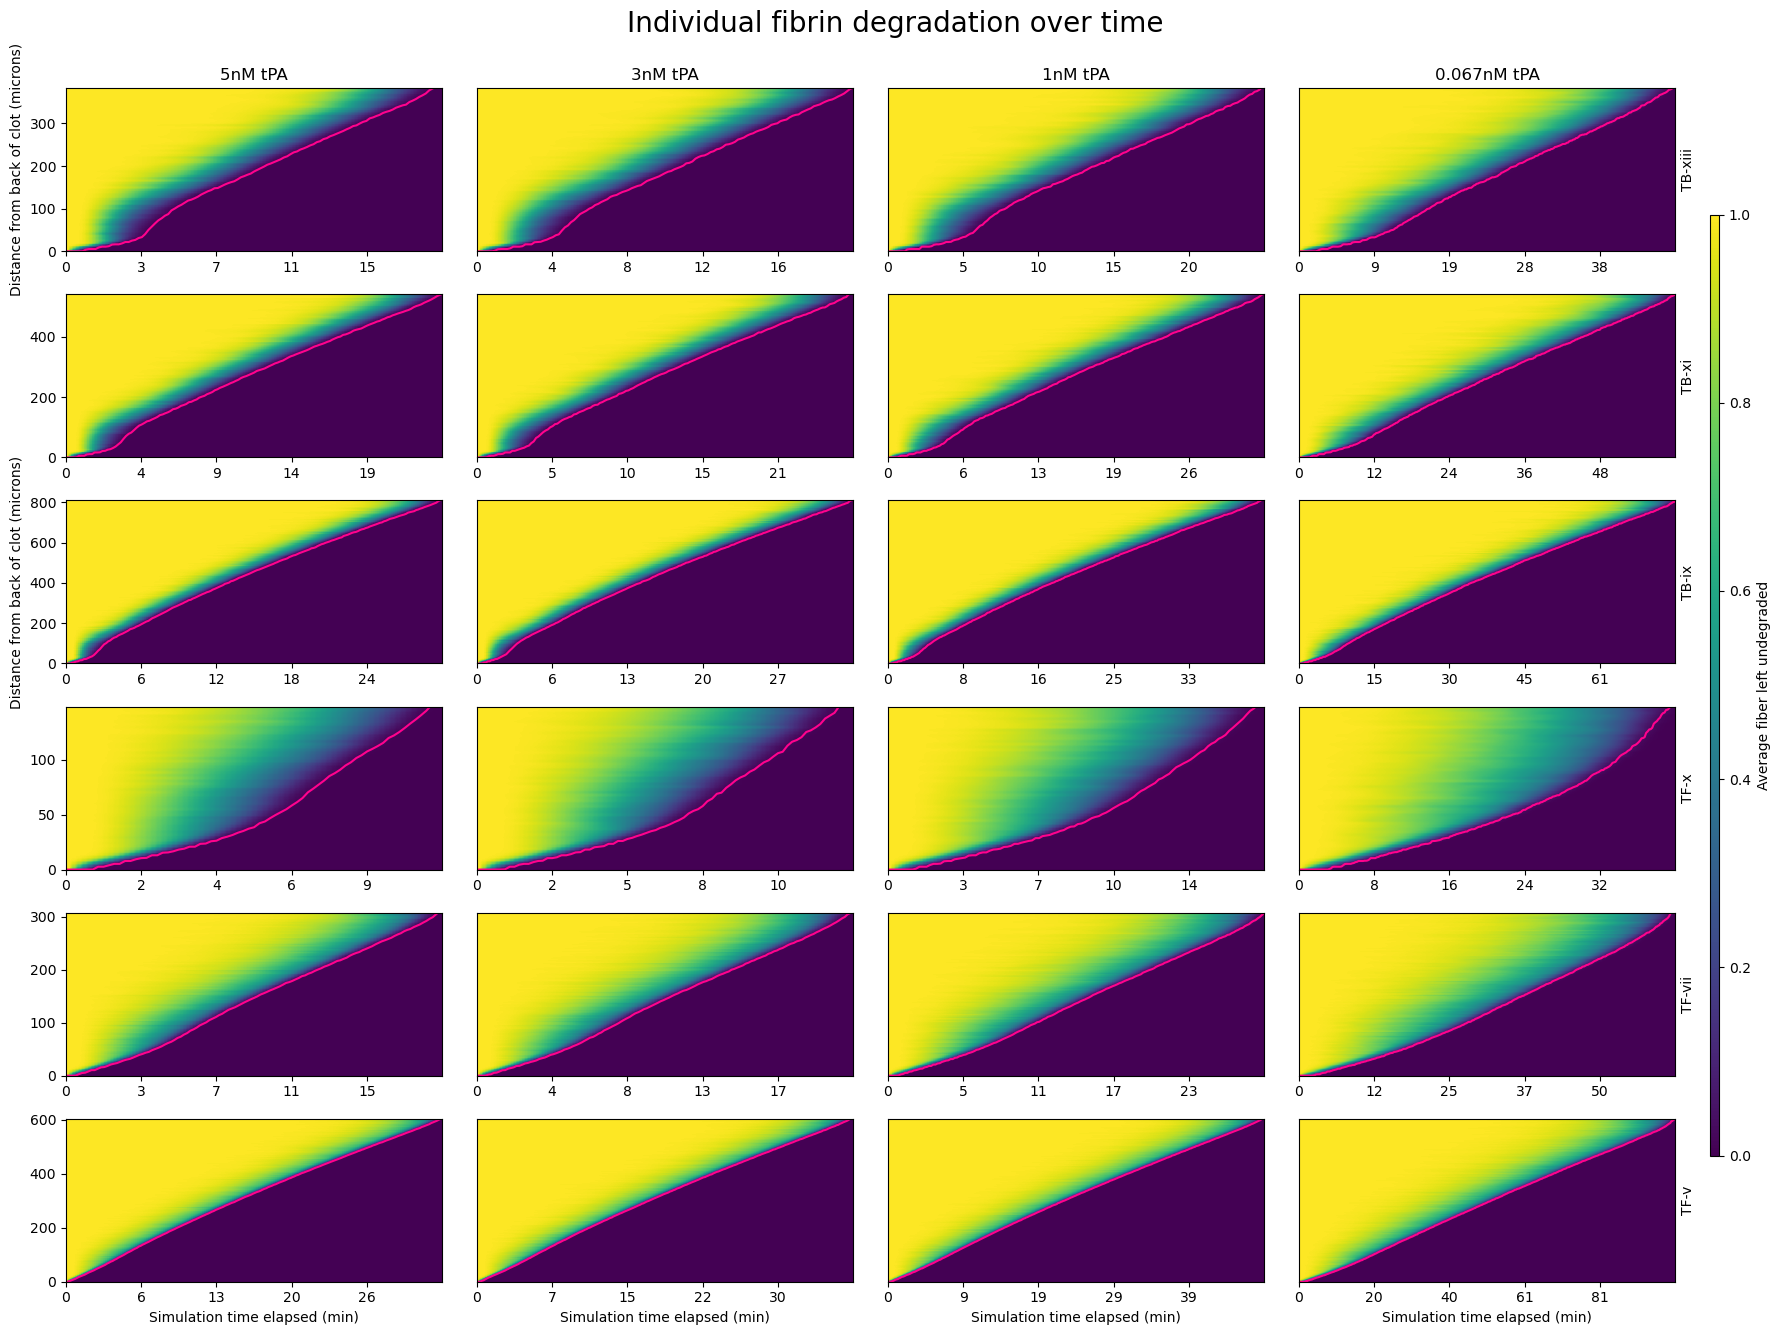

In [22]:
fig = plt.figure(figsize=(18, 14))
gs = mpl.gridspec.GridSpec(nrows=6, ncols=5, width_ratios=[3, 3, 3, 3, 0.5], hspace=0.2, top=0.9, wspace=0.1)

ax = fig.add_subplot(gs[:, -1])
ax.axis("off")
vmin, vmax, vcenter = 0, 1, 0.5
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = "viridis"
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(
    cbar,
    ax=ax,
    location="left",
    aspect=100,
    label="Average fiber left undegraded",
)  # , pad=-0.5)  # , shrink=0.5)  # )
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

axs = np.array(
    [[fig.add_subplot(gs[i, j]) for j in range(len(scenario_grid[i]))] for i in range(len(scenario_grid))]
)
# fig, axs = plt.subplots(
#     nrows=2, ncols=4, sharex=False, sharey=False, figsize=(12, 8), dpi=100, constrained_layout=True
# )
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        axs[0, j].set_title(groupings[j])
        axs[i, -1].set_ylabel(pretty_print_scen(scenario).split(" ")[0])
        axs[i, -1].yaxis.set_label_position("right")
        axs[i, j].imshow(
            f_deg_amount[scenario].T,
            aspect="auto",
            norm=norm,
            extent=(0, time[scenario][-1], degradation_distance[scenario][-1], 0),
        )
        axs[i, j].plot(padded_time[scenario], front_distance[scenario], color="xkcd:hot pink")
        axs[i, j].invert_yaxis()
        axs[i * 2 % 4, 0].set_ylabel("Distance from back of clot (microns)")
        axs[i, j].set_xlim(0, time[scenario][-1])
        if j != 0:
            axs[i, j].set_yticks([])
        axs[i, j].set_xticks(
            np.arange(0, time[scenario][-1], time[scenario][-1] / 5).astype(int),
            np.arange(0, time[scenario][-1] / 60, time[scenario][-1] / 60 / 5).astype(int),
        )
        axs[i, j].set_ylim(0, degradation_distance[scenario][-1])
        # axs[i, j].set_yticks(
        #     np.arange(0, len(degradation_distance[scenario]) + 1, len(degradation_distance[scenario]) / 5),
        #     np.arange(degradation_distance[scenario][-1], -1, -degradation_distance[scenario][-1] / 5).astype(
        #         int
        #     ),
        # )
        axs[-1, j].set_xlabel("Simulation time elapsed (min)")

fig.suptitle("Individual fibrin degradation over time", fontsize=20)
gs.tight_layout(fig, rect=[0, 0.03, 1, 0.98])

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, f"fiber degradation heat maps.png"), bbox_inches="tight")

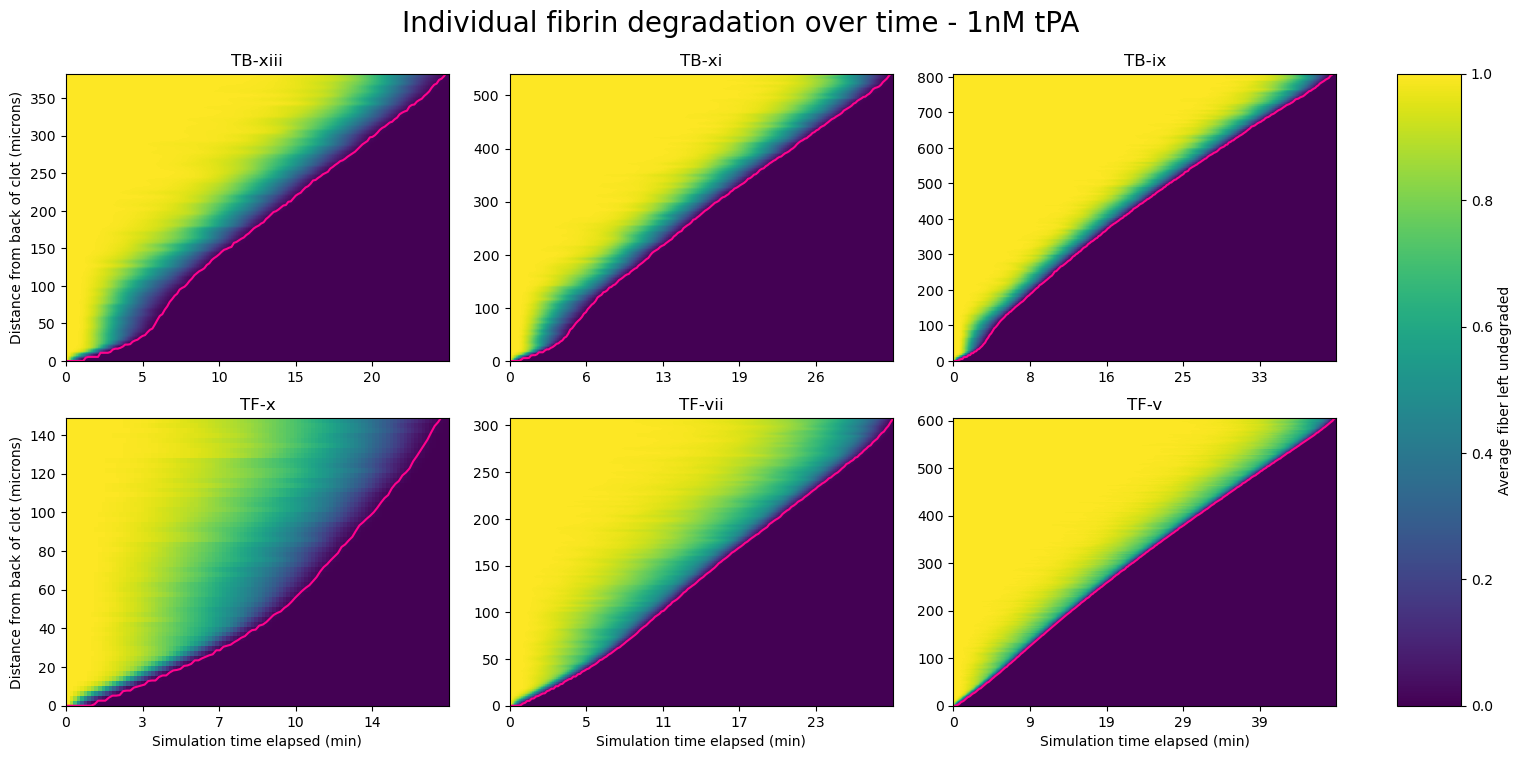

In [52]:
grouping = 2
fig = plt.figure(figsize=(18, 8))
gs = mpl.gridspec.GridSpec(nrows=2, ncols=4, width_ratios=[3, 3, 3, 0.5], hspace=0.2, top=0.9, wspace=0.2)

ax = fig.add_subplot(gs[:, -1])
# ax.set_xlim(1, 3)
# ax.set_ylim(1, 3)
# ax.axis("off")
vmin, vmax, vcenter = 0, 1, 0.5
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = "viridis"
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(
    cbar,
    cax=ax,
    fraction=0.5,
    # location="left",
    # aspect=100,
    # pad=5,
    # shrink=0.5,
    label="Average fiber left undegraded",
)
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

axs = np.array(
    [[fig.add_subplot(gs[i, j]) for j in range(len(scenario_grid_T[grouping]) // 2)] for i in range(2)]
)

row = scenario_grid_T[grouping]
mod = len(row) // 2
for j, scenario in enumerate(row):
    axs[j // mod, j % mod].imshow(
        f_deg_amount[scenario].T,
        aspect="auto",
        norm=norm,
        extent=(0, time[scenario][-1], degradation_distance[scenario][-1], 0),
    )
    axs[j // mod, j % mod].set_title(scenario.split("_")[0])
    axs[j // mod, j % mod].plot(padded_time[scenario], front_distance[scenario], color="xkcd:hot pink")
    axs[j // mod, j % mod].invert_yaxis()
    axs[j // mod, 0].set_ylabel("Distance from back of clot (microns)")
    axs[j // mod, j % mod].set_xlim(0, time[scenario][-1])
    axs[j // mod, j % mod].set_xticks(
        np.arange(0, time[scenario][-1], time[scenario][-1] / 5).astype(int),
        np.arange(0, time[scenario][-1] / 60, time[scenario][-1] / 60 / 5).astype(int),
    )
    axs[j // mod, j % mod].set_ylim(0, degradation_distance[scenario][-1])
    # axs[i, j].set_yticks(
    #     np.arange(0, len(degradation_distance[scenario]) + 1, len(degradation_distance[scenario]) / 5),
    #     np.arange(degradation_distance[scenario][-1], -1, -degradation_distance[scenario][-1] / 5).astype(
    #         int
    #     ),
    # )
    axs[-1, j % mod].set_xlabel("Simulation time elapsed (min)")

fig.suptitle(f"Individual fibrin degradation over time - {groupings[grouping]}", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation heat maps - {groupings[grouping]}.png"), bbox_inches="tight"
)

In [23]:
cut_distance = 150
time_min = 15
cut = {k: len(d) - np.argmin(np.array(d[::-1]) > cut_distance) - 1 for k, d in degradation_distance.items()}
# cut_t = {k: np.argmin(d[:, cut[k]]) for k, d in f_deg_amount.items()}
# cut_t = {k: time_min * 60 for k in f_deg_amount.keys()}
cut_t = {k: len(d) - np.argmin(np.array(d[::-1]) > time_min * 60) for k, d in padded_time.items()}

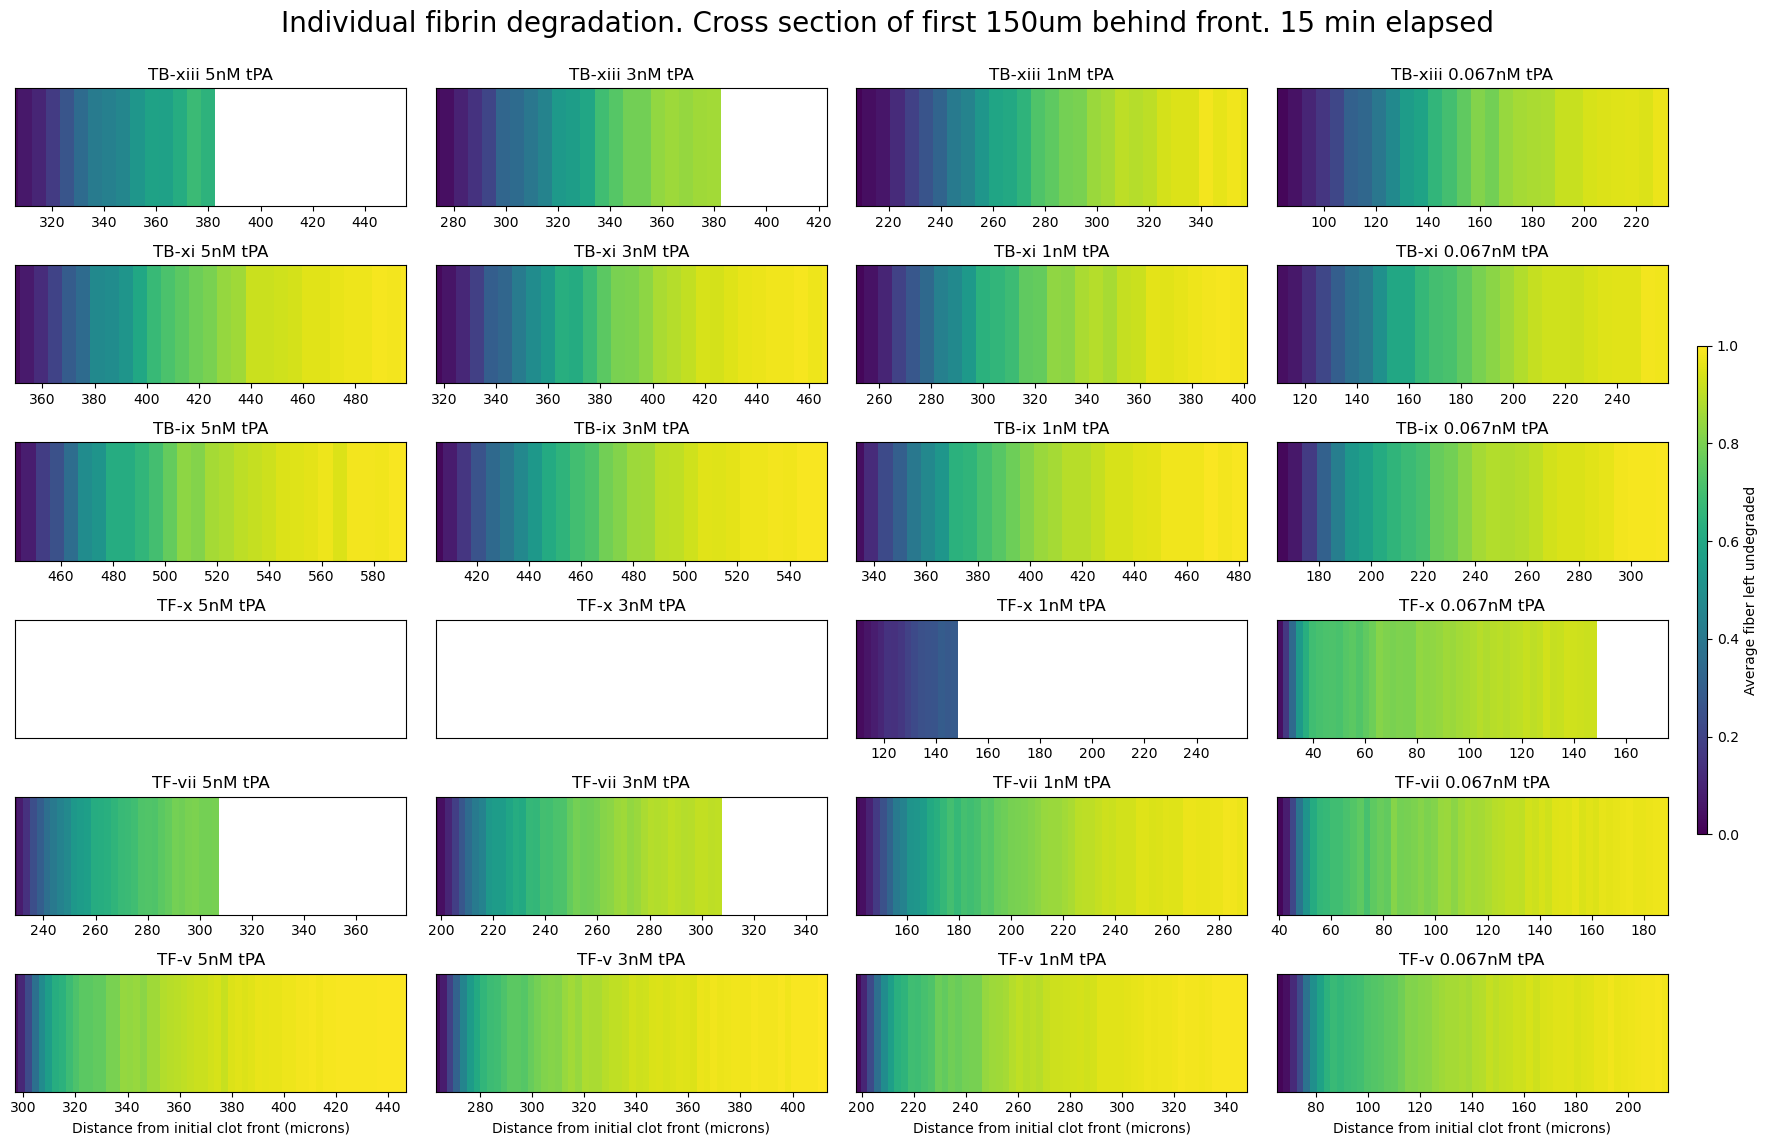

In [24]:
fig = plt.figure(figsize=(18, 12))
gs = mpl.gridspec.GridSpec(nrows=6, ncols=5, width_ratios=[3, 3, 3, 3, 0.5], hspace=0.5)

ax = fig.add_subplot(gs[:, -1])
ax.axis("off")
vmin, vmax, vcenter = 0, 1, 0.5
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = "viridis"
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(
    cbar,
    ax=ax,
    location="left",
    aspect=50,
    label="Average fiber left undegraded",
    # pad=-3,
    shrink=2,
)
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

axs = np.array(
    [[fig.add_subplot(gs[i, j]) for j in range(len(scenario_grid[i]))] for i in range(len(scenario_grid))]
)
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        axs[i, j].set_title(pretty_print_scen(scenario))
        run = runs[runs["scenario"] == scenario][0]
        axs[i, j].set_yticks([])
        if f_deg_amount[scenario].shape[0] <= (time_min * 60) // (run["save_interval"] * run["data_divisor"]):
            axs[i, j].set_xticks([])
            continue
        axs[i, j].imshow(
            f_deg_amount[scenario][(time_min * 60) // (run["save_interval"] * run["data_divisor"])].reshape(
                (1, f_deg_amount[scenario].shape[-1])
            ),
            extent=(0, degradation_distance[scenario][-1], 0, 1),
            aspect="auto",
            norm=norm,
        )
        slice_start = np.argmax(
            f_deg_amount[scenario][(time_min * 60) // (run["save_interval"] * run["data_divisor"])] > 0.01
        )
        axs[i, j].set_xlim(
            (
                degradation_distance[scenario][slice_start],
                degradation_distance[scenario][slice_start] + cut_distance,
            )
        )
        # axs[i, 0].set_ylabel("Simulation time elapsed (min)")
        # axs[i, j].set_yticks(
        #     np.arange(0, len(time[scenario]), len(time[scenario]) // 5),
        #     [int(t / 60) for t in time[scenario][:: len(time[scenario]) // 5]],
        # )
        # axs[i, j].set_xticks(
        #     np.arange(0, cut[scenario], cut[scenario] / 5),
        #     np.arange(
        #         0,
        #         degradation_distance[scenario][cut[scenario]],
        #         degradation_distance[scenario][cut[scenario]] / 5,
        #     ).astype(int),
        # )
        axs[-1, j].set_xlabel("Distance from initial clot front (microns)")

fig.suptitle(
    f"Individual fibrin degradation. Cross section of first {cut_distance}um behind front. {time_min} min elapsed",
    fontsize=20,
)
gs.tight_layout(fig, rect=[0, 0.03, 1, 0.98])

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation heat maps first {cut_distance}um at {time_min} min.png"),
    bbox_inches="tight",
)

Take this figure
 - Transpose
 - Cut off at 150um & 15 min

Also define front and plot on same axes

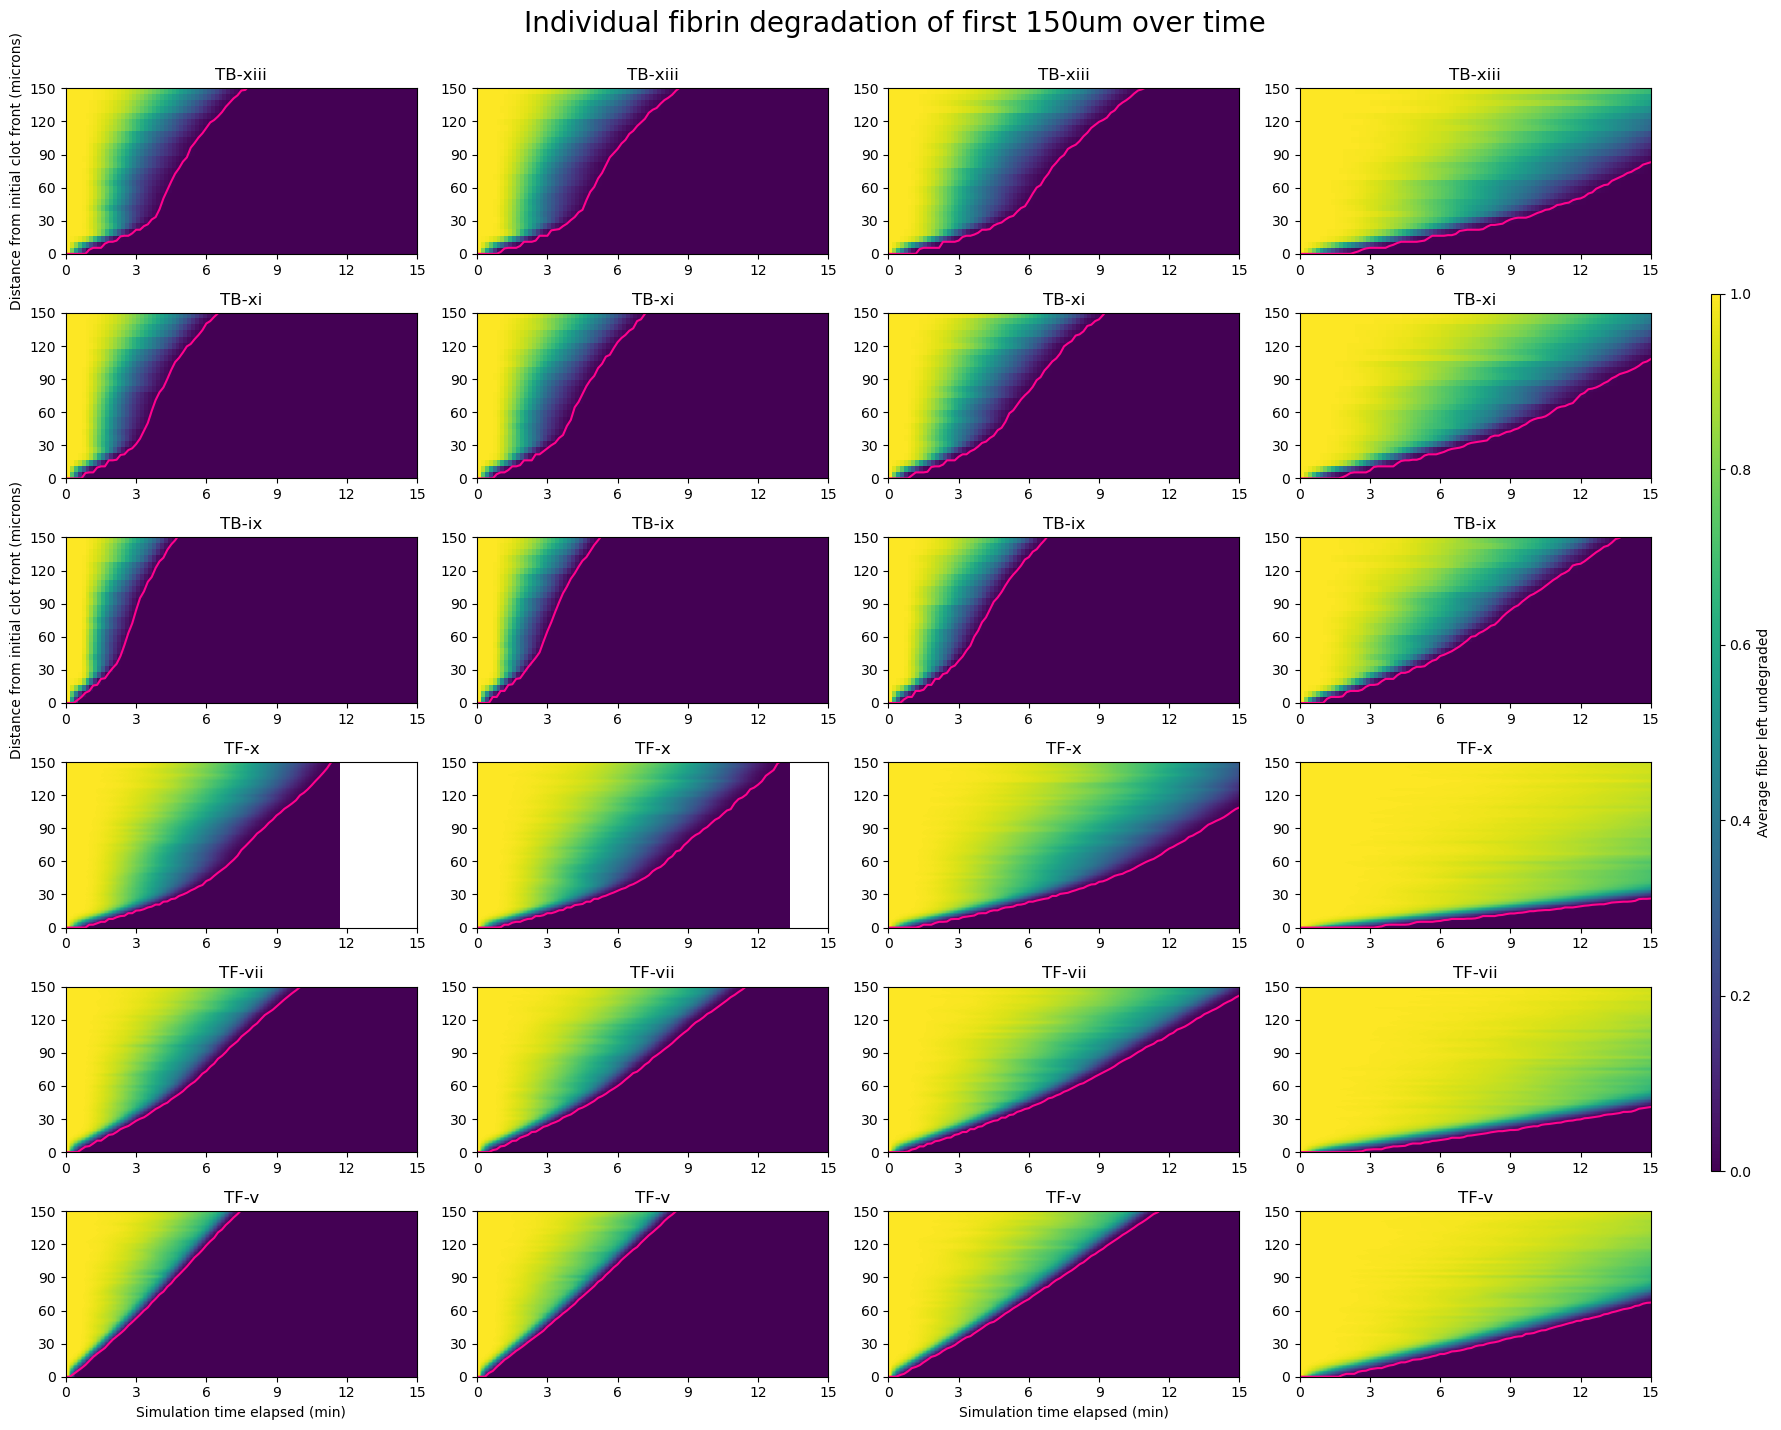

In [27]:
fig = plt.figure(figsize=(18, 15))
gs = mpl.gridspec.GridSpec(nrows=6, ncols=5, width_ratios=[3, 3, 3, 3, 0.5], hspace=0.5)

ax = fig.add_subplot(gs[:, -1])
ax.axis("off")
vmin, vmax, vcenter = 0, 1, 0.5
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = "viridis"
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(
    cbar,
    ax=ax,
    location="left",
    aspect=100,
    label="Average fiber left undegraded",
)  # , pad=-0.5)  # , shrink=0.5)  # )
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

axs = np.array(
    [[fig.add_subplot(gs[i, j]) for j in range(len(scenario_grid[i]))] for i in range(len(scenario_grid))]
)
# fig, axs = plt.subplots(
#     nrows=2, ncols=4, sharex=False, sharey=False, figsize=(12, 8), dpi=100, constrained_layout=True
# )
for i, row in enumerate(scenario_grid):
    for j, scenario in enumerate(row):
        # axs[i, j].set_xlim((0, cut_distance))
        # axs[i, j].set_ylim((0, time_min))
        axs[i, j].set_title(pretty_print_scen(scenario).split(" ")[0])
        axs[i, j].imshow(
            f_deg_amount[scenario][: cut_t[scenario], : cut[scenario]].T,
            extent=(0, min(time_min * 60, time[scenario][-1]), cut_distance, 0),
            aspect="auto",
            norm=norm,
            interpolation=None,
            filternorm=None,
        )
        axs[i, j].plot(padded_time[scenario], front_distance[scenario], color="xkcd:hot pink")
        axs[i, j].invert_yaxis()
        axs[i * 2 % len(scenario_grid), 0].set_ylabel("Distance from initial clot front (microns)")
        axs[i, j].set_ylim(0, cut_distance)
        axs[i, j].set_yticks(np.arange(0, 151, 30), np.arange(0, 151, 30))
        axs[i, j].set_xlim(0, time_min * 60)
        axs[i, j].set_xticks(np.arange(0, 16 * 60, 3 * 60), np.arange(0, 16, 3))
        # axs[i, j].set_yticks(
        #     np.arange(0, len(time[scenario]), len(time[scenario]) // 5),
        #     [int(t / 60) for t in time[scenario][:: len(time[scenario]) // 5]],
        # )
        # axs[i, j].set_xticks(
        #     np.arange(0, cut[scenario], cut[scenario] / 5),
        #     np.arange(
        #         0,
        #         degradation_distance[scenario][cut[scenario]],
        #         degradation_distance[scenario][cut[scenario]] / 5,
        #     ).astype(int),
        # )
        axs[-1, i * 2 % 4].set_xlabel("Simulation time elapsed (min)")

fig.suptitle(f"Individual fibrin degradation of first {cut_distance}um over time", fontsize=20)
gs.tight_layout(fig, rect=[0, 0.03, 1, 0.98])

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation heat maps first {cut_distance}um.png"), bbox_inches="tight"
)

### Plot degradation

In [19]:
f_deg_amount = {}
degradation_amount = {}
degradation_distance = {}
lysis_time = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    lysis_time[run["scenario"]] = [
        np.mean(
            np.stack(
                [
                    tsave[sim][marker_frames[sim][frac]] - tsave[sim][marker_frames[sim][0]]
                    for sim in range(e.macro_params.total_trials)
                ]
            ),
            axis=0,
        )
        for frac in [1, 2, 3]
    ]

    row_deg = find_row_deg_fraction(e, deg, tsave)

    degradation_amount[run["scenario"]] = [
        np.mean(
            np.stack([row_deg[sim][marker_frames[sim][frac]] for sim in range(e.macro_params.total_trials)]),
            axis=0,
        )
        for frac in [1, 2, 3]
    ]
    degradation_distance[run["scenario"]] = [
        [delta * e.macro_params.grid_node_distance for delta in range(y.size)]
        for y in degradation_amount[run["scenario"]]
    ]
    f_deg_amount[run["scenario"]] = [
        np.mean(
            np.stack(
                [
                    np.mean(
                        fiber_degradation_linear_extrapolation(e, tsave, deg)[sim, marker_frames[sim][frac]],
                        axis=-1,
                    )
                    for sim in range(e.macro_params.total_trials)
                ]
            ),
            axis=0,
        )
        for frac in [1, 2, 3]
    ]

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


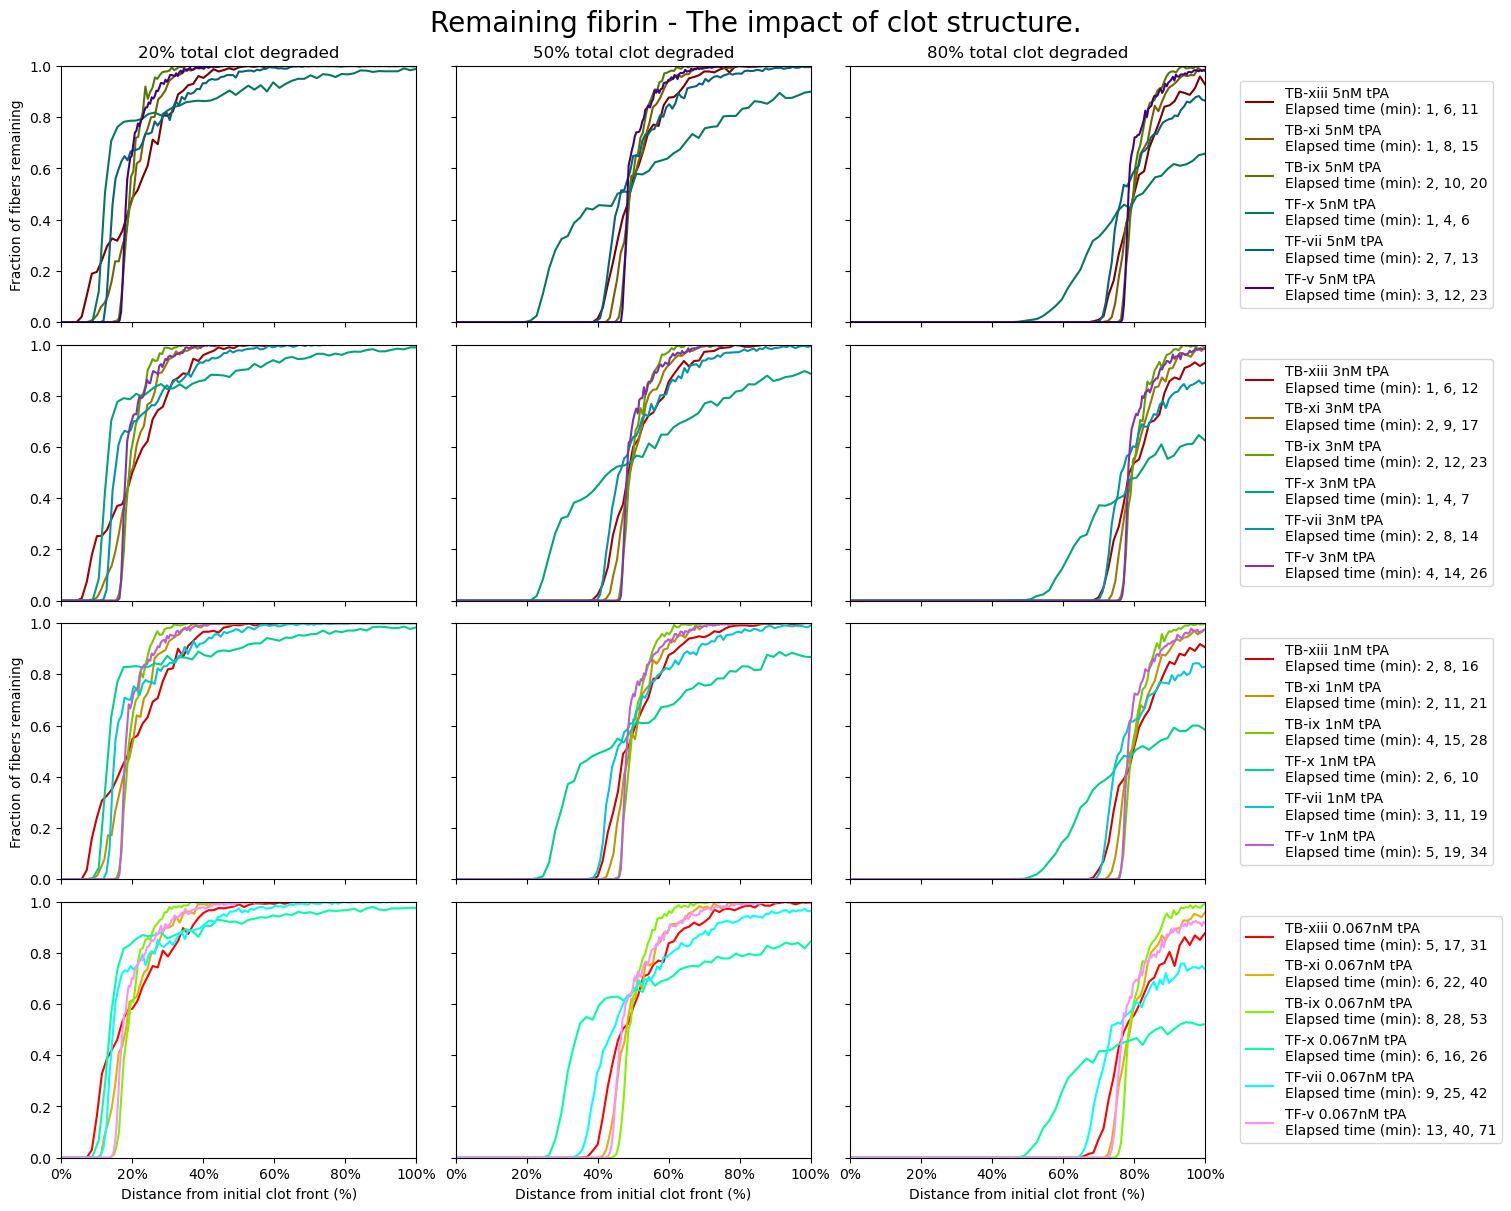

In [24]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
handles = {}
titles = {}
labels = ["20%", "50%", "80%"]
for i, row in enumerate(scenario_grid_T):
    axs[i * 2 % 4, 0].set_ylabel("Fraction of fibers remaining")
    for j in range(len(labels)):
        axs[-1, j].set_xlabel("Distance from initial clot front (%)")
        axs[0, j].set_title(labels[j] + " total clot degraded")
        axs[i, j].set_xlim(0, 1)
        axs[i, j].set_ylim(0, 1)
        axs[-1, j].set_xticks(np.arange(0, 1.1, 0.2), [f"{x:.0%}" for x in np.arange(0, 1.1, 0.2)])

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                np.array(degradation_distance[scenario][j]) / degradation_distance[scenario][j][-1],
                degradation_amount[scenario][j],
                # label=f"{pretty_print_scen(scenario)} ({lysis_time[scenario][j]//60:n} min elapsed)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[scenario] = (
                    f"{pretty_print_scen(scenario)}\nElapsed time (min): {lysis_time[scenario][j]//60:n}"
                )
            else:
                titles[scenario] += f", {lysis_time[scenario][j]//60:n}"
    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )

fig.suptitle(f"Remaining fibrin - The impact of clot structure.", fontsize=20)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"clot degradation by structure by overall degradation.png"), bbox_inches="tight"
)

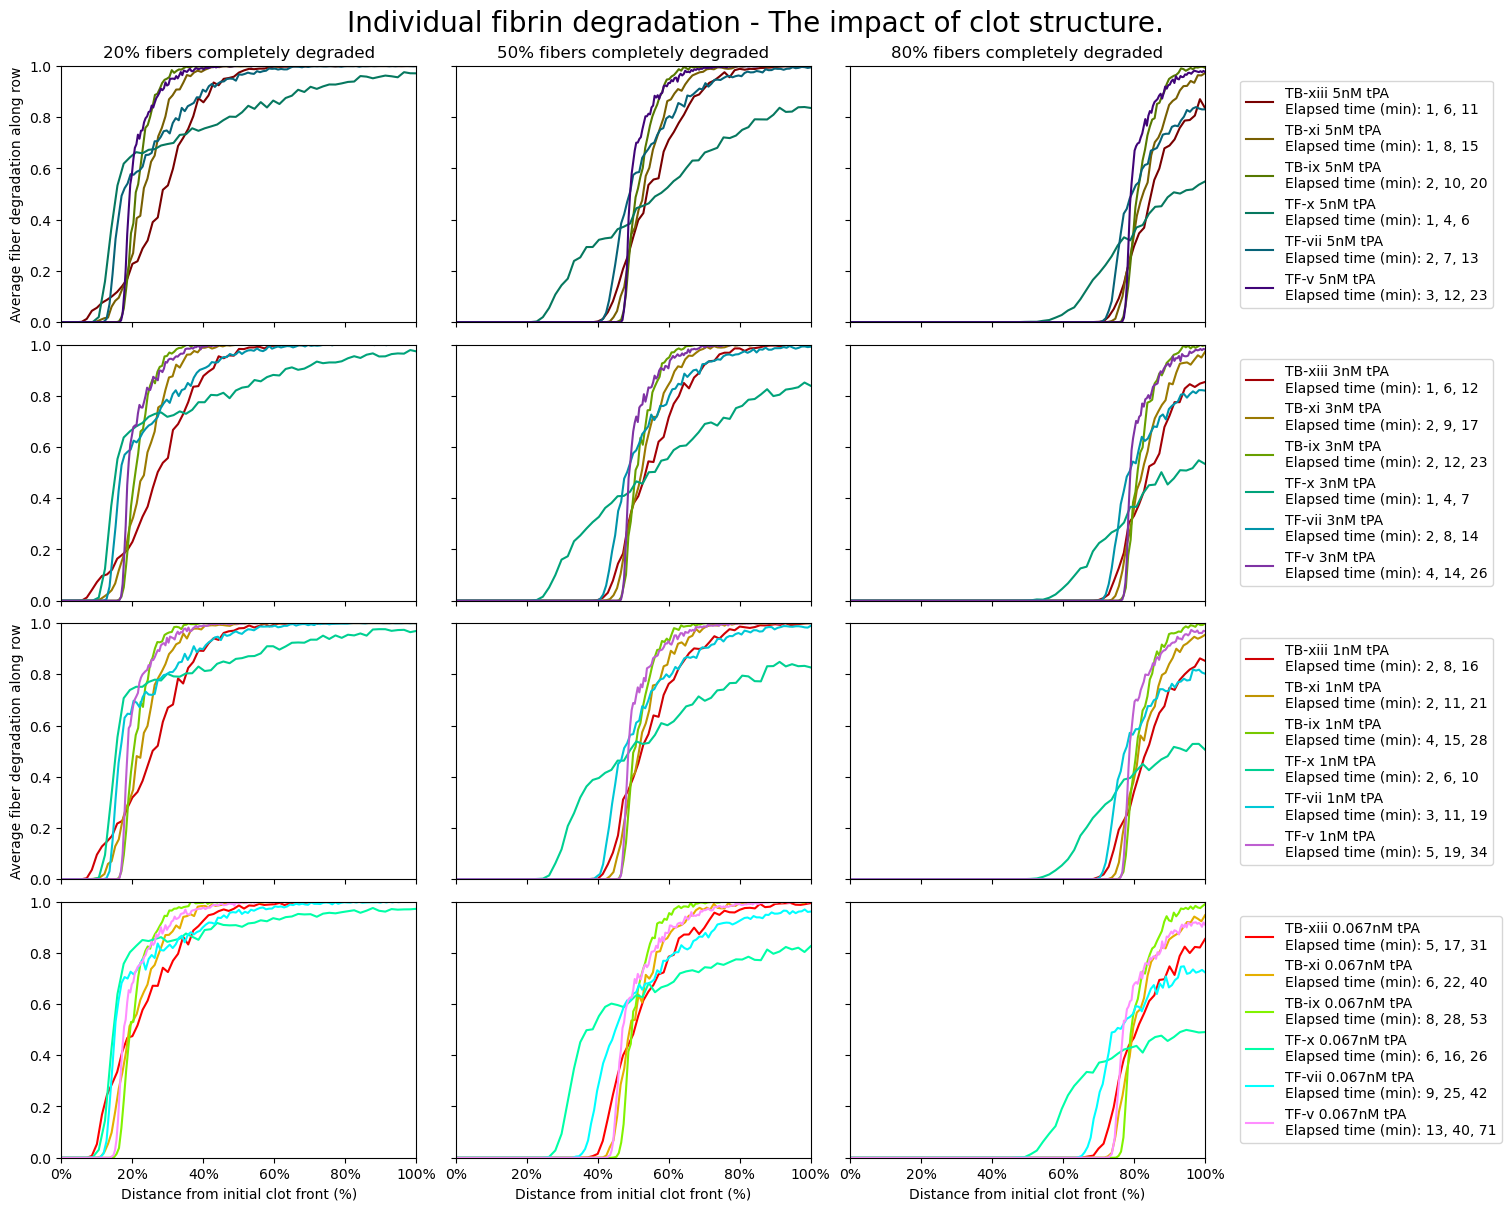

In [25]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
labels = ["20%", "50%", "80%"]
for i, row in enumerate(scenario_grid_T):
    axs[i * 2 % 4, 0].set_ylabel("Average fiber degradation along row")
    for j in range(3):
        axs[-1, j].set_xlabel("Distance from initial clot front (%)")
        axs[0, j].set_title(labels[j] + " fibers completely degraded")
        axs[i, j].set_xlim(0, 1)
        axs[i, j].set_ylim(0, 1)
        axs[-1, j].set_xticks(np.arange(0, 1.1, 0.2), [f"{x:.0%}" for x in np.arange(0, 1.1, 0.2)])

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                np.array(degradation_distance[scenario][j]) / degradation_distance[scenario][j][-1],
                f_deg_amount[scenario][j],
                # label=f"{pretty_print_scen(scenario)} ({lysis_time[scenario][j]//60:n} min elapsed)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[scenario] = (
                    f"{pretty_print_scen(scenario)}\nElapsed time (min): {lysis_time[scenario][j]//60:n}"
                )
            else:
                titles[scenario] += f", {lysis_time[scenario][j]//60:n}"
    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )
fig.suptitle(f"Individual fibrin degradation - The impact of clot structure.", fontsize=20)
e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation by structure by overall degradation.png"), bbox_inches="tight"
)

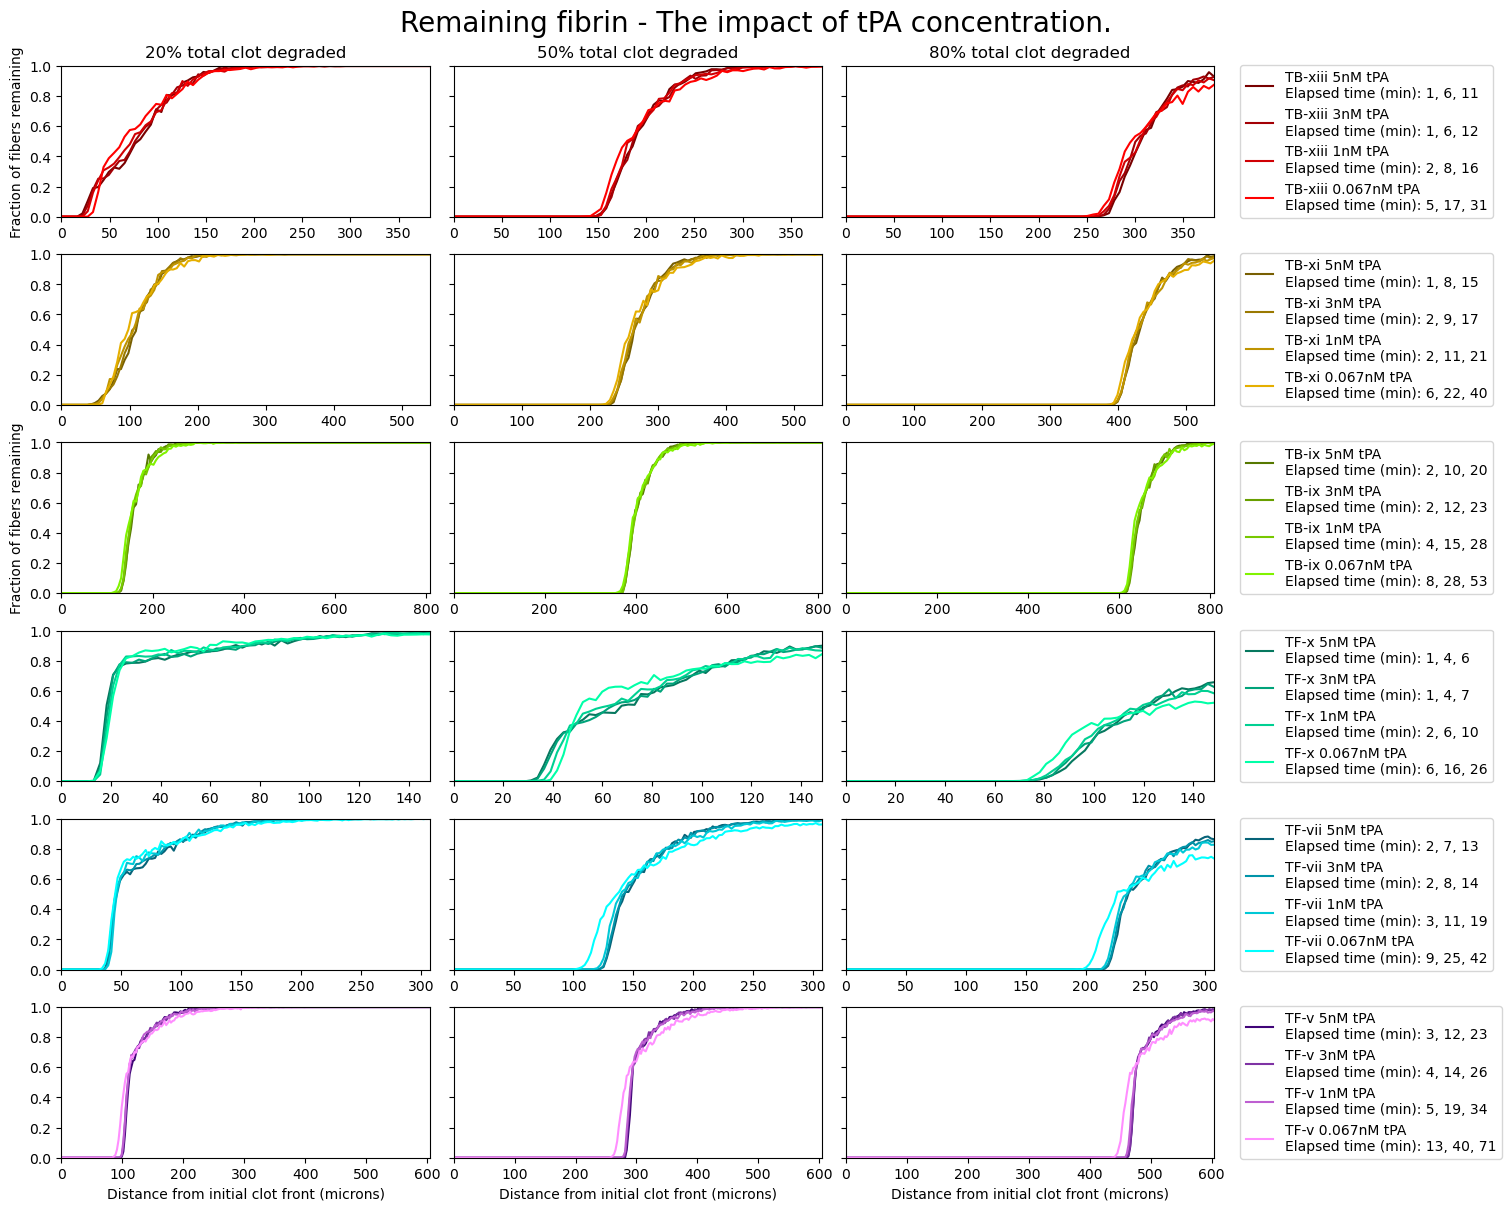

In [26]:
fig, axs = plt.subplots(
    nrows=6,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
labels = ["20%", "50%", "80%"]
for i, row in enumerate(scenario_grid):
    axs[i * 2 % 4, 0].set_ylabel("Fraction of fibers remaining")
    for j in range(3):
        axs[-1, j].set_xlabel("Distance from initial clot front (microns)")
        axs[0, j].set_title(labels[j] + " total clot degraded")
        axs[i, j].set_ylim(0, 1)
        # axs[i, j].set_xticks(degradation_distance[scenario][j], degradation_distance[scenario][j][::-1])

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                degradation_amount[scenario][j],
                label=f"{pretty_print_scen(scenario)} ({lysis_time[scenario][j]//60:n} min elapsed)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[scenario] = (
                    f"{pretty_print_scen(scenario)}\nElapsed time (min): {lysis_time[scenario][j]//60:n}"
                )
            else:
                titles[scenario] += f", {lysis_time[scenario][j]//60:n}"
        axs[i, j].set_xlim(0, degradation_distance[scenario][j][-1])
    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )

fig.suptitle(f"Remaining fibrin - The impact of tPA concentration.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"clot degradation by tPA concentration by overall degradation.png"),
    bbox_inches="tight",
)

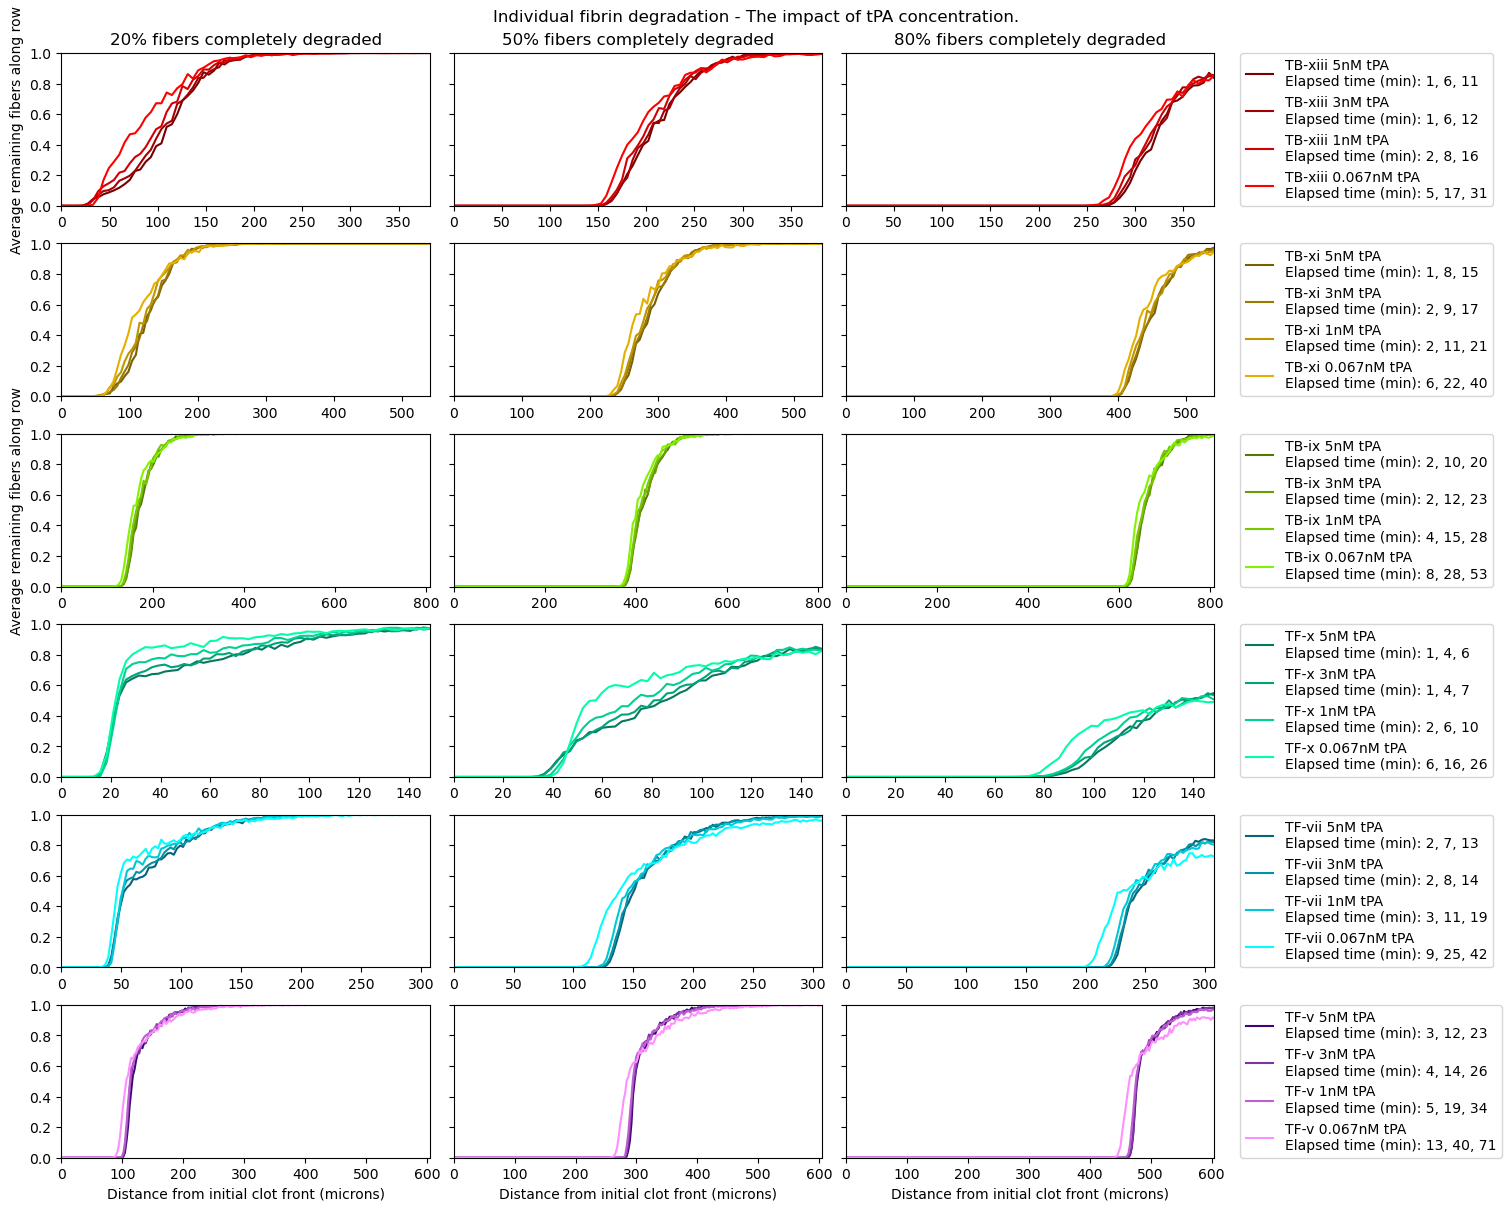

In [29]:
fig, axs = plt.subplots(
    nrows=6,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
labels = ["20%", "50%", "80%"]
for i, row in enumerate(scenario_grid):
    axs[i * 2 % 4, 0].set_ylabel("Average remaining fibers along row")
    for j in range(3):
        axs[-1, j].set_xlabel("Distance from initial clot front (microns)")
        axs[0, j].set_title(labels[j] + " fibers completely degraded")
        axs[i, j].set_ylim(0, 1)

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                f_deg_amount[scenario][j],
                label=f"{pretty_print_scen(scenario)} ({lysis_time[scenario][j]//60:n} min elapsed)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[scenario] = (
                    f"{pretty_print_scen(scenario)}\nElapsed time (min): {lysis_time[scenario][j]//60:n}"
                )
            else:
                titles[scenario] += f", {lysis_time[scenario][j]//60:n}"
        axs[i, j].set_xlim(0, degradation_distance[scenario][j][-1])
    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )

fig.suptitle(f"Individual fibrin degradation - The impact of tPA concentration.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"fiber degradation by tPA concentration by overall degradation.png"),
    bbox_inches="tight",
)

### Degradation t min after tPA insertion

In [19]:
times = [5 * 60, 10 * 60, 15 * 60]
degradation_amount = {}
degradation_distance = {}
total_deg_amount = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    row_deg = find_row_deg_fraction(e, deg, tsave)
    fronts = find_front(e, row_deg)

    frames = [
        [t // (e.macro_params.save_interval * run["data_divisor"]) for t in times]
        for i in range(e.macro_params.total_trials)
    ]

    # Pad arrays in case the simulation is over before the last timestamp
    for sim in range(e.macro_params.total_trials):
        if n_save[sim] < times[-1] // (e.macro_params.save_interval * run["data_divisor"]):
            deg_fraction[sim] = np.pad(
                deg_fraction[sim],
                (
                    0,
                    times[-1] // (e.macro_params.save_interval * run["data_divisor"])
                    - deg_fraction[sim].size
                    + 1,
                ),
                constant_values=1.0,
            )
            row_deg[sim] = np.pad(
                row_deg[sim],
                (
                    (
                        0,
                        times[-1] // (e.macro_params.save_interval * run["data_divisor"])
                        - row_deg[sim].shape[0]
                        + 1,
                    ),
                    (0, 0),
                ),
            )
            fronts[sim] = np.pad(
                fronts[sim],
                (0, times[-1] // (e.macro_params.save_interval * run["data_divisor"]) - fronts[sim].size + 1),
                constant_values=e.macro_params.fiber_rows - 1,
            )

    total_deg_amount[run["scenario"]] = [
        np.mean([deg_fraction[i][frames[i][j]] for i in range(e.macro_params.total_trials)])
        for j in range(len(times))
    ]

    # lengths = [
    #     np.max(np.stack([fronts[i][frames[i][j]] for i in range(e.macro_params.total_trials)]), axis=0)
    #     for j in range(len(times))
    # ]
    degradation_amount[run["scenario"]] = [
        np.mean(
            np.stack([row_deg[i][frames[i][j],] for i in range(e.macro_params.total_trials)]),
            axis=0,
        )
        for j in range(len(times))
    ]
    degradation_distance[run["scenario"]] = [
        [i * e.macro_params.grid_node_distance for i in range(degradation_amount[run["scenario"]][j].size)]
        for j in range(len(times))
    ]

    # edge_index = get_edge_index(e)
    # x1_f, y1_f, x2_f, y2_f = grid_data(e, edge_index)
    # create_fiber_grid_plot(e, file_code, edge_index, frames, deg, tsave, x1_f, y1_f, x2_f, y2_f, fronts=fronts)

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


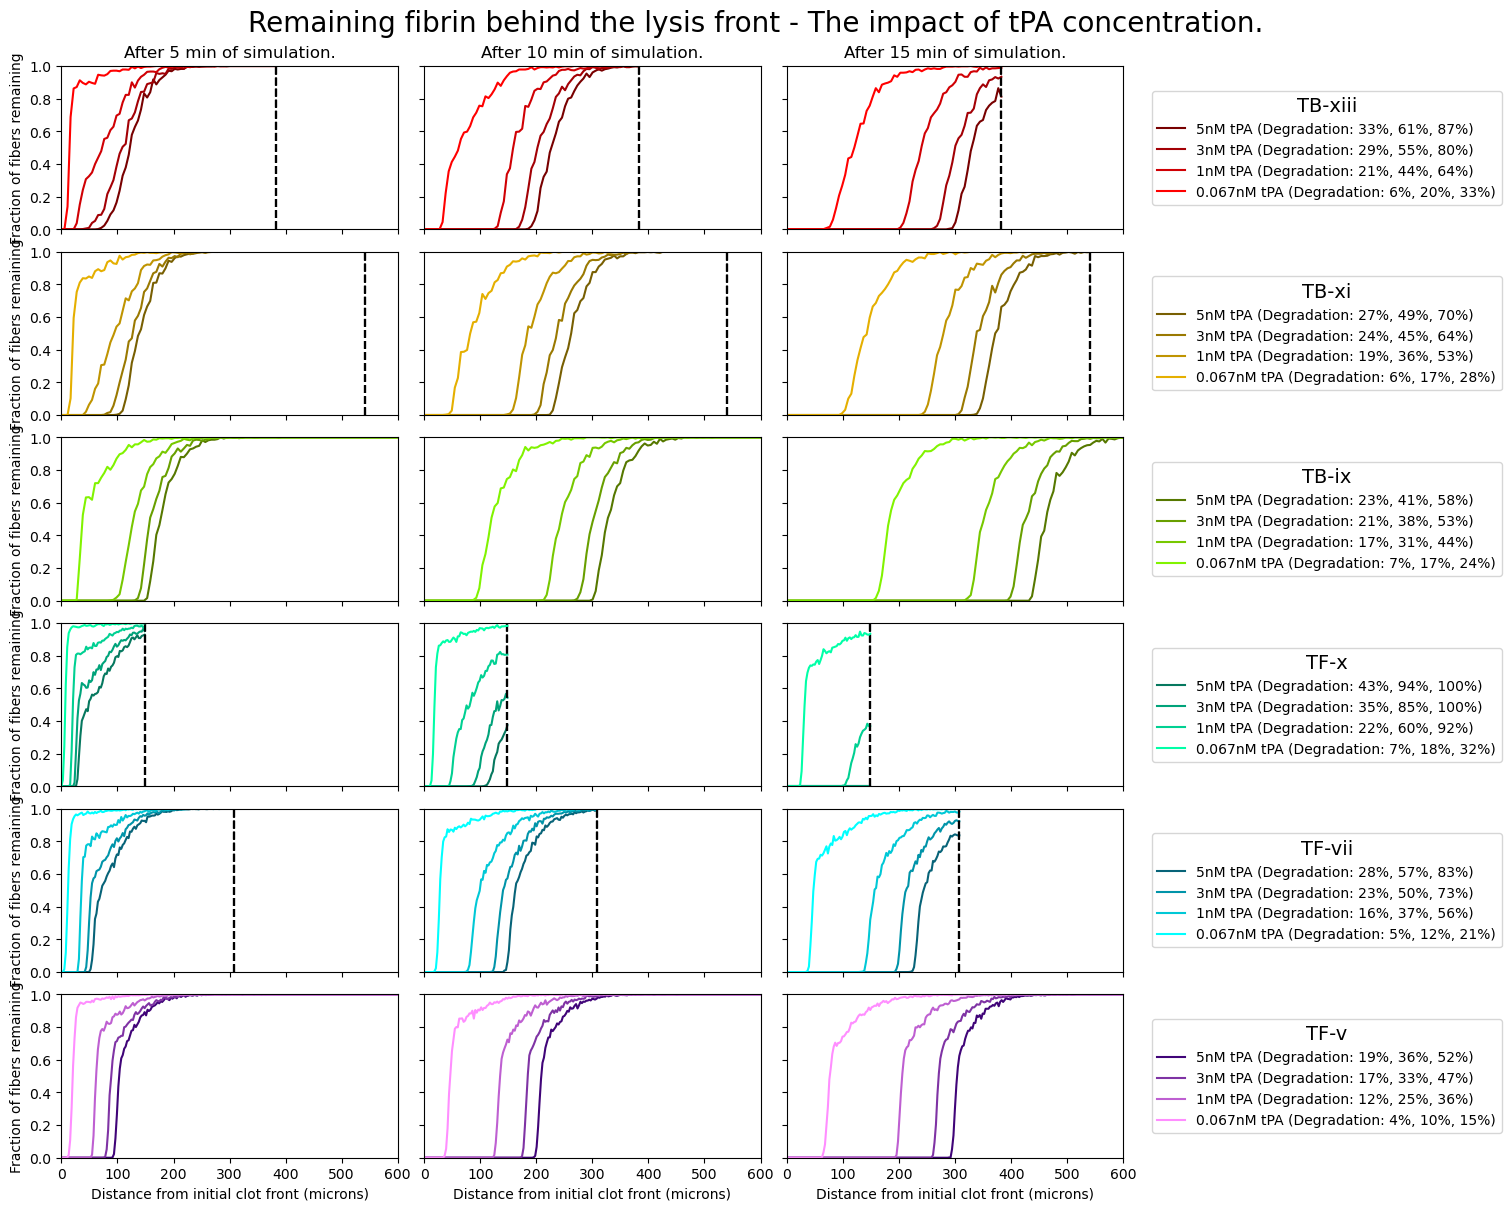

In [38]:
handles = {}
titles = {}
fig, axs = plt.subplots(
    nrows=6,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
for i, row in enumerate(scenario_grid):
    axs[i, 0].set_ylabel("Fraction of fibers remaining")
    for k, scenario in enumerate(row):
        for j in range(len(times)):
            axs[-1, j].set_xlabel("Distance from initial clot front (microns)")
            axs[0, j].set_title(f"After {times[j]//60:n} min of simulation.")
            axs[i, j].set_xlim(0, 600)
            # axs[i, j].set_xticks(np.arange(0, 501, 100), np.arange(500, -1, -100))
            axs[i, j].set_ylim(0, 1)

            axs[i, j].vlines(degradation_distance[scenario][j][-1], 0, 1, color="black", linestyles="dashed")
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                degradation_amount[scenario][j],
                # label=f"{pretty_print_scen(scenario)} ({total_deg_amount[scenario][j]:2.0%} degradation)",
                color=colors[scenario],
            )
        handles[scenario] = plot
        titles[scenario] = (
            f"{groupings[k]} (Degradation: "
            + ", ".join(f"{total_deg_amount[scenario][j]:2.0%}" for j in range(len(times)))
            + ")"
        )
    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
        title=row[0].split("__")[0],
        title_fontsize=14,
    )

fig.suptitle(f"Remaining fibrin behind the lysis front - The impact of tPA concentration.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"degradation by tPA concentration by time.png"),
    bbox_inches="tight",
)

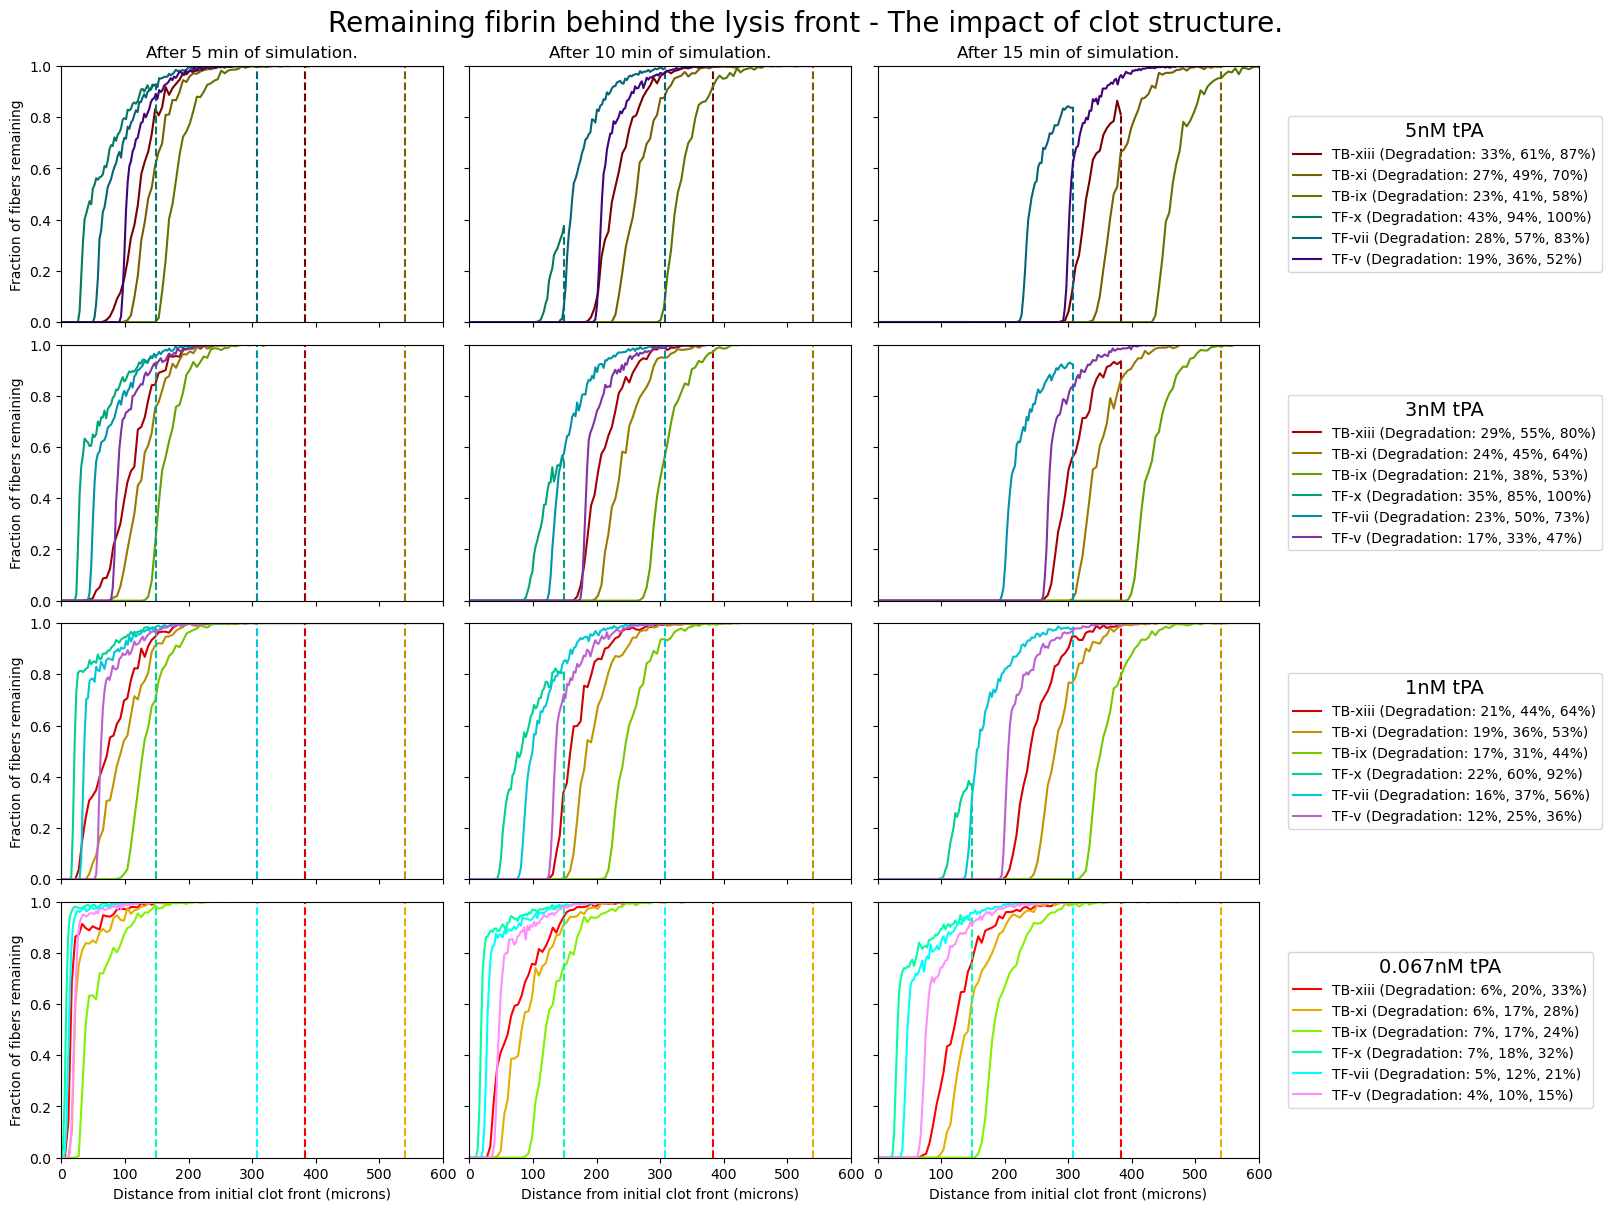

In [35]:
handles = {}
titles = {}
fig, axs = plt.subplots(
    nrows=4,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(16, 12),
    dpi=100,
    constrained_layout=True,
)
for i, row in enumerate(scenario_grid_T):
    axs[i, 0].set_ylabel("Fraction of fibers remaining")
    for k, scenario in enumerate(row):
        for j in range(len(times)):
            axs[-1, j].set_xlabel("Distance from initial clot front (microns)")
            axs[0, j].set_title(f"After {times[j]//60:n} min of simulation.")
            axs[i, j].set_xlim(0, 600)
            axs[i, j].set_ylim(0, 1)

            axs[i, j].vlines(
                degradation_distance[scenario][j][-1],
                0,
                degradation_amount[scenario][j][-1],
                color=colors[scenario],
                linestyles="dashed",
            )
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                degradation_amount[scenario][j],
                label=f"{pretty_print_scen(scenario)} {total_deg_amount[scenario][j]:2.0%} degradation",
                color=colors[scenario],
            )
        handles[scenario] = plot
        titles[scenario] = (
            f"{scenario.split('__')[0]} (Degradation: "
            + ", ".join(f"{total_deg_amount[scenario][j]:2.0%}" for j in range(len(times)))
            + ")"
        )

    axs[i, -1].axis("off")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
        title=groupings[i],
        title_fontsize=14,
    )

fig.suptitle(f"Remaining fibrin behind the lysis front - The impact of clot structure.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, f"degradation by structure by time.png"), bbox_inches="tight")

### Degradation behind front t min after lysis initiation

In [19]:
times = [5 * 60, 10 * 60, 15 * 60]
degradation_amount = {}
degradation_distance = {}
total_deg_amount = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    row_deg = find_row_deg_fraction(e, deg, tsave)
    fronts = find_front(e, row_deg)

    frames = [
        # After lysis lag
        # [marker_frames[i][0] + t // (e.macro_params.save_interval * run["data_divisor"]) for t in times]
        # Without lysis lag
        [t // (e.macro_params.save_interval * run["data_divisor"]) for t in times]
        for i in range(e.macro_params.total_trials)
    ]

    # Pad arrays in case the simulation is over before the last timestamp
    for sim in range(e.macro_params.total_trials):
        if n_save[sim] < marker_frames[sim][0] + times[-1] // (
            e.macro_params.save_interval * run["data_divisor"]
        ):
            deg_fraction[sim] = np.pad(
                deg_fraction[sim],
                (
                    0,
                    marker_frames[sim][0]
                    + times[-1] // (e.macro_params.save_interval * run["data_divisor"])
                    - deg_fraction[sim].size
                    + 1,
                ),
                constant_values=1.0,
            )
            row_deg[sim] = np.pad(
                row_deg[sim],
                (
                    (
                        0,
                        marker_frames[sim][0]
                        + times[-1] // (e.macro_params.save_interval * run["data_divisor"])
                        - row_deg[sim].shape[0]
                        + 1,
                    ),
                    (0, 0),
                ),
            )
            fronts[sim] = np.pad(
                fronts[sim],
                (
                    0,
                    marker_frames[sim][0]
                    + times[-1] // (e.macro_params.save_interval * run["data_divisor"])
                    - fronts[sim].size
                    + 1,
                ),
                constant_values=e.macro_params.fiber_rows - 1,
            )

    # TODO(bpaynter): Add label with degradation total
    total_deg_amount[run["scenario"]] = [
        np.mean([deg_fraction[i][frames[i][j]] for i in range(e.macro_params.total_trials)])
        for j in range(len(times))
    ]

    lengths = [
        np.max(np.stack([fronts[i][frames[i][j]] for i in range(e.macro_params.total_trials)]), axis=0)
        for j in range(len(times))
    ]
    degradation_amount[run["scenario"]] = [
        np.mean(
            np.stack(
                [
                    row_deg[i][
                        frames[i][j],
                        fronts[i][frames[i][j]] : fronts[i][frames[i][j]]
                        + e.macro_params.fiber_rows
                        - 1
                        - lengths[j],
                    ]
                    for i in range(e.macro_params.total_trials)
                ]
            ),
            axis=0,
        )
        for j in range(len(times))
    ]
    degradation_distance[run["scenario"]] = [
        [i * e.macro_params.grid_node_distance for i in range(degradation_amount[run["scenario"]][j].size)]
        for j in range(len(times))
    ]

    # edge_index = get_edge_index(e)
    # x1_f, y1_f, x2_f, y2_f = grid_data(e, edge_index)
    # create_fiber_grid_plot(e, file_code, edge_index, frames, deg, tsave, x1_f, y1_f, x2_f, y2_f, fronts=fronts)

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


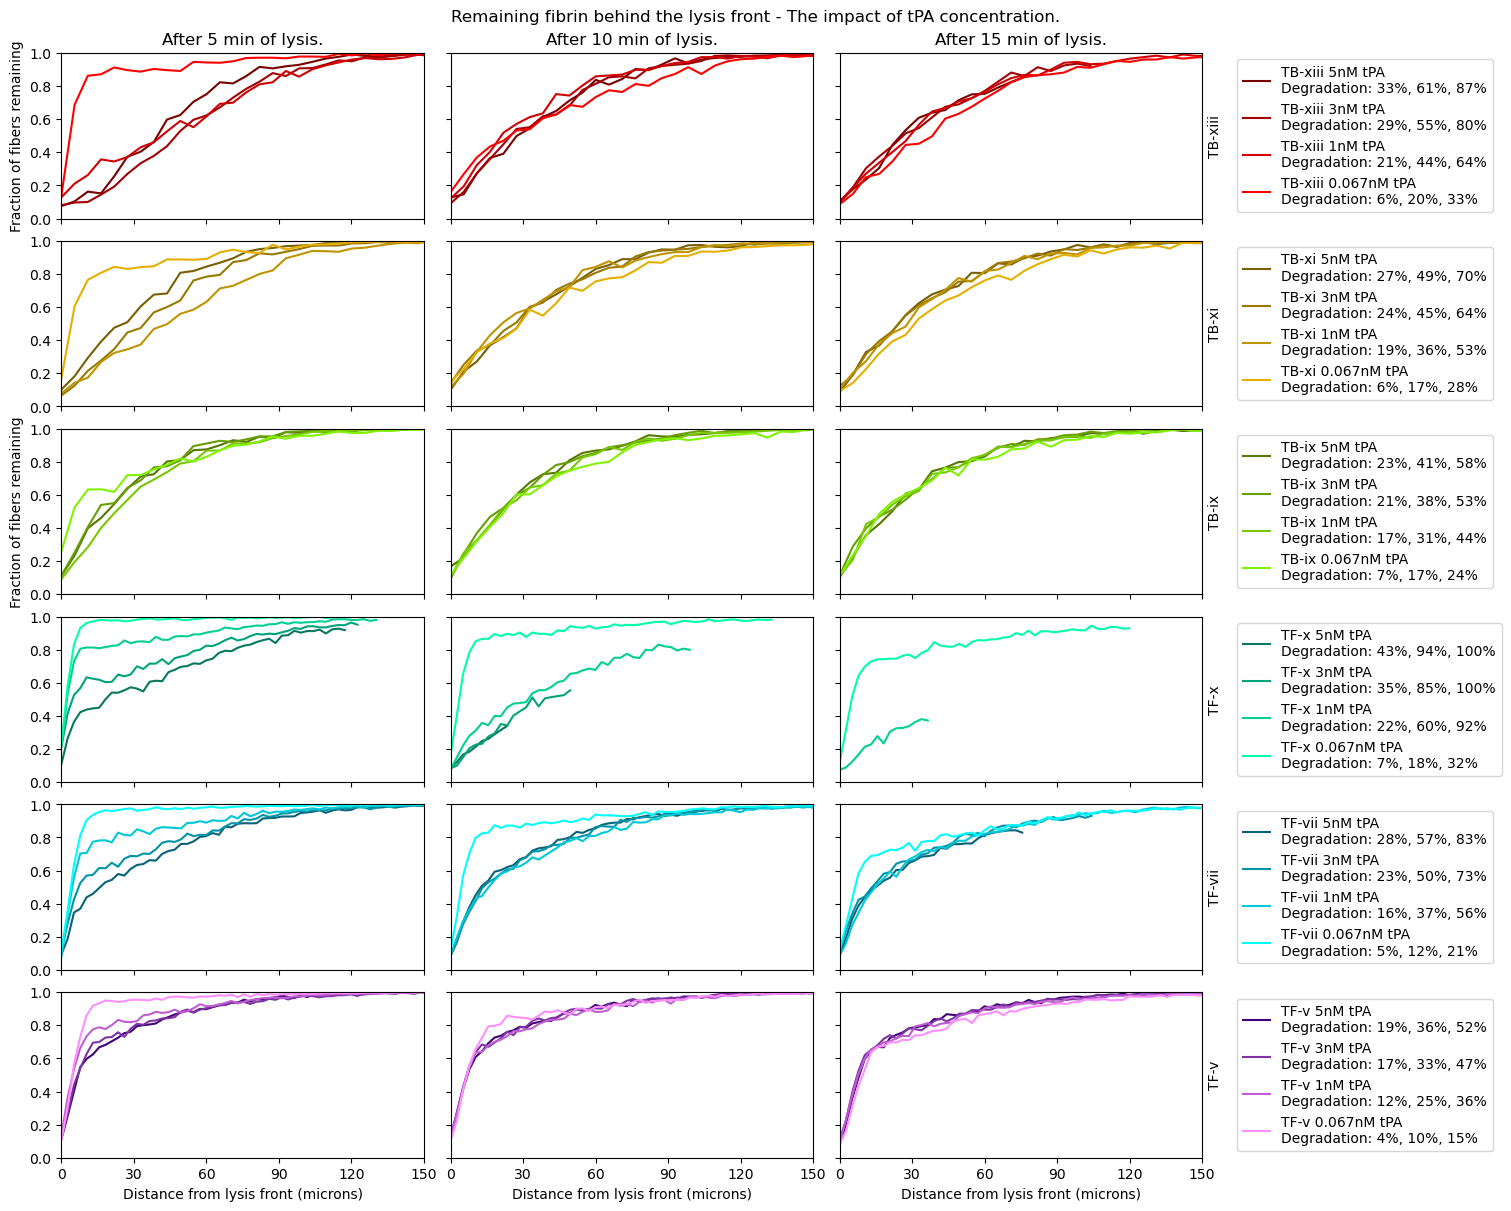

In [20]:
handles = {}
titles = {}
fig, axs = plt.subplots(
    nrows=6,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 12),
    dpi=100,
    constrained_layout=True,
)
for i, row in enumerate(scenario_grid):
    axs[i * 2 % 4, 0].set_ylabel("Fraction of fibers remaining")
    for j in range(3):
        axs[-1, j].set_xlabel("Distance from lysis front (microns)")
        axs[0, j].set_title(f"After {times[j]//60:n} min of lysis.")
        axs[i, j].set_xlim(0, 150)
        axs[i, j].set_xticks(np.arange(0, 151, 30), np.arange(0, 151, 30))
        axs[i, j].set_ylim(0, 1)

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                degradation_amount[scenario][j],
                label=f"{pretty_print_scen(scenario)} ({total_deg_amount[scenario][j]:2.0%} degradation)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[scenario] = (
                    f"{pretty_print_scen(scenario)}\nDegradation: {total_deg_amount[scenario][j]:2.0%}"
                )
            else:
                titles[scenario] += f", {total_deg_amount[scenario][j]:2.0%}"
    axs[i, -1].axis("off")
    axs[i, -2].set_ylabel(row[1].split("__")[0])
    axs[i, -2].yaxis.set_label_position("right")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )

fig.suptitle(f"Remaining fibrin behind the lysis front - The impact of tPA concentration.")

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"degradation behind front by tPA concentration by time.png"), bbox_inches="tight"
)

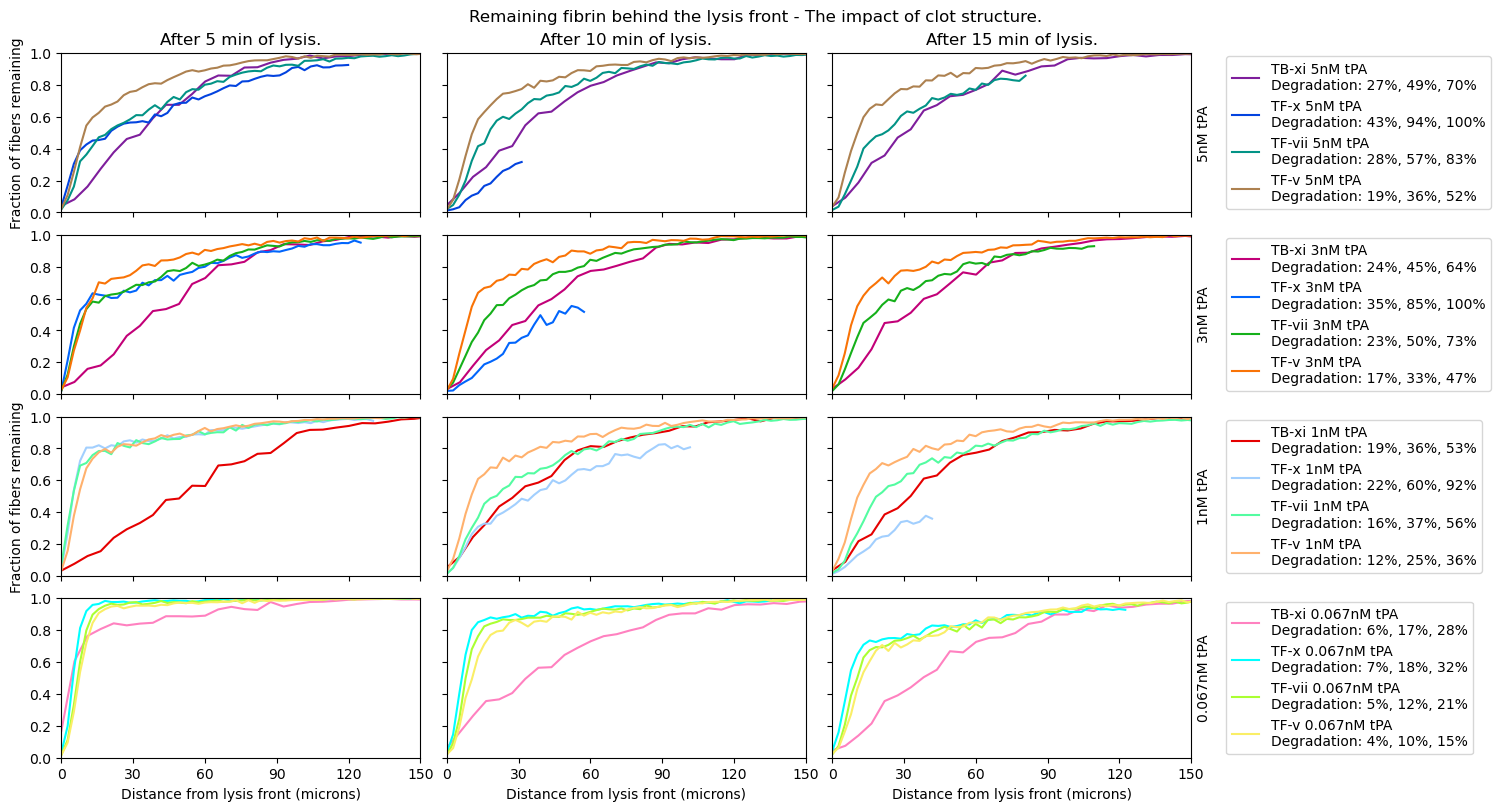

In [35]:
fig, axs = plt.subplots(
    nrows=4,
    ncols=4,
    width_ratios=[1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 8),
    dpi=100,
    constrained_layout=True,
)
for i, row in enumerate(scenario_grid_T):
    axs[i * 2 % 4, 0].set_ylabel("Fraction of fibers remaining")
    for j in range(3):
        axs[-1, j].set_xlabel("Distance from lysis front (microns)")
        axs[0, j].set_title(f"After {times[j]//60:n} min of lysis.")
        axs[i, j].set_xlim(0, 150)
        axs[i, j].set_xticks(np.arange(0, 151, 30), np.arange(0, 151, 30))
        axs[i, j].set_ylim(0, 1)

        for k, scenario in enumerate(row):
            (plot,) = axs[i, j].plot(
                degradation_distance[scenario][j],
                degradation_amount[scenario][j],
                label=f"{pretty_print_scen(scenario)} ({total_deg_amount[scenario][j]:2.0%} degradation)",
                color=colors[scenario],
            )
            if j == 0:
                handles[scenario] = plot
                titles[
                    scenario
                ] = f"{pretty_print_scen(scenario)}\nDegradation: {total_deg_amount[scenario][j]:2.0%}"
            else:
                titles[scenario] += f", {total_deg_amount[scenario][j]:2.0%}"
    axs[i, -1].axis("off")
    axs[i, -2].set_ylabel(groupings[i])
    axs[i, -2].yaxis.set_label_position("right")
    axs[i, -1].legend(
        handles=[handles[scenario] for scenario in row],
        labels=[titles[scenario] for scenario in row],
        # bbox_to_anchor=(1, 0),
        loc="center left",
        ncols=1,
    )


fig.suptitle(f"Remaining fibrin behind the lysis front - The impact of clot structure.")

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"degradation behind front by structure by time.png"), bbox_inches="tight"
)

### Degradation Front vs Time

In [19]:
time = {}
front_distance = {}
# total_deg_amount = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    time[run["scenario"]] = tsave[0]
    t_max = len(tsave[0])
    for i in range(1, e.macro_params.total_trials):
        if len(tsave[i]) > t_max:
            time[run["scenario"]] = tsave[i]
            t_max = len(tsave[i])
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    row_deg = find_row_deg_fraction(e, deg, tsave)
    fronts = find_front(e, row_deg)
    padded_fronts = [
        np.pad(front, (0, t_max - len(front)), constant_values=e.macro_params.fiber_rows - 1)
        for front in fronts
    ]
    # front_distance[run["scenario"]] = (
    #     np.mean(
    #         np.stack(padded_fronts),
    #         axis=0,
    #     )
    #     * e.macro_params.grid_node_distance
    # )
    front_distance[run["scenario"]] = np.stack(padded_fronts) * e.macro_params.grid_node_distance

    # padded_deg_frac = [
    #     np.pad(deg_frac, (0, t_max - len(deg_frac)), constant_values=1)
    #     for deg_frac in deg_fraction
    # ]
    # mean_deg_frac[run["scenario"]] = np.mean(
    #         np.stack(padded_deg_frac),
    #         axis=0,
    #     )

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


In [20]:
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])
    df = pd.DataFrame(
        front_distance[run["scenario"]].T,
        index=pd.Index(time[run["scenario"]], name="Simulation Time Elapsed (sec)"),
        columns=pd.Index(range(e.macro_params.total_trials), name="Simulation  #"),
    )
    df.to_csv(os.path.join(e.os_path, f"front_positions_{file_code[:-4]}.csv"))

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951
2024-04-16-1916 TB-ix__1_582_867
2024-04-16-1917 TB-ix__949_720
2024-04-16-1918 TB-ix__316_573
2024-04-16-1919 TB-ix__21_105
2024-04-16-1920 TB-xiii__1_582_867
2024-04-16-1921 TB-xiii__949_720
2024-04-16-1922 TB-xiii__316_573
2024-04-16-1923 TB-xiii__21_105


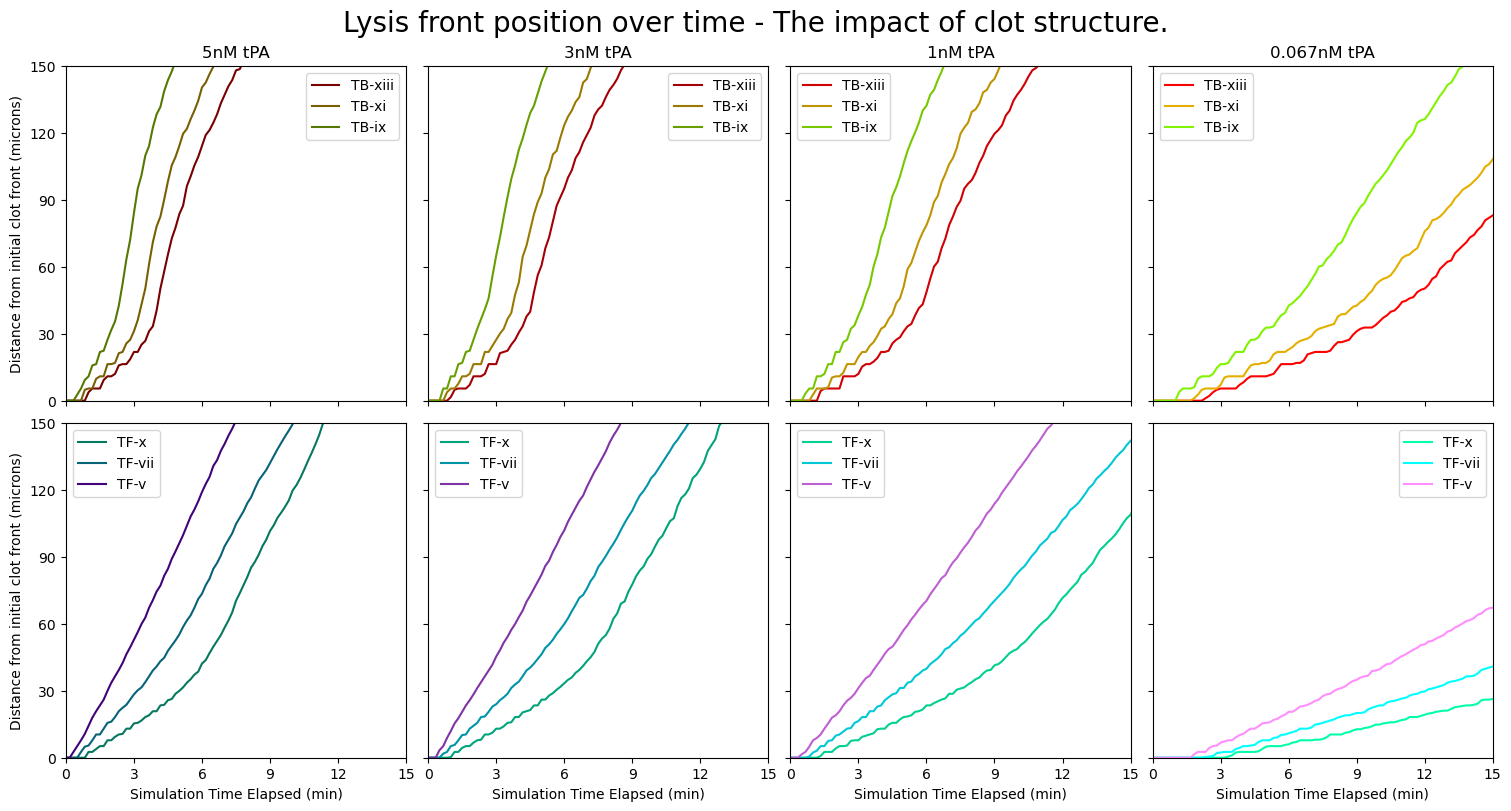

In [31]:
handles = {}
titles = {}
fig, axs = plt.subplots(
    nrows=2,
    ncols=4,
    # width_ratios=[1, 1, 1, 1, 0.7],
    sharex=True,
    sharey=True,
    figsize=(15, 8),
    dpi=100,
    constrained_layout=True,
)
mod = len(scenario_grid) // 2
for i, row in enumerate(scenario_grid_T):
    axs[0, i].set_title(groupings[i])
    for j, scenario in enumerate(row):
        (plot,) = axs[j // mod, i].plot(
            time[scenario] / 60,
            front_distance[scenario].mean(axis=0),
            label=f"{pretty_print_scen(scenario).split(' ')[0]}",
            color=colors[scenario],
        )
        axs[j // mod, i].legend()  # loc="upper left")
        axs[j // mod, 0].set_ylabel("Distance from initial clot front (microns)")
    axs[-1, i].set_xlabel("Simulation Time Elapsed (min)")
    axs[0, i].set_ylim(0, 150)
    axs[0, i].set_yticks(np.arange(0, 151, 30), np.arange(0, 151, 30))
    axs[0, i].set_xlim(0, 15)
    axs[0, i].set_xticks(np.arange(0, 16, 3), np.arange(0, 16, 3))

fig.suptitle(f"Lysis front position over time - The impact of clot structure.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, f"front position by structure vs time.png"), bbox_inches="tight")

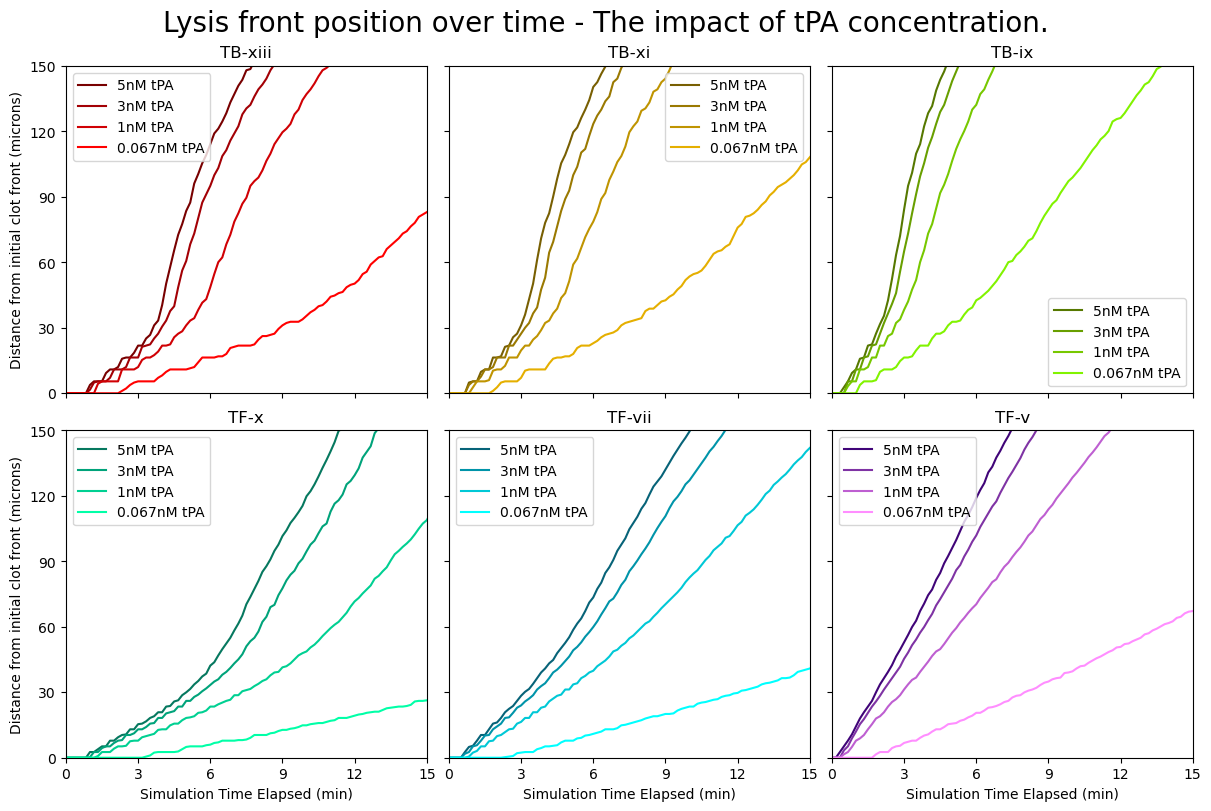

In [30]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    sharex=True,
    sharey=True,
    figsize=(12, 8),
    dpi=100,
    constrained_layout=True,
)
mod = len(scenario_grid) // 2
for i, row in enumerate(scenario_grid):
    axs[i // mod, i % mod].set_title(row[0].split("__")[0])
    for j, scenario in enumerate(row):
        (plot,) = axs[i // mod, i % mod].plot(
            time[scenario] / 60,
            front_distance[scenario].mean(axis=0),
            label=groupings[j],
            color=colors[scenario],
        )
    axs[-1, i % mod].set_xlabel("Simulation Time Elapsed (min)")
    axs[i // mod, i % mod].set_ylim(0, 150)
    axs[i // mod, 0].set_yticks(np.arange(0, 151, 30), np.arange(0, 151, 30))
    axs[i // mod, i % mod].set_xlim(0, 15)
    axs[-1, i % mod].set_xticks(np.arange(0, 16, 3), np.arange(0, 16, 3))
    axs[i // mod, i % mod].legend()
    axs[i // mod, 0].set_ylabel("Distance from initial clot front (microns)")

fig.suptitle(f"Lysis front position over time - The impact of tPA concentration.", fontsize=20)

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, f"front position by tPA concentration vs time.png"), bbox_inches="tight")

## Plot Front Velocity

In [41]:
front_velocity = {}
front_distance = {}
# total_deg_amount = {}
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    exposed_time = calculate_time_row_exposed(e, deg)
    deg_fronts = find_degradation_fronts(e, exposed_time, y_distance, tsave)
    m, sd = mean_front_velocity(e, deg_fronts)
    front_velocity[run["scenario"]] = m

2024-04-16-1900 TB-xi__1_582_867
2024-04-16-1901 TB-xi__949_720
2024-04-16-1902 TB-xi__316_573
2024-04-16-1903 TF-x__746_330
2024-04-16-1904 TF-x__447_798
2024-04-16-1905 TF-x__149_266
2024-04-16-1906 TF-vii__746_330
2024-04-16-1907 TF-vii__447_798
2024-04-16-1908 TF-vii__149_266
2024-04-16-1909 TF-v__746_330
2024-04-16-1910 TF-v__447_798
2024-04-16-1911 TF-v__149_266
2024-04-16-1912 TB-xi__21_105
2024-04-16-1913 TF-x__9_951
2024-04-16-1914 TF-vii__9_951
2024-04-16-1915 TF-v__9_951


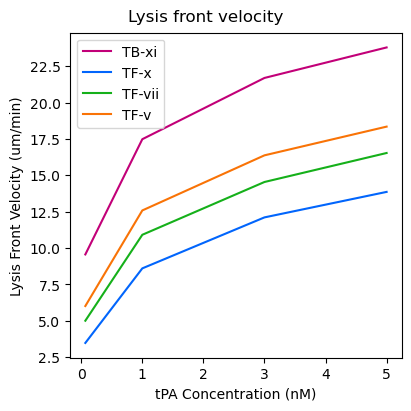

In [43]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    sharex=True,
    sharey=True,
    figsize=(4, 4),
    dpi=100,
    constrained_layout=True,
)
for i, row in enumerate(scenario_grid):
    axs.plot(
        [5, 3, 1, 0.067],
        [front_velocity[scenario] for scenario in row],
        color=colors[row[1]],
        label=row[1].split("__")[0],
    )
axs.legend()
axs.set_xlabel("tPA Concentration (nM)")
axs.set_ylabel("Lysis Front Velocity (um/min)")

fig.suptitle(f"Lysis front velocity")

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(
    os.path.join(e.os_path, f"front velocity by structure vs tPA concentration.png"), bbox_inches="tight"
)

### Print state plots with front

In [ ]:
fig, axs = plt.subplots(
    nrows=3, ncols=4, sharex=False, sharey=False, figsize=(20, 20), dpi=100, constrained_layout=True
)
sim = 0
frac = 0.50
for i, run in enumerate(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    print(run["exp_code"], file_code[1:-4])

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)

    row_deg = find_row_deg_fraction(e, deg, tsave)
    fronts = [np.argmax(sim_row_deg >= frac, axis=1) for sim_row_deg in row_deg]
    edge_index = get_edge_index(e)
    x_f, y_f, x_m, y_m = animation_data(e, edge_index, mol_location)
    #np.delete(marker_frames, -1, axis=-1)
    for j, frame in enumerate(marker_frames[sim, :4]):
        #axs[i, j] = fig.add_axes([0, 0, 1, 1])
        axs[i, j].set_axis_off()
        vmin = 0
        vmax = e.macro_params.cols - 1

        ydiff = e.macro_params.rows - e.macro_params.cols

        axs[i, j].set_xlim(vmin - 0.25, vmax + 0.25)
        axs[i, j].set_ylim(-vmax - ydiff - 0.25, -vmin + 0.25)
        axs[i, j].set_aspect("equal")
        #fig.canvas.draw()
        title = axs[i, j].annotate(
            f"Simulation time elapsed: {str(datetime.timedelta(seconds=tsave[sim][frame])).split('.')[0]}",
            (0, 0),
            zorder=100,
            va="top",
        )
        s = (axs[i, j].get_window_extent().width / (vmax - vmin + 0.5) * 72 / (2 * fig.dpi)) ** 2
        scatt_f = axs[i, j].scatter(
            x_f,
            y_f,
            s=s,
            marker="s",
            linewidths=0,
            c=deg[sim][frame],
            cmap=colormap_f,
            vmin=e.macro_params.time_step,
            vmax=tsave[sim][frame],
        )
        # scatt_m = axs[i, j].scatter(
        #     x_m[sim][frame],
        #     y_m[sim][frame],
        #     s=s / 2.5,
        #     marker="o",
        #     linewidths=0,
        #     c=mol_status[sim][frame],
        #     cmap=colormap_m,
        #     norm=norm_m,
        # )
        front_line = axs[i, j].axhline(y=y_f[(e.macro_params.empty_rows+fronts[sim][frame])*e.macro_params.full_row], color="xkcd:hot pink")

fig.savefig(f"degradation front {frac:.0%}.png", bbox_inches="tight")
pass

## Print tables of data

In [19]:
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Get processing time and print
    time = get_processing_time(e, file_code, mech).mean()
    time = str(datetime.timedelta(seconds=time)).split(".")[0]
    print(run["exp_code"], file_code[1:-4], f" - Mean Simulation Processing Time: {time}")

    # Read data from log files
    total_binds = get_total_binds(e, file_code, mech)
    macro_unbinds, micro_unbinds = get_unbind_amounts(e, file_code, mech)
    normal_unbinds = total_binds - (macro_unbinds + micro_unbinds)
    mol_time_df.loc[
        scen["descriptor"], "Total Binds"
    ] = f"{total_binds.mean():,.0f} \u00B1 {total_binds.std():,.0f}"
    mol_time_df.loc[scen["descriptor"], "Macro Unbinds %"] = f"{(macro_unbinds / total_binds).mean():.3%}"
    mol_time_df.loc[scen["descriptor"], "Micro Unbinds %"] = f"{(micro_unbinds / total_binds).mean():.3%}"

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )

    # Read parameters into a dataframe
    params = e.macro_params
    df = pd.DataFrame([params])
    parameters_df.loc[scen["descriptor"]] = df.loc[0]
    if e.macro_params.total_time == 0:
        parameters_df.loc[scen["descriptor"], "total_time"] = max([i[-1] for i in tsave])
        parameters_df.loc[scen["descriptor"], "total_time_steps"] = max(
            [int(i[-1] // e.macro_params.time_step) for i in tsave]
        )
        parameters_df.loc[scen["descriptor"], "number_of_saves"] = max(n_save)

    binds_df.loc[scen["descriptor"]] = get_total_binds(e, file_code, mech)

    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction, degrade_percent_markers)
    marker_times = find_degradation_marker_times(e, marker_frames, tsave)
    degradation_time_df.loc[run["scenario"]] = marker_times.T.flatten()
    slopes = degradation_rates(e, marker_frames, deg_fraction, tsave)
    slopes_df.loc[run["scenario"]] = slopes.T.flatten()

  0%|          | 0/16 [00:00<?, ?it/s]

2024-04-16-1900 TB-xi__1_582_867  - Mean Simulation Processing Time: 4:09:32
2024-04-16-1901 TB-xi__949_720  - Mean Simulation Processing Time: 2:44:37
2024-04-16-1902 TB-xi__316_573  - Mean Simulation Processing Time: 1:07:57
2024-04-16-1903 TF-x__746_330  - Mean Simulation Processing Time: 4:30:37
2024-04-16-1904 TF-x__447_798  - Mean Simulation Processing Time: 3:05:10
2024-04-16-1905 TF-x__149_266  - Mean Simulation Processing Time: 1:26:44
2024-04-16-1906 TF-vii__746_330  - Mean Simulation Processing Time: 7:24:42
2024-04-16-1907 TF-vii__447_798  - Mean Simulation Processing Time: 5:11:08
2024-04-16-1908 TF-vii__149_266  - Mean Simulation Processing Time: 2:14:51
2024-04-16-1909 TF-v__746_330  - Mean Simulation Processing Time: 11:48:03
2024-04-16-1910 TF-v__447_798  - Mean Simulation Processing Time: 8:10:37
2024-04-16-1911 TF-v__149_266  - Mean Simulation Processing Time: 3:43:18
2024-04-16-1912 TB-xi__21_105  - Mean Simulation Processing Time: 0:07:50
2024-04-16-1913 TF-x__9_95

In [21]:
## Parameters table
units = lysis.util.MacroParameters.units()
rename = {}
for k, v in units.items():
    rename[k] = f"{k} ({v})"
printable_parameters_df = pd.DataFrame(index=parameters_df.index)
for col in parameters_df.columns:
    if not col in cols_to_drop:
        if col in formats:
            printable_parameters_df[col] = parameters_df[col].apply(lambda x: formats[col].format(x))
        else:
            printable_parameters_df[col] = parameters_df[col]
printable_parameters_df = printable_parameters_df.rename(columns=rename, index=pretty_print_scen)
# print(printable_parameters_df.T.to_html())
printable_parameters_df.T

Scenario,TB-xi 5nM tPA,TB-xi 3nM tPA,TB-xi 1nM tPA,TF-x 5nM tPA,TF-x 3nM tPA,TF-x 1nM tPA,TF-vii 5nM tPA,TF-vii 3nM tPA,TF-vii 1nM tPA,TF-v 5nM tPA,TF-v 3nM tPA,TF-v 1nM tPA,TB-xi 0.067nM tPA,TF-x 0.067nM tPA,TF-vii 0.067nM tPA,TF-v 0.067nM tPA
binding_rate ((micromolar*sec)^-1),0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10
pore_size (centimeters),5.34000e-04,5.34000e-04,5.34000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,2.50000e-04,5.34000e-04,2.50000e-04,2.50000e-04,2.50000e-04
diffusion_coeff (cm^2/s),5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07,5.00000e-07
binding_sites (micromolar),248,248,248,306,306,306,204,204,204,136,136,136,248,306,204,136
forced_unbind,0.078,0.078,0.078,0.079,0.079,0.079,0.087,0.087,0.087,0.085,0.085,0.085,0.078,0.079,0.087,0.085
average_bind_time (seconds),27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80,27.80
grid_node_distance (microns),5.463,5.463,5.463,2.605,2.605,2.605,2.605,2.605,2.605,2.605,2.605,2.605,5.463,2.605,2.605,2.605
cols (nodes),19,19,19,39,39,39,39,39,39,39,39,39,19,39,39,39
rows (nodes),184,184,184,385,385,385,385,385,385,385,385,385,184,385,385,385
fiber_rows (nodes),101,101,101,59,59,59,120,120,120,234,234,234,101,59,120,234


In [22]:
## Degradation Rate Table
m = slopes_df.groupby(axis=1, level=0).mean()
s = slopes_df.groupby(axis=1, level=0).std()
slopes_summary = pd.DataFrame(index=slopes_df.index, columns=slopes_df.columns.get_level_values(0).unique())
for i in slopes_summary.index:
    for j in slopes_summary.columns:
        slopes_summary.loc[i, j] = f"{m.loc[i, j]:.6f} \u00B1 {s.loc[i, j]:.6f}"
# print(slopes_summary.to_html())
# print(slopes_summary.to_markdown())
slopes_summary

/tmp/ipykernel_18731/3607622027.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  s = slopes_df.groupby(axis=1, level=0).std()


Degradation Interval,20% to 80%,20% to 50%,50% to 80%
Scenario,,,
TB-xi__1_582_867,0.042633 ± 0.000272,0.045019 ± 0.000768,0.040505 ± 0.000336
TB-xi__949_720,0.039157 ± 0.000367,0.041642 ± 0.000529,0.036967 ± 0.000553
TB-xi__316_573,0.031805 ± 0.000142,0.033818 ± 0.000326,0.030029 ± 0.000327
TF-x__746_330,0.120065 ± 0.001736,0.127551 ± 0.002665,0.113392 ± 0.003142
TF-x__447_798,0.103956 ± 0.001775,0.108028 ± 0.002058,0.100168 ± 0.002567
TF-x__149_266,0.073754 ± 0.000799,0.074636 ± 0.001204,0.072904 ± 0.001486
TF-vii__746_330,0.056200 ± 0.000379,0.061281 ± 0.000722,0.051959 ± 0.000717
TF-vii__447_798,0.049589 ± 0.000444,0.053815 ± 0.000893,0.046028 ± 0.000544
TF-vii__149_266,0.037817 ± 0.000495,0.040146 ± 0.000609,0.035755 ± 0.000548


In [23]:
## Degradation Time Table
m = degradation_time_df.groupby(axis=1, level=0).mean()
s = degradation_time_df.groupby(axis=1, level=0).std()
degradation_time_summary = pd.DataFrame(
    index=degradation_time_df.index, columns=degradation_time_df.columns.get_level_values(0).unique()
)
for i in degradation_time_summary.index:
    for j in degradation_time_summary.columns:
        degradation_time_summary.loc[i, j] = f"{m.loc[i, j]:.2f} \u00B1 {s.loc[i, j]:.2f}"
# print(degradation_time_summary.to_markdown())
# print(degradation_time_summary.to_html())
degradation_time_summary

/tmp/ipykernel_18731/2598874811.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  s = degradation_time_df.groupby(axis=1, level=0).std()


Percent Degraded,5%,20%,50%,80%,100%
Scenario,,,,,
TB-xi__1_582_867,1.95 ± 0.08,3.67 ± 0.00,10.27 ± 0.09,17.65 ± 0.09,24.60 ± 0.25
TB-xi__949_720,2.10 ± 0.09,4.20 ± 0.07,11.35 ± 0.09,19.43 ± 0.12,26.97 ± 0.26
TB-xi__316_573,2.52 ± 0.05,5.40 ± 0.12,14.25 ± 0.09,24.27 ± 0.16,33.35 ± 0.28
TF-x__746_330,1.50 ± 0.00,3.22 ± 0.08,5.58 ± 0.09,8.20 ± 0.11,12.10 ± 0.14
TF-x__447_798,1.67 ± 0.00,3.65 ± 0.05,6.43 ± 0.09,9.38 ± 0.11,13.63 ± 0.17
TF-x__149_266,2.07 ± 0.09,4.83 ± 0.00,8.87 ± 0.11,12.95 ± 0.14,18.33 ± 0.21
TF-vii__746_330,1.50 ± 0.00,3.93 ± 0.09,8.78 ± 0.08,14.58 ± 0.09,19.92 ± 0.09
TF-vii__447_798,1.67 ± 0.00,4.50 ± 0.00,10.03 ± 0.11,16.58 ± 0.12,22.58 ± 0.14
TF-vii__149_266,2.17 ± 0.00,6.10 ± 0.09,13.55 ± 0.11,21.95 ± 0.18,29.77 ± 0.27


In [23]:
print(
    results["Front Velocity (microns/min)"]
    .apply(lambda x: f"{x[0]:,.0f} \u00B1 {x[1]:,.0f}", axis=1)
    .unstack(0)
    .loc[mechanisms["descriptor"], scenarios["descriptor"]]
    #.style.to_latex()
    # .to_html()
)

ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.base.Index'> was passed

### Microscale Measures

In [20]:
in_file_code = "_PLG2_tPA01_{input_code}.dat"
tPA_leaving_times = {}
lysis_times = {}
tPA_forced_unbind = {}
tPA_kinetic_unbind = {}
for run in runs[:12:3]
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = in_file_code.format(input_code=run["scenario"].split("_")[0])

    print(run["exp_code"], file_code)
    tPA_leaving_times[scen["descriptor"]] = (
        np.fromfile(
            os.path.join(e.os_path, f"tPA_time{file_code}"),
        )
        # / 60
    )
    lysis_times[scen["descriptor"]] = (
        np.loadtxt(
            os.path.join(e.os_path, f"lysismat{file_code}"),
            # delimiter="   ",
        )
        # / 60
    )
    # tPA_forced_unbind[scen["descriptor"]] = np.fromfile(
    #     os.path.join(
    #         e.os_path, f"tPAPLiunbd{file_code}"
    #     ),
    #     dtype=np.int32,
    # )
    # tPA_kinetic_unbind[scen["descriptor"]] = np.fromfile(
    #     os.path.join(
    #         e.os_path, f"tPAunbind{file_code}"
    #     ),
    #     dtype=np.int32,
    # )

2024-04-16-1900 _PLG2_tPA01_TB-xi.dat
2024-04-16-1901 _PLG2_tPA01_TB-xi.dat
2024-04-16-1902 _PLG2_tPA01_TB-xi.dat
2024-04-16-1903 _PLG2_tPA01_TF-x.dat
2024-04-16-1904 _PLG2_tPA01_TF-x.dat
2024-04-16-1905 _PLG2_tPA01_TF-x.dat
2024-04-16-1906 _PLG2_tPA01_TF-vii.dat
2024-04-16-1907 _PLG2_tPA01_TF-vii.dat
2024-04-16-1908 _PLG2_tPA01_TF-vii.dat
2024-04-16-1909 _PLG2_tPA01_TF-v.dat
2024-04-16-1910 _PLG2_tPA01_TF-v.dat
2024-04-16-1911 _PLG2_tPA01_TF-v.dat


In [23]:
mean_std_string = "{mean:.3f} \u00B1 {std:.3f}"
microscale_df = pd.DataFrame(columns=scenarios["descriptor"])
microscale_df.loc["Fibers Degraded"] = [
    f"{np.count_nonzero(lysis_times[scen][lysis_times[scen] < 6000]):,}" for scen in scenarios["descriptor"]
]
microscale_df.loc["Mean Lysis Time (min)"] = [
    mean_std_string.format(
        mean=np.mean(lysis_times[scen][lysis_times[scen] < 6000]) / 60,
        std=np.std(lysis_times[scen][lysis_times[scen] < 6000]) / 60,
    )
    for scen in scenarios["descriptor"]
]
microscale_df.loc["Median Lysis Time (min)"] = [
    np.median(lysis_times[scen][lysis_times[scen] < 6000]) / 60 for scen in scenarios["descriptor"]
]
# microscale_df.loc["tPA Unbound"] = [
#     f"{np.count_nonzero(tPA_forced_unbind[scen]) + np.count_nonzero(tPA_kinetic_unbind[scen]):,}"
#     for scen in scenarios["descriptor"]
# ]
microscale_df.loc["Mean tPA Leaving Time (sec)"] = [
    mean_std_string.format(mean=np.mean(tPA_leaving_times[scen]), std=np.std(tPA_leaving_times[scen]))
    for scen in scenarios["descriptor"]
]
microscale_df.loc["Median tPA Leaving Time (sec)"] = [
    np.median(tPA_leaving_times[scen]) for scen in scenarios["descriptor"]
]
# microscale_df.loc["tPA Forced to Unbind"] = [
#     f"{np.count_nonzero(tPA_forced_unbind[scen]) / (np.count_nonzero(tPA_forced_unbind[scen]) + np.count_nonzero(tPA_kinetic_unbind[scen])):.2%}"
#     for scen in scenarios["descriptor"]
# ]
# print(microscale_df.T.style.to_latex())
microscale_df.T

,Fibers Degraded,Mean Lysis Time (min),Median Lysis Time (min),Mean tPA Leaving Time (sec),Median tPA Leaving Time (sec)
TB-xi__1_582_867,"6,420",1.649 ± 0.575,1.619,29.059 ± 35.940,19.420
TB-xi__949_720,"6,420",1.649 ± 0.575,1.619,29.059 ± 35.940,19.420
TB-xi__316_573,"6,420",1.649 ± 0.575,1.619,29.059 ± 35.940,19.420
TF-x__746_330,"6,297",1.419 ± 0.521,1.355,28.238 ± 31.948,19.085
TF-x__447_798,"6,297",1.419 ± 0.521,1.355,28.238 ± 31.948,19.085
TF-x__149_266,"6,297",1.419 ± 0.521,1.355,28.238 ± 31.948,19.085
TF-vii__746_330,"6,481",0.914 ± 0.450,0.797,27.996 ± 31.997,19.053
TF-vii__447_798,"6,481",0.914 ± 0.450,0.797,27.996 ± 31.997,19.053
TF-vii__149_266,"6,481",0.914 ± 0.450,0.797,27.996 ± 31.997,19.053
TF-v__746_330,"6,187",0.659 ± 0.430,0.537,28.483 ± 38.249,18.720


In [28]:
run = runs[-3]
mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
# e = lysis.util.Experiment(
#     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
# )
e.read_file()
y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
file_code = in_file_code.format(input_code=run["scenario"].split("_")[0])
np.median(
    np.fromfile(
        os.path.join(e.os_path, f"tPA_time{file_code}"),
    )
)

18.449480040553958

## Compilation of Figures

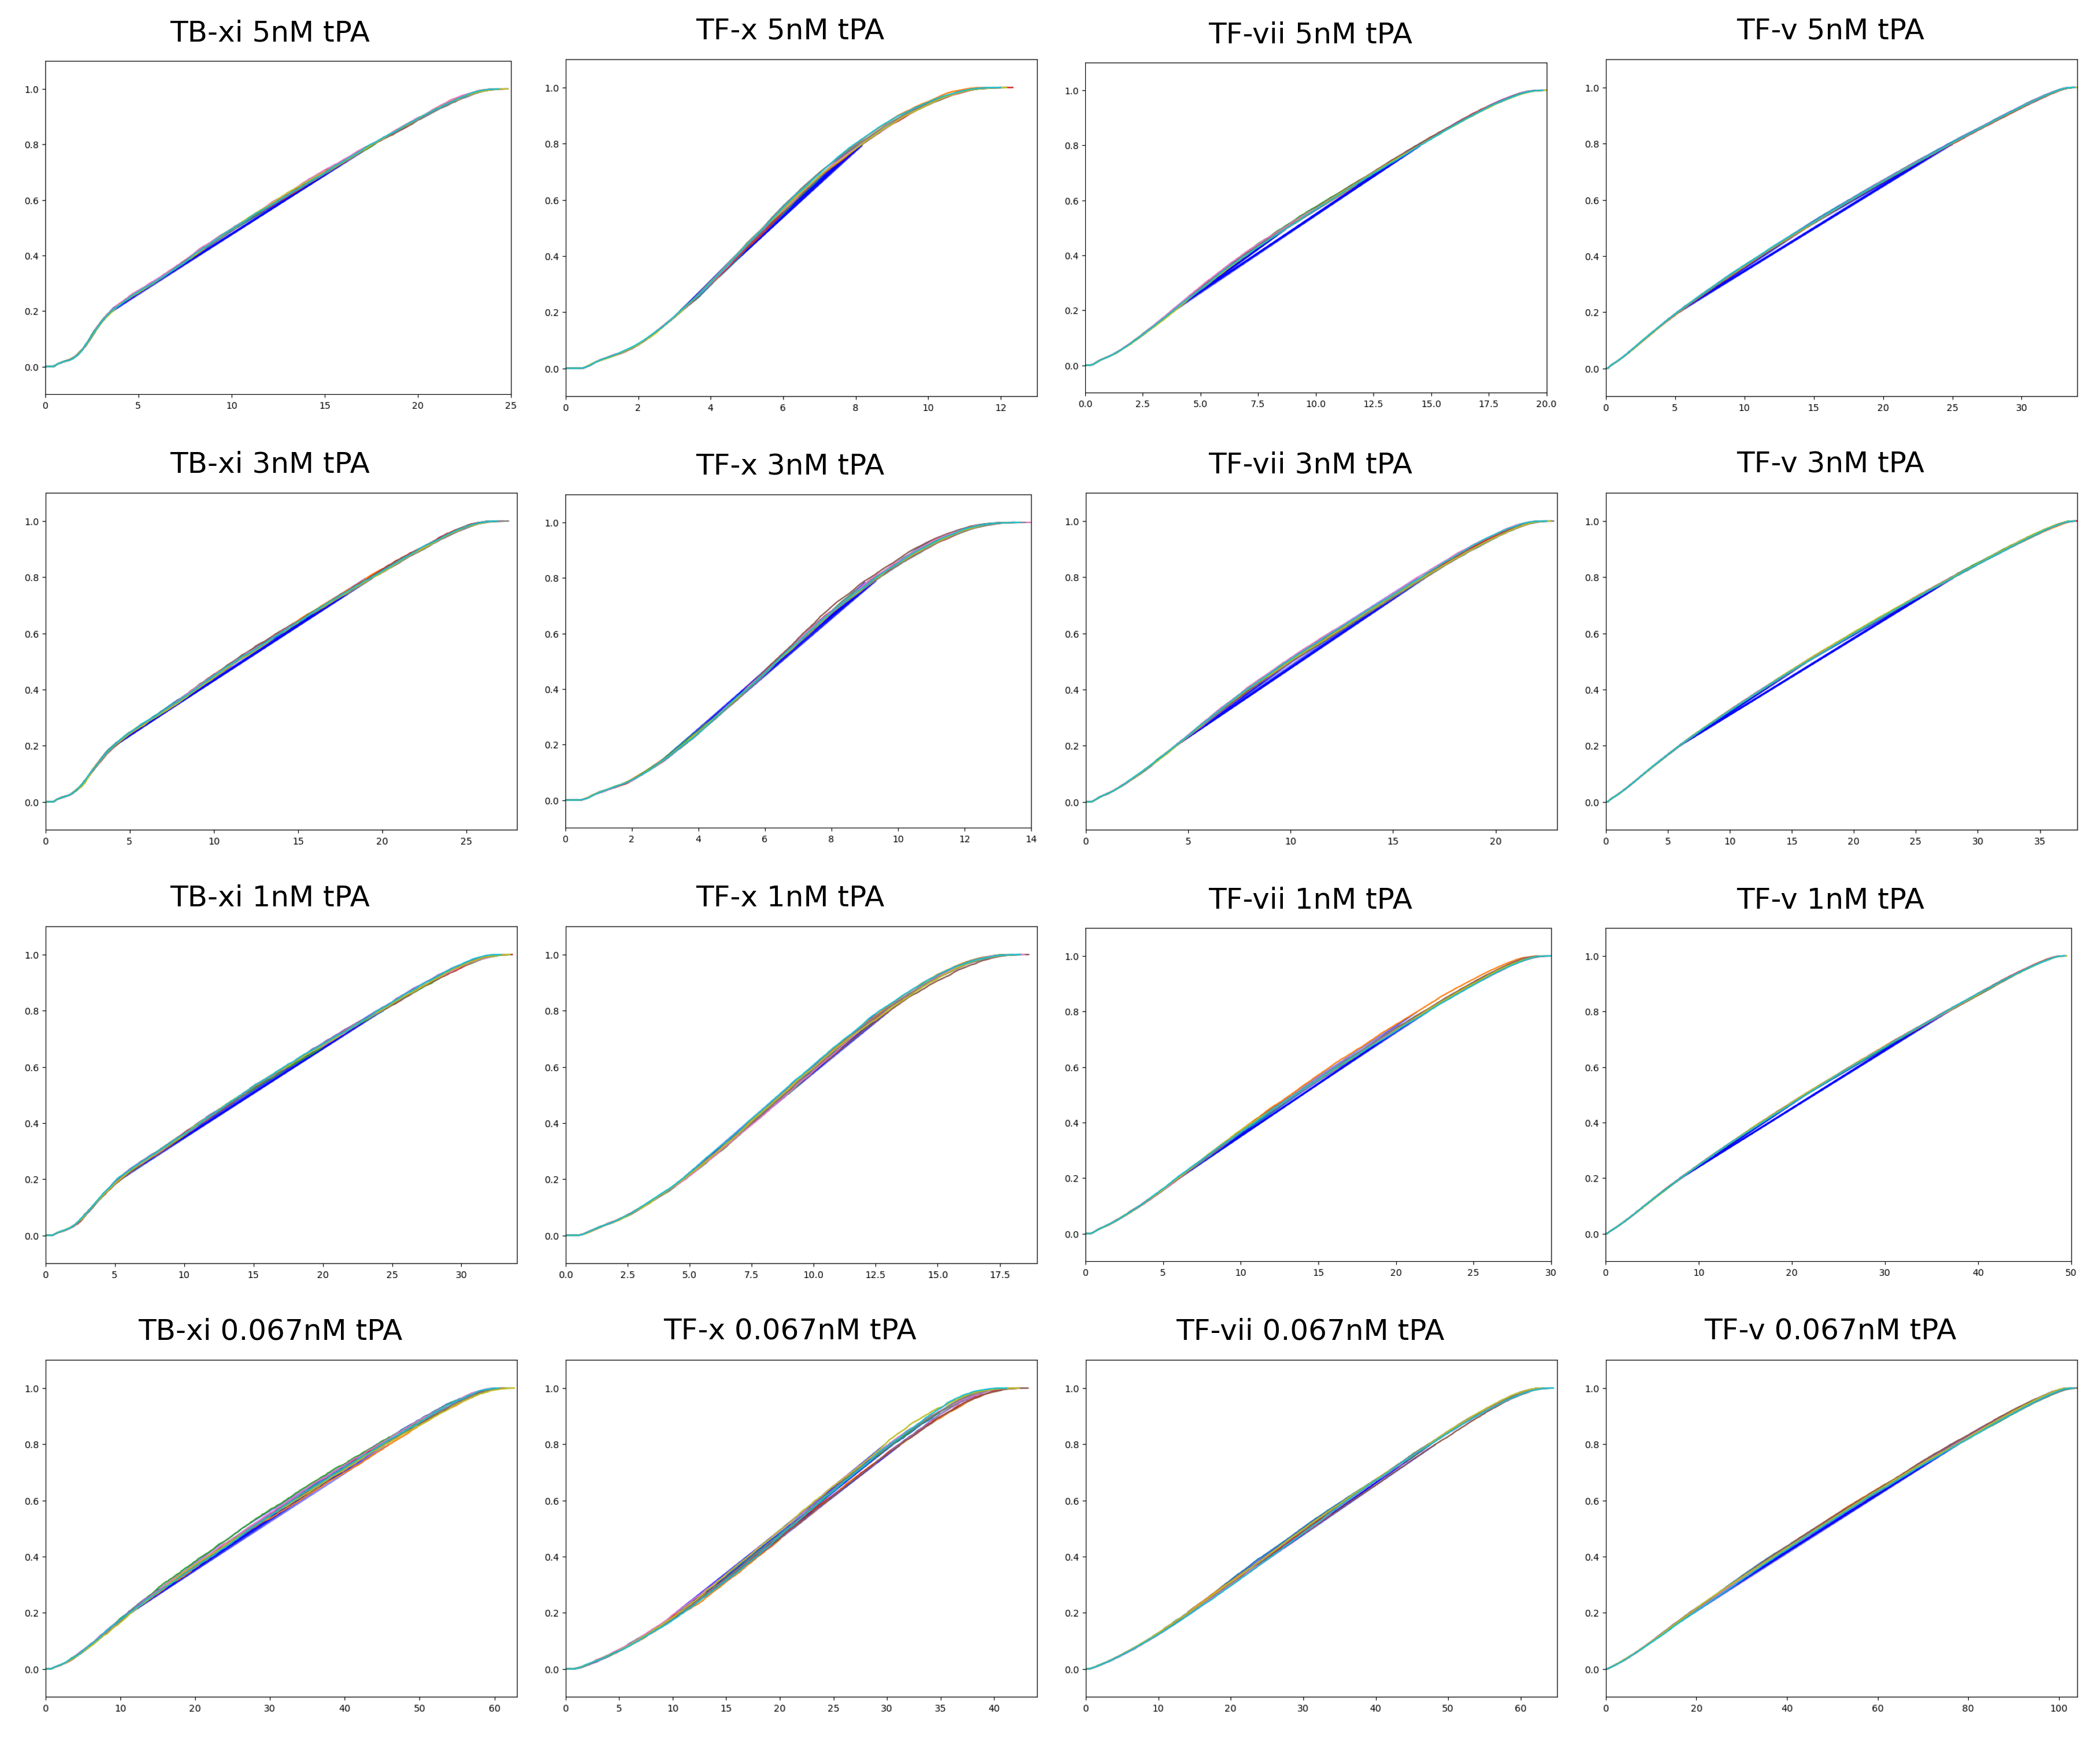

In [33]:
figure_name = "deg_rate"
fig, axs = plt.subplots(
    nrows=4, ncols=4, sharex=False, sharey=True, figsize=(12, 10), dpi=300, constrained_layout=True
)
for i, row in enumerate(scenario_grid_T):
    for j, scenario in enumerate(row):
        run = runs[runs["scenario"] == scenario][0]
        axs[i, j].set_axis_off()
        axs[i, j].set_title(pretty_print_scen(scenario))
        mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
        scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
        e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
        e.read_file()
        file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"
        image = plt.imread(os.path.join(e.os_path, figure_name + file_code[:-4] + ".png"))
        axs[i, j].imshow(image, aspect="equal")

e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, f"{figure_name}__collated.png"), bbox_inches="tight")

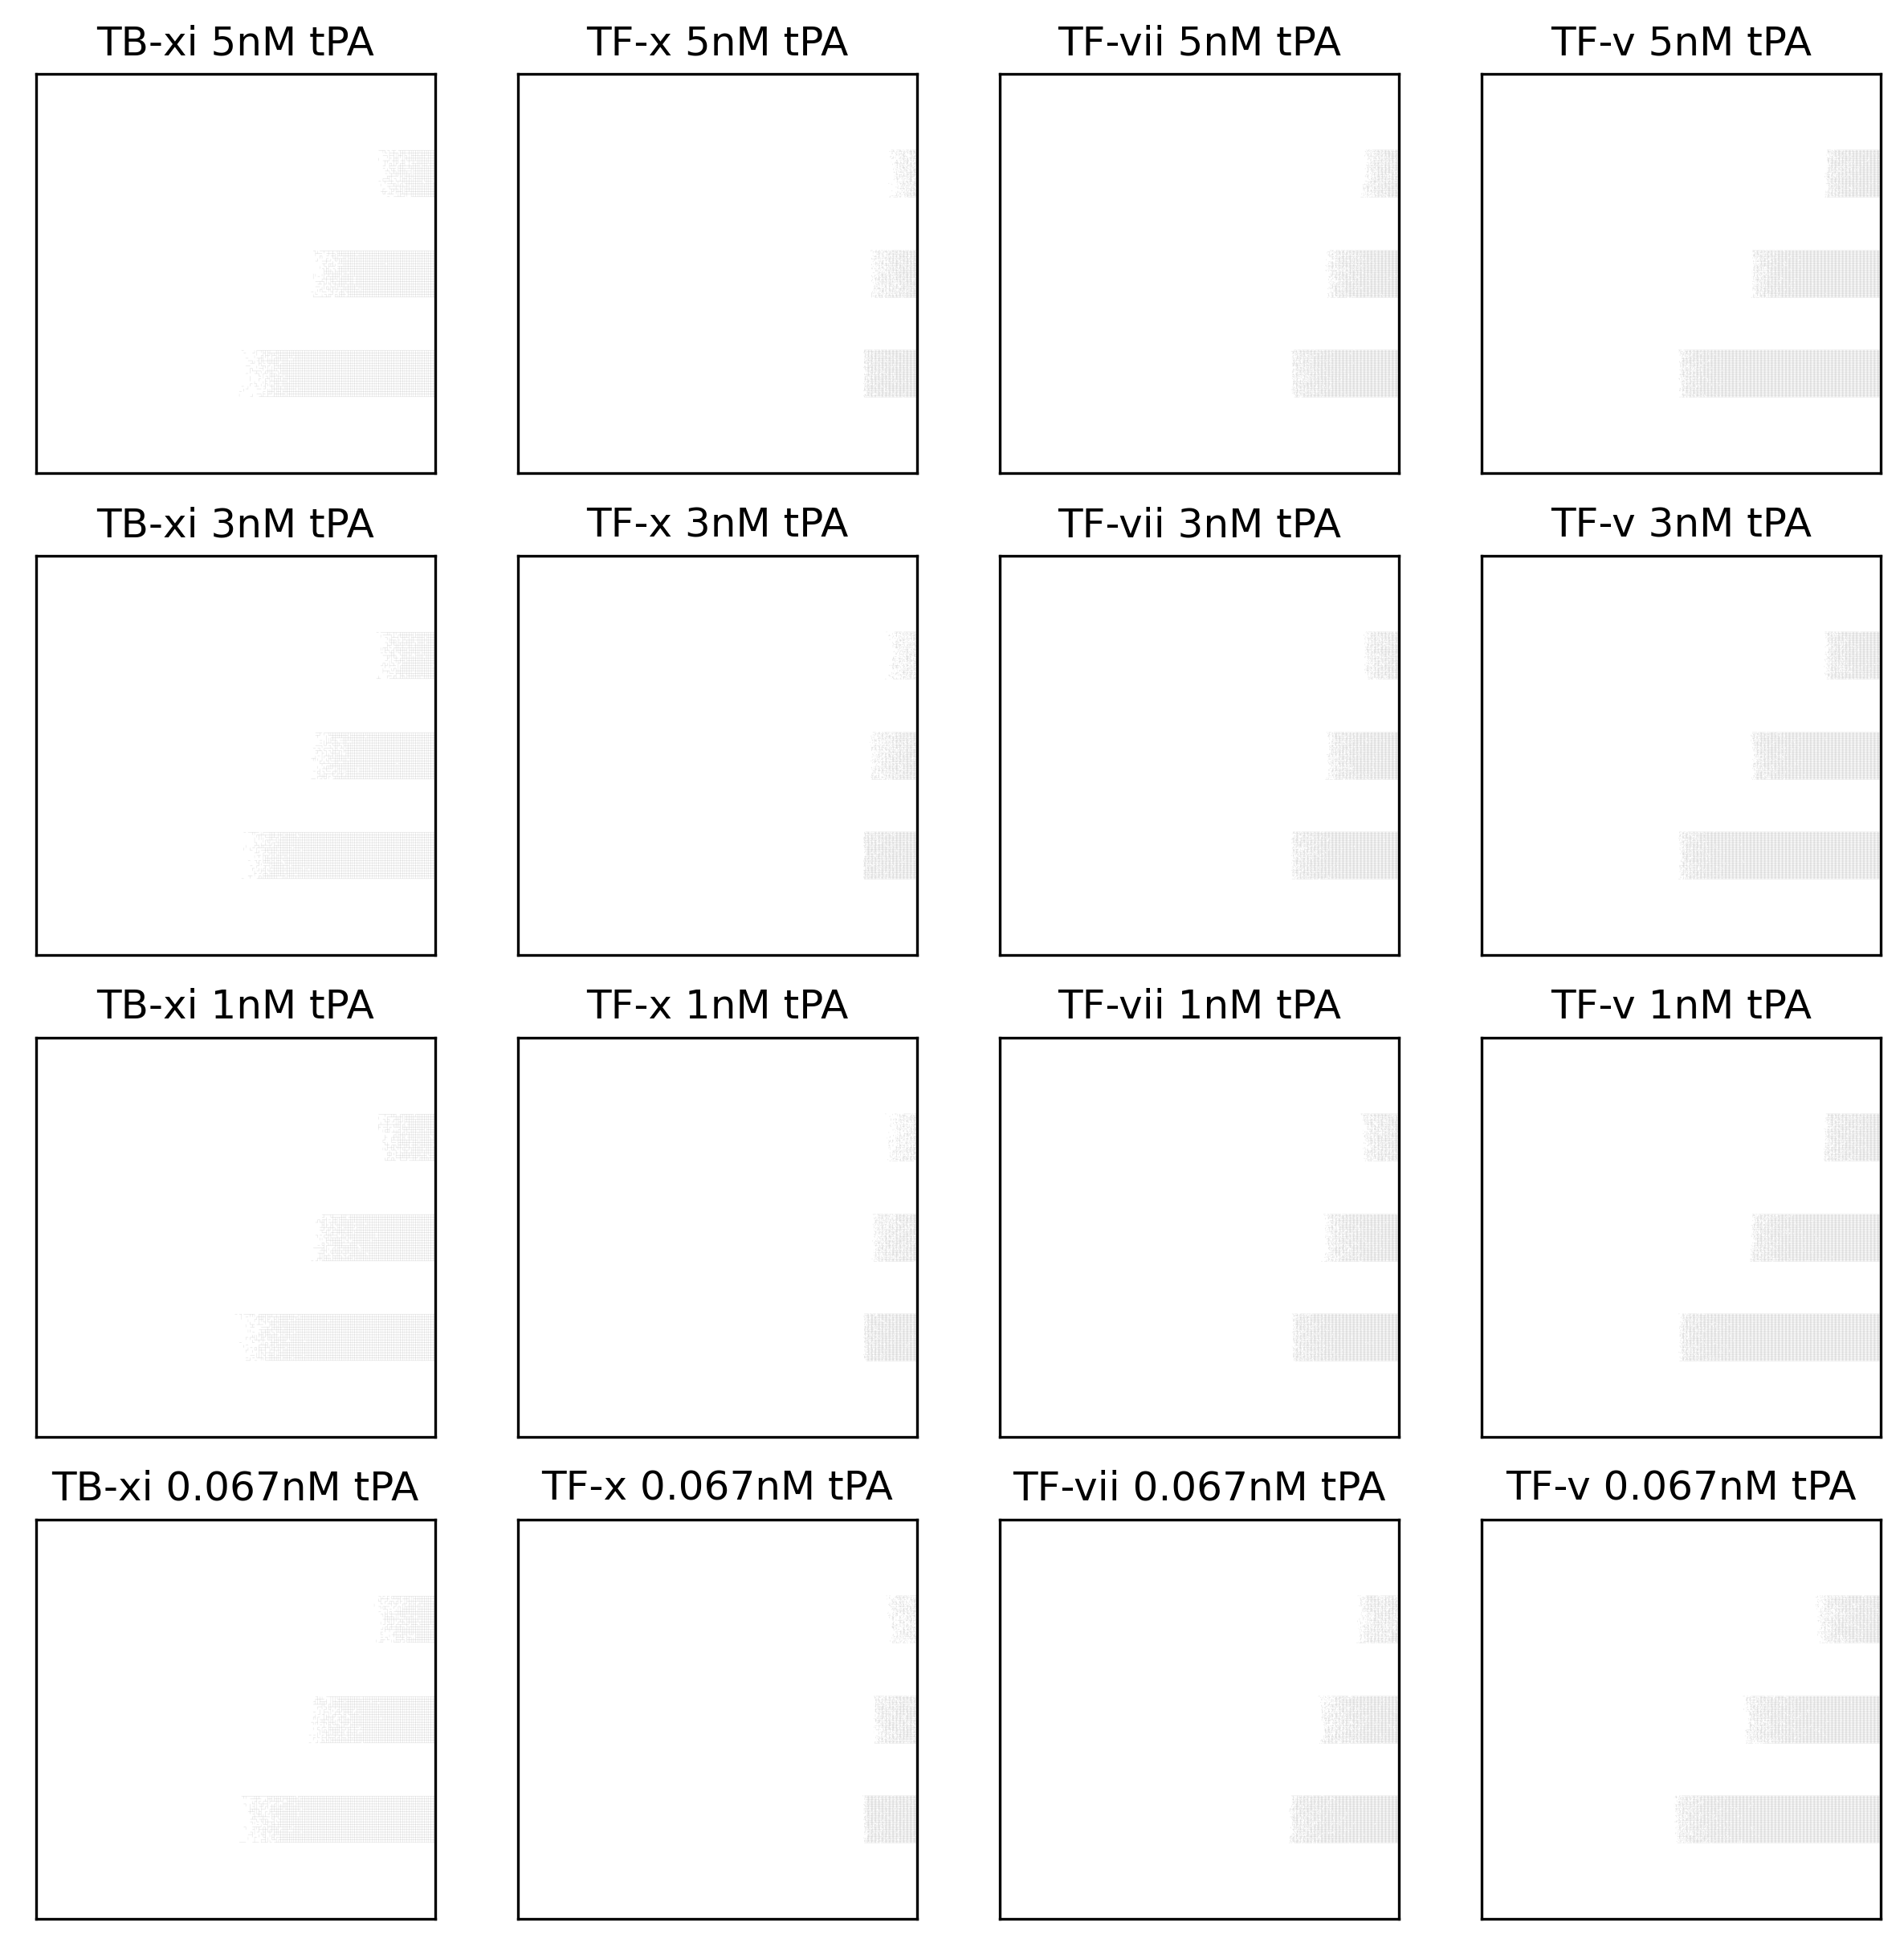

In [38]:
# figure_name = "experiment_state_plot"
figure_name = "fiber_grid_plot"
frames = [0.2, 0.5, 0.8]
width = 0.12
fig, axs = plt.subplots(
    nrows=4, ncols=4, sharex=False, sharey=True, figsize=(8, 8), dpi=300, constrained_layout=True
)
# fig.tight_layout(pad=1.0)
for i, row in enumerate(scenario_grid_T):
    for j, scenario in enumerate(row):
        axs[i, j].set_xlim(0, 1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks(
            []
            # [(idx + 1) / (len(frames) + 1) for idx in range(len(frames))],
            # [f"{frame:.0%}" for frame in frames],
        )
        axs[i, j].set_ylim(0, 1)
        run = runs[runs["scenario"] == scenario][0]
        # axs[i, j].set_axis_off()
        axs[i, j].set_title(pretty_print_scen(scenario))
        mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
        scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
        e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
        e.read_file()
        file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"
        for idx, frame in enumerate(frames):
            image = plt.imread(
                os.path.join(e.os_path, "00", f"{figure_name}{file_code[:-4]}_sim00_{frame:.2f}.png")
            )
            image = np.transpose(image, axes=(1, 0, 2))
            center = (idx + 1) / (len(frames) + 1)
            # axs[i, j].imshow(image, aspect="equal", extent=(center - width / 2, center + width / 2, 0, 1))
            axs[i, j].imshow(image, aspect="equal", extent=(0, 1, center - width / 2, center + width / 2))


e = lysis.util.Experiment(data_root, experiment_code=runs[0]["exp_code"])
e.read_file()
fig.savefig(os.path.join(e.os_path, "00", f"{figure_name}__collated.png"), bbox_inches="tight")

# Experimental post-processing

### Pore size calculations
### Comparison to random pores

In [ ]:
rng1 = np.random.default_rng()

In [ ]:
##################################
## Generate pores with random degradation
##################################
exp = None
random_pore_data = {}
trials = 10_000
percent = 0.8
for run in [r for r in runs if r["scenario"][-3:] == "307"]:
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    total = e.macro_params.total_fibers
    rev_edge_index = get_rev_edge_index(e)
    num_of_lines = 25
    v_step = (e.macro_params.cols - 1) // num_of_lines
    v_lines = range(v_step // 2, e.macro_params.cols - 1, v_step)
    h_step = (e.macro_params.rows - 1) // num_of_lines
    h_lines = range(h_step // 2, e.macro_params.rows - 1, h_step)
    min_time = np.min(n_save)
    pores = []
    for sim in trange(trials):
        pores.append([])
        lines = []
        remove = rng1.choice(np.arange(total), size=math.floor(total * percent), replace=False)
        degraded = np.full(total, False)
        for i in remove:
            degraded[i] = True
        for j in v_lines:
            pores_in_line = []
            current_pore = e.macro_params.grid_node_distance  # e.macro_params.pore_size * 10_000
            # if degraded[rev_edge_index[0, j * 3 + 2]]:
            #     current_pore += exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
            for i in range(1, e.macro_params.rows - 1):
                if degraded[rev_edge_index[i, j * 3 + 2]]:
                    current_pore += e.macro_params.grid_node_distance
                else:
                    pores_in_line.append(current_pore)
                    current_pore = e.macro_params.grid_node_distance  # e.macro_params.pore_size * 10_000
            # if degraded[rev_edge_index[-1, j * 3 + 2]]:
            #     current_pore += exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
            pores_in_line.append(current_pore)
            lines.append(np.array(pores_in_line))
        for i in h_lines:
            pores_in_line = []
            current_pore = e.macro_params.grid_node_distance  # e.macro_params.pore_size * 10_000
            # if degraded[rev_edge_index[i, 0]]:
            #     current_pore += exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
            for j in range(1, e.macro_params.cols - 1):
                if degraded[rev_edge_index[i, j * 3]]:
                    current_pore += e.macro_params.grid_node_distance
                else:
                    pores_in_line.append(current_pore)
                    current_pore = e.macro_params.grid_node_distance  # e.macro_params.pore_size * 10_000
            # if degraded[rev_edge_index[i, -1]]:
            #     current_pore += exp.macro_params.grid_node_distance - exp.macro_params.pore_size * 10_000
            pores_in_line.append(current_pore)
            lines.append(np.array(pores_in_line))
        pores_at_frame = np.empty(0, dtype=float)
        for line in lines:
            pores_at_frame = np.append(pores_at_frame, line)
        pores[sim].append(
            pores_at_frame / e.macro_params.grid_node_distance
        )  # (e.macro_params.pore_size * 10_000))
    random_pore_data[scen["descriptor"]] = [pores[sim][0] for sim in range(trials)]

In [ ]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    sharex=False,
    sharey=True,
    figsize=(12, 6),
    constrained_layout=True,
    # width_ratios=[2, 1, 1, 1, 1],
)
for i, row in enumerate(scenario_grid):
    axs[0].set_ylabel("pore size\n(as a multiple of grid node distance")  # initial pore size)")
    # for j, scenario in enumerate(row):
    #     axs[i, j + 2].boxplot(
    #         [pore_plot_data[scenario][0.8][sim] for sim in range(10)],
    #         # showfliers=False,
    #         whis=[0.01, 0.99],
    #     )
    #     # axs[i].set_xticks(
    #     #     range(1, len(row) + 1),
    #     #     labels=[f"{scenario}" for scenario in row],
    #     # )
    #     axs[i, j + 2].set_title(scenario)
    axs[i].boxplot(
        [np.concatenate(pore_plot_data[scenario][percent]) for scenario in row],
        showfliers=False,
        whis=(1, 99),
    )
    axs[i].set_xticks(
        range(1, len(row) + 1),
        labels=[f"{scenario}" for scenario in row],
        rotation=-45,
    )
    axs[i].set_title(groupings[i])
    axs[i].grid(visible=True, which="major", axis="y")
    # axs[i, 1].boxplot(
    #     random_pore_data[f"{row[0][:5]}307"],
    #     showfliers=False,
    # )
    # axs[i, 1].set_title(f"{row[0][:5]}Control")
axs[-1].boxplot(
    [np.concatenate(random_pore_data[f"{scenario[:5]}307"]) for scenario in scenario_grid[0]],
    showfliers=False,
    whis=(1, 99),
)
axs[-1].set_xticks(
    range(1, len(row) + 1),
    labels=[f"{scenario[:5]}Control" for scenario in scenario_grid[0]],
    rotation=-45,
)
axs[-1].set_title("Random Control")
axs[-1].grid(visible=True, which="major", axis="y")
fig.suptitle(
    f"Distribution of pore sizes at {percent:.0%} degradation.\n(Boxes are Q1 to Q3; Whiskers are 1st percentile to 99th percentile)"
)
pass

In [ ]:
# 10_000 samples
# 80% degraded
for run in runs:
    print(
        run["scenario"],
        scipy.stats.ks_2samp(
            np.concatenate(pore_plot_data[run["scenario"]][0.8]),
            np.concatenate(random_pore_data[f"{run['scenario'][:5]}307"]),
        ),
    )

In [ ]:
# 100 samples
for run in runs:
    print(
        run["scenario"],
        scipy.stats.ks_2samp(
            np.concatenate(pore_plot_data[run["scenario"]][0.8]),
            np.concatenate(random_pore_data[f"{run['scenario'][:5]}307"]),
        ),
    )

In [ ]:
scipy.stats.anderson(np.concatenate(random_pore_data[f"TK-L_307"]), dist="expon")

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=4, sharex=False, sharey=True, figsize=(12, 6), constrained_layout=True)
for i, row in enumerate(scenario_grid_T):
    axs[i].set_yscale("log")
    for j, scenario in enumerate(row):
        combined_sims = np.concatenate(pore_plot_data[scenario][percent])
        hist = np.array([(i, np.count_nonzero(combined_sims == i)) for i in np.unique(combined_sims)])
        axs[i].plot(
            hist.T[0], hist.T[1] * 100 / combined_sims.shape[0], color=colors[scenario], label=scenario
        )
    combined_sims = np.concatenate(random_pore_data[f"{row[0][:5]}307"])
    hist = np.array([(i, np.count_nonzero(combined_sims == i)) for i in np.unique(combined_sims)])
    axs[i].plot(hist.T[0], (hist.T[1]) * 100 / combined_sims.shape[0], label=f"{row[0][:5]}Control")
    axs[i].set_xlabel("Pore size (in multiples of grid distance)")
    axs[i].legend()
axs[0].set_ylabel("Percent of pores (log scale)")
fig.suptitle(f"Distribution of pore sizes at {percent:.0%} degradation.")
pass

In [ ]:
run = runs[0]
sim = 0
scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
scen

In [ ]:
mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
# e = lysis.util.Experiment(
#     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
# )
e.read_file()
y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"
print(run["exp_code"], file_code)
n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
deg_fraction = find_degraded_fraction(e, deg, tsave)
marker_frames = find_degradation_marker_frames(e, deg_fraction)
marker_times = find_degradation_marker_times(e, marker_frames, tsave)
edge_index = get_edge_index(e)
x1_f, y1_f, x2_f, y2_f = grid_data(e, edge_index)

In [ ]:
mol_bind_events = []
for sim in range(e.macro_params.total_trials):
    raw_mol_bind_events = np.loadtxt(
        os.path.join(e.os_path, f"{sim:02}", f"m_bind_t{file_code[:-4]}_{sim:02}{file_code[-4:]}"),
        delimiter=",",
    )
    sim_mol_bind_events = [[] for _ in range(e.macro_params.total_molecules)]
    for event in raw_mol_bind_events:
        sim_mol_bind_events[event[1].astype(int) - 1].append((event[0], event[2].astype(int)))
    mol_bind_events.append(sim_mol_bind_events)

In [ ]:
for sim in range(e.macro_params.total_trials):
    for m in range(e.macro_params.total_molecules):
        for event in range(len(mol_bind_events[sim][m]) - 1):
            if mol_bind_events[sim][m][event][1] == 0:
                if mol_bind_events[sim][m][event + 1][1] != 1:
                    print("ERROR: Full unbind NOT followed by bind!")
            if mol_bind_events[sim][m][event][1] == 1:
                if mol_bind_events[sim][m][event + 1][1] == 1:
                    print("ERROR: Two binds in a row!")
            if mol_bind_events[sim][m][event][1] == 2:
                if mol_bind_events[sim][m][event + 1][1] != 0:
                    print("ERROR: Macro-unbind NOT followed by full unbind!")
            if mol_bind_events[sim][m][event][1] == 3:
                if mol_bind_events[sim][m][event + 1][1] != 0:
                    print("ERROR: Macro-unbind NOT followed by full unbind!")

In [ ]:
dwell_times = []
transit_times = []
for sim in range(e.macro_params.total_trials):
    for m in range(e.macro_params.total_molecules):
        current_status = MolStatus.UNBOUND
        timer = 0.0
        for event in mol_bind_events[sim][m]:
            if current_status == MolStatus.UNBOUND and event[1] == MolStatus.BOUND:
                transit_times.append(event[0] - timer)
                timer = event[0]
                current_status = MolStatus.BOUND
            if current_status == MolStatus.BOUND and event[1] == MolStatus.UNBOUND:
                dwell_times.append(event[0] - timer)
                timer = event[0]
                current_status = MolStatus.UNBOUND
            # if current_status == MolStatus.BOUND and event[1] == MolStatus.MICRO_UNBOUND:
            #     # dwell_times.append(event[0] - timer)
            #     timer = event[0]
            #     current_status = MolStatus.UNBOUND

In [ ]:
np.array(dwell_times).mean(), np.array(dwell_times).std()

In [ ]:
np.array(transit_times).mean(), np.array(transit_times).std()

In [ ]:
binds = 0
macro_unbinds = 0
micro_unbinds = 0
for m in range(e.macro_params.total_molecules):
    for event in mol_bind_events[0][m]:
        if event[1] == MolStatus.BOUND:
            binds += 1
        if event[1] == MolStatus.MACRO_UNBOUND:
            macro_unbinds += 1
        if event[1] == MolStatus.MICRO_UNBOUND:
            micro_unbinds += 1
binds, macro_unbinds, micro_unbinds

In [ ]:
len(dwell_times)

In [ ]:
print(f"At {percent:.0%} degradation, percent of pores at initial size.")
for run in runs:
    a = (
        np.count_nonzero(np.concatenate(pore_plot_data[run["scenario"]][percent]) == 1)
        / np.concatenate(pore_plot_data[run["scenario"]][0.8]).size
    )
    b = (
        np.count_nonzero(np.concatenate(random_pore_data[f"{run['scenario'][:5]}307"]) == 1)
        / np.concatenate(random_pore_data[f"{run['scenario'][:5]}307"]).size
    )
    print(f"{run['scenario']}: Expected {b:.2%}; Actual {a:.2%}")

In [ ]:
(np.arange(30) * exp.macro_params.grid_node_distance + exp.macro_params.pore_size * 10_000) / (
    exp.macro_params.pore_size * 10_000
)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=True, figsize=(12, 6), constrained_layout=True)
axs.boxplot([random_pore_data[scenario] for scenario in random_pore_data.keys()], showfliers=False)
axs.set_xticks(
    range(1, len(random_pore_data) + 1),
    labels=[f"{scenario}" for scenario in random_pore_data.keys()],
)
pass

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=True, figsize=(12, 6), constrained_layout=True)
axs.boxplot([pore_plot_data[scenario][0.5] for scenario in pore_plot_data.keys()], showfliers=False)
axs.set_xticks(
    range(1, len(pore_plot_data) + 1),
    labels=[f"{scenario}" for scenario in pore_plot_data.keys()],
)

In [ ]:
random_pore_data["TN-L_307"].mean(), random_pore_data["TN-L_9350"].mean()

In [ ]:
random_pore_data["TK-L_307"]

In [ ]:
plt.boxplot([pore_data[sim][marker_frames[sim][3]] for sim in range(10)], showfliers=False)

In [ ]:
plt.boxplot(
    [random_pore_data["TK-D_307"]] + pore_plot_data["TK-D_307"] + pore_plot_data["TK-D_9350"],
    showfliers=False,
)
pass

In [ ]:
type(pore_plot_data["TK-D_307"])

In [ ]:
16**0.5

In [ ]:
lysis.util.EdgeGrid.get_spacial_coordinates(12, 16)

In [ ]:
run = runs[0]
sim = 0
mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
e.read_file()

In [ ]:
lysis.util.EdgeGrid.get_distance(e, (3, 8), (5, 1))

In [ ]:
e.macro_params.grid_node_distance

In [ ]:
for run in tqdm(runs):
    # Select and load scenario
    mech = mechanisms[mechanisms["descriptor"] == run["mechanism"]][0]
    scen = scenarios[scenarios["descriptor"] == run["scenario"]][0]
    e = lysis.util.Experiment(os.path.join("..", "..", "..", "data"), experiment_code=run["exp_code"])
    # e = lysis.util.Experiment(
    #     os.path.join("/", "home", "bpaynter", "Archive", "lysis_data"), experiment_code=run["exp_code"]
    # )
    e.read_file()
    y_distance = np.arange(e.macro_params.rows - 1) * e.macro_params.grid_node_distance
    file_code = out_file_code.format(scenario_code=run["scenario"]) + ".dat"

    # Read data from data files
    n_save, deg, tsave, mfpt, mol_location, mol_status = load_fortran_files(
        e, file_code, divisor=run["data_divisor"]
    )
    # Process results
    deg_fraction = find_degraded_fraction(e, deg, tsave)
    marker_frames = find_degradation_marker_frames(e, deg_fraction)
    marker_times = find_degradation_marker_times(e, marker_frames, tsave)

    mol_bind_events = read_mol_bind_events(e, file_code)

In [ ]:
mol_bind_events[0][0][:10]